In [1]:
# 1. Импорты

from __future__ import annotations

import os
import io
import gc
import time
import json
import math
import base64
import traceback
from dataclasses import dataclass, asdict, field
from datetime import datetime
from pathlib import Path
from typing import List, Dict, Optional, Tuple, Any

import pandas as pd
import fitz  # в коде уже не используем 
from pdf2image import convert_from_path
from pdf2image.pdf2image import pdfinfo_from_path
from PIL import Image, ImageDraw, ImageFont

import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

from jupyter_bbox_widget import BBoxWidget
from IPython.display import display, clear_output, HTML

import cv2
import numpy as np
from deskew import determine_skew

from paddleocr import DocImgOrientationClassification
from paddleocr import LayoutDetection

import shutil

from concurrent.futures import ThreadPoolExecutor, as_completed

from rapidfuzz import fuzz
from difflib import SequenceMatcher

In [2]:
# 2. Параметры проекта

EXCEL_PATH_DEFAULT = r"C:\Users\GaV\Desktop\FinRepDatasetFileList.xlsx"

BATCH_SIZE_TD  = 4   # LayoutDetection — по страницам
BATCH_SIZE_DET = 8   # TextDetection   — по страницам
BATCH_SIZE_REC = 4   # TextRecognition — по кропам 
PDF_CONVERT_TREAD_COUNT = 8

PATH_COL = "Путь к файлу"
ANNOTATION_COL = "ANNOTATION"
ANNOTATED_AT_COL = "annotated_at"
AUTO_PREANNOTATION_COL = "AUTO PREANNOTATED"

company_id_col = "company_id"
file_id_col = "FileID"
dataset_root = Path(r"C:\Img_Dataset")
eval_images_dir = dataset_root / "eval" / "images"

MAX_PAGES = 99
RENDER_DPI = 200
MAX_LONG_SIDE = 1500

OVERWRITE_EXCEL_ON_SAVE = True

CLASS_ID_TO_NAME = {
    0: "ofp",
    1: "ofr",
    2: "odds",
    3: "capital_changes",
    4: "other_table",
}

CLASS_NAME_TO_ID = {v: k for k, v in CLASS_ID_TO_NAME.items()}

CLASS_ID_TO_HTML_FILENAME = {
    0: "ОФП.html",
    1: "ОФР.html",
    2: "ОДДС.html",
    3: "ОИК.html",
}

CLASS_ID_TO_COLOR = {
    0: "#e53935",  # red
    1: "#1e88e5",  # blue
    2: "#43a047",  # green
    3: "#8e24aa",  # purple
    4: "#fb8c00",  # orange
}

DEFAULT_NEW_BOX_CLASS_ID = 4
DEFAULT_NEW_BOX_ROTATED = False

TATR_MODEL_NAME = "microsoft/table-transformer-detection"
SCORE_THRESHOLD = 0.5 # у TATR исходно было значение 0.7
TATR_DEVICE = "cpu"

# Если у тебя локальный путь к модели/весам, подставь сюда
TATR_LOCAL_MODEL_PATH = None

NOTEBOOK_TITLE = "PDF Table Annotation Notebook"

In [3]:
# 3. Модели данных

@dataclass
class BBoxRel:
    x_min: float
    y_min: float
    x_max: float
    y_max: float

    def clipped(self) -> "BBoxRel":
        x1 = min(max(self.x_min, 0.0), 1.0)
        y1 = min(max(self.y_min, 0.0), 1.0)
        x2 = min(max(self.x_max, 0.0), 1.0)
        y2 = min(max(self.y_max, 0.0), 1.0)
        x1, x2 = sorted([x1, x2])
        y1, y2 = sorted([y1, y2])
        return BBoxRel(x1, y1, x2, y2)

    def to_list(self) -> List[float]:
        b = self.clipped()
        return [round(b.x_min, 6), round(b.y_min, 6), round(b.x_max, 6), round(b.y_max, 6)]

    @staticmethod
    def from_list(values: List[float]) -> "BBoxRel":
        return BBoxRel(*map(float, values)).clipped()


#@dataclass
#class TableAnnotation:
#    page_index: int
#    class_id: int
#    rotated_90: bool
#    bbox: BBoxRel

@dataclass
class TableAnnotation:
    table_id: int
    page_index: int
    class_id: int
    rotated_90: bool
    bbox: BBoxRel

@dataclass
class DocumentAnnotation:
    document_path: str
    num_pages: int
    tables: List[TableAnnotation] = field(default_factory=list)
    page_angles_deg: List[float] = field(default_factory=list)


@dataclass
class PageImage:
    page_index: int
    image_pil: Image.Image
    width_px: int
    height_px: int
    image_bytes_png: bytes
    image_data_url: str

In [4]:
# 4. Работа с поворотом страниц

MIN_ABS_ANGLE = 0.99
MAX_ABS_ANGLE = 7.0  

def rotate_pil(img: Image.Image, angle_deg: float) -> Image.Image:
    img_rgb = np.array(img.convert("RGB"))
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

    h, w = img_bgr.shape[:2]
    center = (w / 2.0, h / 2.0)
    M = cv2.getRotationMatrix2D(center, angle_deg, 1.0)

    abs_cos = abs(M[0, 0])
    abs_sin = abs(M[0, 1])
    new_w = int(h * abs_sin + w * abs_cos)
    new_h = int(h * abs_cos + w * abs_sin)

    M[0, 2] += new_w / 2 - center[0]
    M[1, 2] += new_h / 2 - center[1]

    rotated_bgr = cv2.warpAffine(
        img_bgr,
        M,
        (new_w, new_h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(255, 255, 255),
    )

    rotated_rgb = cv2.cvtColor(rotated_bgr, cv2.COLOR_BGR2RGB)
    return Image.fromarray(rotated_rgb)

def maybe_deskew_pil_image(img: Image.Image) -> tuple[Image.Image, float]:
    img_rgb = np.array(img.convert("RGB"))
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    angle = determine_skew(gray)

    if angle is None:
        return img, 0.0

    angle = float(angle)
    #print(angle)

    if abs(angle) < MIN_ABS_ANGLE or abs(angle) > MAX_ABS_ANGLE:
        return img, angle
    
    rotated_pil = rotate_pil(img, angle)

    return rotated_pil, angle

def rotate_pil_by_orientation(img: Image.Image, angle: int) -> Image.Image:
    if angle == 0:
        return img
    if angle == 90:
        return img.rotate(90, expand=True, fillcolor=(255, 255, 255))
    if angle == 180:
        return img
        #return img.rotate(180, expand=True, fillcolor=(255, 255, 255))
    if angle == 270:
        return img.rotate(270, expand=True, fillcolor=(255, 255, 255))
    return img

#def get_next_table_id(annotation: Optional[DocumentAnnotation]) -> int:
#    if annotation is None or not annotation.tables:
#        return 0
#    return max(int(t.table_id) for t in annotation.tables) + 1

def get_next_table_id_from_app_state() -> int:
    max_id = -1

    for records in APP_STATE.get("page_box_records", {}).values():
        for rec in records:
            tid = rec.get("table_id")
            if tid is not None:
                max_id = max(max_id, int(tid))

    return max_id + 1

In [5]:
# 5. JSON сериализация / десериализация

def annotation_to_json(annotation: DocumentAnnotation) -> str:
    payload = {
        "document_path": annotation.document_path,
        "num_pages": int(annotation.num_pages),
        "tables": [
            {
                "table_id": int(t.table_id),
                "page_index": int(t.page_index),
                "class_id": int(t.class_id),
                "rotated_90": bool(t.rotated_90),
                "bbox": t.bbox.to_list(),
            }
            for t in annotation.tables
        ],
        "page_angles_deg": [float(a) for a in annotation.page_angles_deg],
    }
    return json.dumps(payload, ensure_ascii=False, separators=(",", ":"))

def json_to_annotation(value: str) -> DocumentAnnotation:
    data = json.loads(value)

    tables = []
    for item in data.get("tables", []):
        tables.append(
            TableAnnotation(
                table_id=int(item["table_id"]),
                page_index=int(item["page_index"]),
                class_id=int(item["class_id"]),
                rotated_90=bool(item["rotated_90"]),
                bbox=BBoxRel.from_list(item["bbox"]),
            )
        )

    # page-wise углы поворота; для старых аннотаций поле может отсутствовать
    raw_angles = data.get("page_angles_deg", [])
    try:
        page_angles_deg = [float(a) for a in raw_angles]
    except Exception:
        page_angles_deg = []

    return DocumentAnnotation(
        document_path=str(data["document_path"]),
        num_pages=int(data["num_pages"]),
        tables=tables,
        page_angles_deg=page_angles_deg,
    )

In [ ]:
# 6. Вспомогательные функции для работы с Excel

def ensure_excel_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if PATH_COL not in df.columns:
        raise ValueError(f"В Excel отсутствует обязательная колонка: {PATH_COL}")

    if ANNOTATION_COL not in df.columns:
        df[ANNOTATION_COL] = ""

    if ANNOTATED_AT_COL not in df.columns:
        df[ANNOTATED_AT_COL] = ""

    return df

def ensure_excel_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if PATH_COL not in df.columns:
        raise ValueError(f"В Excel отсутствует обязательная колонка: {PATH_COL}")

    if ANNOTATION_COL not in df.columns:
        df[ANNOTATION_COL] = ""

    if ANNOTATED_AT_COL not in df.columns:
        df[ANNOTATED_AT_COL] = ""

    if AUTO_PREANNOTATION_COL not in df.columns:
        df[AUTO_PREANNOTATION_COL] = ""

    return df


def load_excel(path: str) -> pd.DataFrame:
    df = pd.read_excel(path, engine="openpyxl")
    df = ensure_excel_columns(df)
    return df

def save_excel(df: pd.DataFrame, path: str) -> None:
    target   = Path(path)         
    
    bak_path = target.with_suffix(".bak.xlsx")  
    if target.exists():
        shutil.copy2(target, bak_path)

    try:
        tmp_path = target.with_suffix(".tmp.xlsx")   
        df.to_excel(str(tmp_path), index=False, engine="openpyxl")
        tmp_path.replace(target)
    except Exception:
        if tmp_path.exists():
            tmp_path.unlink()
        raise

def is_annotation_empty(value: Any) -> bool:
    if value is None:
        return True
    if isinstance(value, float) and pd.isna(value):
        return True
    if str(value).strip() == "":
        return True
    return False

def is_annotation_empty_for_pdf(pdf_path: str) -> bool:
    """Проверяет есть ли аннотация — сначала файл, потом Excel."""
    return load_annotation_from_file(pdf_path) is None


def build_documents_view_df(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for i, row in df.iterrows():
        pdf_path = str(row[PATH_COL])
        filename = Path(pdf_path).name
        annotated = not is_annotation_empty(row.get(ANNOTATION_COL, ""))
        rows.append({
            "row_index": i,
            "file_name": filename,
            "status": "размечен" if annotated else "не размечен",
            "path": pdf_path,
            "annotated_at": row.get(ANNOTATED_AT_COL, ""),
        })
    return pd.DataFrame(rows)

def annotation_json_path(pdf_path: str) -> Path:
    """Путь к JSON-файлу аннотации рядом с PDF."""
    return Path(pdf_path).with_suffix(".annotation.json")


def load_annotation_from_file(pdf_path: str) -> Optional[str]:
    """Читает JSON-строку из файла рядом с PDF. None если файла нет."""
    p = annotation_json_path(pdf_path)
    if p.exists():
        return p.read_text(encoding="utf-8")
    return None

def save_annotation_to_file(pdf_path: str, annotation_json: str) -> None:
    """Атомарно сохраняет JSON в файл рядом с PDF."""
    target = annotation_json_path(pdf_path)
    tmp = target.with_suffix(".tmp.json")
    tmp.write_text(annotation_json, encoding="utf-8")
    tmp.replace(target)

def merge_annotation_with_existing(new_annotation: DocumentAnnotation, pdf_path: str) -> str:
    """
    Берёт новую геометрию таблиц из UI (new_annotation.tables)
    и мёржит с существующим JSON-файлом, сохраняя OCR-данные нетронутыми.
    Если файла нет — просто сериализует new_annotation.
    """
    existing_json = load_annotation_from_file(pdf_path)

    # Файла нет — первое сохранение, OCR данных ещё нет
    if existing_json is None:
        return annotation_to_json(new_annotation)

    try:
        payload = json.loads(existing_json)
    except Exception:
        # Файл повреждён — перезаписываем
        return annotation_to_json(new_annotation)

    # Обновляем ТОЛЬКО поля от UI — геометрия таблиц и метаданные документа
    payload["tables"] = [
        {
            "table_id": int(t.table_id),
            "page_index": int(t.page_index),
            "class_id":   int(t.class_id),
            "rotated_90":  bool(t.rotated_90),
            "bbox":       t.bbox.to_list(),
        }
        for t in new_annotation.tables
    ]
    payload["document_path"] = new_annotation.document_path
    payload["num_pages"]     = int(new_annotation.num_pages)
    payload["page_angles_deg"] = [float(a) for a in new_annotation.page_angles_deg]

    return json.dumps(payload, ensure_ascii=False, separators=(",", ":"))

In [7]:
# 7. Работа с изображениями и bbox 

def pil_image_to_png_bytes(img: Image.Image) -> bytes:
    buffer = io.BytesIO()
    img.save(buffer, format="PNG")
    return buffer.getvalue()

def png_bytes_to_data_url(png_bytes: bytes) -> str:
    b64 = base64.b64encode(png_bytes).decode("utf-8")
    return f"data:image/png;base64,{b64}"

def resize_keep_aspect(img: Image.Image, max_long_side: int) -> Image.Image:
    w, h = img.size
    long_side = max(w, h)
    if long_side <= max_long_side:
        return img

    scale = max_long_side / long_side
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    return img.resize((new_w, new_h), Image.Resampling.LANCZOS)

def px_bbox_to_rel(bbox_px: List[float], width_px: int, height_px: int) -> BBoxRel:
    x1, y1, x2, y2 = bbox_px
    return BBoxRel(
        x_min=x1 / width_px,
        y_min=y1 / height_px,
        x_max=x2 / width_px,
        y_max=y2 / height_px,
    ).clipped()

def rel_bbox_to_px(bbox_rel: BBoxRel, width_px: int, height_px: int) -> List[int]:
    b = bbox_rel.clipped()
    return [
        int(round(b.x_min * width_px)),
        int(round(b.y_min * height_px)),
        int(round(b.x_max * width_px)),
        int(round(b.y_max * height_px)),
    ]

In [8]:
# 8. Загрузка модели ориентации документа (DocImgOrientationClassification) и функция определения поворота страницы

DOC_ORI_MODEL = None

def load_doc_orientation_model():
    global DOC_ORI_MODEL
    if DOC_ORI_MODEL is not None:
        return DOC_ORI_MODEL

    DOC_ORI_MODEL = DocImgOrientationClassification(model_name="PP-LCNet_x1_0_doc_ori")
    return DOC_ORI_MODEL


def classify_page_orientations(page_images: List[PageImage]) -> List[int]:
    """
    Возвращает список углов ориентации страниц в градусах (0, 90, 180, 270), того же размера, что и page_images.page_index.
    Использует DocImgOrientationClassification из paddleocr.
    """
    if not page_images:
        return []

    model = load_doc_orientation_model()

    # Готовим временные PNG-файлы для инференса (модель ожидает пути)
    tmp_dir = Path("./_doc_ori_tmp")
    tmp_dir.mkdir(exist_ok=True)

    img_paths: List[str] = []
    for page in page_images:
        # сохраняем в RGB, чтобы избежать артефактов
        tmp_path = tmp_dir / f"page_{page.page_index}.png"
        page.image_pil.convert("RGB").save(tmp_path, format="PNG")
        img_paths.append(str(tmp_path))

    orientations: List[int] = []

    outputs = model.predict(input=img_paths, batch_size=BATCH_SIZE_DET)

    shutil.rmtree(tmp_dir, ignore_errors=True)

    for out in outputs:
        angle = 0
        res = out.json['res']
        label_names = res["label_names"]

        if len(label_names) > 0:
                angle = int(str(label_names[0]).strip())
        elif "class_ids" in res:
                class_ids = res["class_ids"]
                class_id = int(class_ids[0])

                class_id_to_angle = {
                    0: 0,
                    1: 90,
                    2: 180,
                    3: 270,
                }
                angle = class_id_to_angle.get(class_id, 0)

        if angle not in (0, 90, 180, 270):
            angle = 0

        orientations.append(angle)

    # на всякий случай, если что-то пошло не так с размером: выровняем длину, лишнее отрежем, недостающее заполним нулями
    if len(orientations) != len(page_images):
        orientations = (orientations[: len(page_images)] +
                        [0] * max(0, len(page_images) - len(orientations)))

    return orientations

def classify_page_orientations(images: List[Image.Image]) -> List[int]:
    """
    Возвращает список углов ориентации страниц в градусах (0, 90, 180, 270).
    Использует DocImgOrientationClassification из paddleocr.
    """
    if not images:
        return []

    model = load_doc_orientation_model()

    inputs: List[np.ndarray] = []
    for img in images:
        inputs.append(np.array(img.convert("RGB")))

    orientations: List[int] = []

    outputs = model.predict(input=inputs, batch_size=BATCH_SIZE_DET)

    class_id_to_angle = {
        0: 0,
        1: 90,
        2: 180,
        3: 270,
    }

    for out in outputs:
        angle = 0
        res = out.json["res"]
        label_names = res.get("label_names") or []

        if len(label_names) > 0:
            angle = int(str(label_names[0]).strip())
        elif "class_ids" in res:
            class_ids = res["class_ids"]
            class_id = int(class_ids[0])
            angle = class_id_to_angle.get(class_id, 0)

        if angle not in (0, 90, 180, 270):
            angle = 0

        orientations.append(angle)

    if len(orientations) != len(images):
        orientations = (
            orientations[: len(images)]
            + [0] * max(0, len(images) - len(orientations))
        )

    return orientations

In [9]:
#9. Конвертация PDF в list[PageImage]

def open_pdf(path: str) -> fitz.Document:
    pdf = fitz.open(path)
    return pdf

# Старая версия на fitz
# def render_pdf_page_to_pil(page: fitz.Page, dpi: int) -> Image.Image:
#    zoom = dpi / 72.0
#    matrix = fitz.Matrix(zoom, zoom)
#    pix = page.get_pixmap(matrix=matrix, alpha=False)
#    img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
#    return img

# Новая версия на pdf2image
def render_pdf_page_to_pil(pdf_path: str, page_idx: int, dpi: int) -> Image.Image:
    images = convert_from_path(
        pdf_path,
        dpi=dpi,
        first_page=page_idx + 1,   # pdf2image: 1-based
        last_page=page_idx + 1,
        fmt="RGB",
    )
    return images[0]

# Старая версия на fitz
#def pdf_to_images(pdf_doc: fitz.Document, dpi: int = RENDER_DPI, max_long_side: int = MAX_LONG_SIDE, max_pages: int = MAX_PAGES, progress_callback=None) -> Tuple[List[PageImage], List[float]]:
#    page_count = len(pdf_doc)
#    if page_count > max_pages:
#        raise ValueError(f"В документе {page_count} страниц, что превышает лимит MAX_PAGES={max_pages}")
#
#    pages: List[PageImage] = []
#    page_angles_deg: List[float] = []
#
#    for idx in range(page_count):
#        page = pdf_doc.load_page(idx)
#        img = render_pdf_page_to_pil(page, dpi=dpi)
#
#        img, detected_angle = maybe_deskew_pil_image(img)
#        page_angles_deg.append(float(detected_angle))
#
#        #if abs(detected_angle) > MIN_ABS_ANGLE:
#        #    log(f"Страница {idx + 1}: задетектирован поворот {detected_angle:.2f}° компенсация выполняется при угле в диапазоне {MIN_ABS_ANGLE}–{MAX_ABS_ANGLE}°")
#
#        img = resize_keep_aspect(img, max_long_side=max_long_side)
#        png_bytes = pil_image_to_png_bytes(img)
#        page_image = PageImage(
#            page_index=idx + 1,
#            image_pil=img,
#            width_px=img.width,
#            height_px=img.height,
#            image_bytes_png=png_bytes,
#            image_data_url=png_bytes_to_data_url(png_bytes),
#        )
#        pages.append(page_image)
#
#        if progress_callback is not None:
#            progress_callback(idx + 1, page_count, f"Конвертация страниц: {idx + 1}/{page_count}")
#
#    return pages, page_angles_deg

# Новая версия с параллелизмом  
def pdf_to_images(pdf_path: str, dpi: int = RENDER_DPI,
                  max_long_side: int = MAX_LONG_SIDE,
                  max_pages: int = MAX_PAGES,
                  progress_callback=None) -> Tuple[List[PageImage], List[float]]:

    # Считаем число страниц без полного рендеринга
    info = pdfinfo_from_path(pdf_path)
    page_count = info["Pages"]

    if page_count > max_pages:
        raise ValueError(f"PDF содержит {page_count} стр., лимит MAX_PAGES={max_pages}")

    # Рендерим все страницы сразу с параллелизмом
    raw_images = convert_from_path(
        pdf_path,
        dpi=dpi,
        fmt="RGB",
        thread_count=PDF_CONVERT_TREAD_COUNT,
        use_cropbox=True,
    )

    coarse_orientations = classify_page_orientations(raw_images)

    #  параллельная постобработка: deskew + resize
    def process_one(args):
        """Обрабатывает одну страницу. Возвращает (idx, PageImage, angle)."""
        idx, img, coarse_angle = args

        img = rotate_pil_by_orientation(img, coarse_angle)
        img, fine_angle = maybe_deskew_pil_image(img)

        #img, detected_angle = maybe_deskew_pil_image(img)

        #if abs(detected_angle) > MIN_ABS_ANGLE:
        #    log(f"стр. {idx+1}: угол={detected_angle:.2f}°, "
        #        f"диапазон=[{MIN_ABS_ANGLE},{MAX_ABS_ANGLE}]")

        img = resize_keep_aspect(img, max_long_side=max_long_side)
        png_bytes = pil_image_to_png_bytes(img)

        page_image = PageImage(
            page_index=idx + 1,
            image_pil=img,
            width_px=img.width,
            height_px=img.height,
            image_bytes_png=png_bytes,
            image_data_url=png_bytes_to_data_url(png_bytes),
        )

        return idx, page_image, float(fine_angle)

    # Запускаем пул (результаты придут не в порядке — храним по idx)
    results: dict[int, tuple] = {}   # idx -> (PageImage, angle)
    completed = 0

    with ThreadPoolExecutor(max_workers=PDF_CONVERT_TREAD_COUNT) as pool:
        futures = {
            pool.submit(process_one, (idx, img, coarse_orientations[idx])): idx
            for idx, img in enumerate(raw_images)
        }
        for future in as_completed(futures):
            idx, page_image, angle = future.result()
            results[idx] = (page_image, angle)
            completed += 1
            if progress_callback is not None:
                progress_callback(completed, page_count, f"{completed}/{page_count}")

    # Восстанавливаем порядок страниц
    pages: List[PageImage] = []
    page_angles_deg: List[float] = []
    for idx in range(len(raw_images)):
        page_image, angle = results[idx]
        pages.append(page_image)
        page_angles_deg.append(angle)

    return pages, page_angles_deg

In [10]:
# 10. TATR loader (заменена на другую модель, см. ниже)

TATR_PROCESSOR = None
TATR_MODEL = None

def load_tatr():
    global TATR_PROCESSOR, TATR_MODEL

    if TATR_PROCESSOR is not None and TATR_MODEL is not None:
        return TATR_PROCESSOR, TATR_MODEL

    from transformers import AutoImageProcessor, TableTransformerForObjectDetection

    model_name_or_path = TATR_LOCAL_MODEL_PATH or TATR_MODEL_NAME

    TATR_PROCESSOR = AutoImageProcessor.from_pretrained(model_name_or_path)
    TATR_MODEL = TableTransformerForObjectDetection.from_pretrained(model_name_or_path)
    TATR_MODEL.eval()

    return TATR_PROCESSOR, TATR_MODEL

In [11]:
# 10. Загрузка модели PaddleOCR LayoutDetection

LAYOUT_MODEL = None

def load_layout_model():
    global LAYOUT_MODEL
    if LAYOUT_MODEL is not None:
        return LAYOUT_MODEL

    LAYOUT_MODEL = LayoutDetection(model_name="PicoDet_layout_1x_table")
    return LAYOUT_MODEL

In [12]:
# 10. TATR inference 
'''

def run_tatr_on_page(page_image: PageImage,
                     score_threshold: float = SCORE_THRESHOLD) -> List[List[float]]:
    """
    Возвращает список bbox в пикселях изображения page_image.image_pil:
    [x_min, y_min, x_max, y_max]
    """
    processor, model = load_tatr()

    import torch

    image = page_image.image_pil.convert("RGB")
    encoding = processor(images=image, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**encoding)

    target_sizes = torch.tensor([[page_image.height_px, page_image.width_px]])
    results = processor.post_process_object_detection(
        outputs,
        threshold=score_threshold,
        target_sizes=target_sizes
    )[0]

    boxes = results["boxes"].tolist()
    labels = results["labels"].tolist()
    scores = results["scores"].tolist()

    # В detection-модели Table Transformer нас интересуют объекты table
    # В большинстве конфигураций это и есть основной класс.
    # При необходимости здесь можно дополнительно фильтровать по label.
    final_boxes = []
    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box
        final_boxes.append([float(x1), float(y1), float(x2), float(y2)])

    return final_boxes


def run_tatr_on_document(page_images: List[PageImage], progress_callback=None) -> List[TableAnnotation]:
    all_tables = []

    total = len(page_images)
    for idx, page_image in enumerate(page_images, start=1):
        boxes_px = run_tatr_on_page(page_image)

        for bbox_px in boxes_px:
            bbox_rel = px_bbox_to_rel(bbox_px, page_image.width_px, page_image.height_px)
            all_tables.append(
                TableAnnotation(
                    page_index=page_image.page_index,
                    class_id=DEFAULT_NEW_BOX_CLASS_ID,
                    rotated_90=DEFAULT_NEW_BOX_ROTATED,
                    bbox=bbox_rel,
                )
            )

        if progress_callback is not None:
            progress_callback(idx, total, f"Предразметка: {idx}/{total}")

    return all_tables

'''

'\n\ndef run_tatr_on_page(page_image: PageImage,\n                     score_threshold: float = SCORE_THRESHOLD) -> List[List[float]]:\n    """\n    Возвращает список bbox в пикселях изображения page_image.image_pil:\n    [x_min, y_min, x_max, y_max]\n    """\n    processor, model = load_tatr()\n\n    import torch\n\n    image = page_image.image_pil.convert("RGB")\n    encoding = processor(images=image, return_tensors="pt")\n\n    with torch.no_grad():\n        outputs = model(**encoding)\n\n    target_sizes = torch.tensor([[page_image.height_px, page_image.width_px]])\n    results = processor.post_process_object_detection(\n        outputs,\n        threshold=score_threshold,\n        target_sizes=target_sizes\n    )[0]\n\n    boxes = results["boxes"].tolist()\n    labels = results["labels"].tolist()\n    scores = results["scores"].tolist()\n\n    # В detection-модели Table Transformer нас интересуют объекты table\n    # В большинстве конфигураций это и есть основной класс.\n    # При

In [13]:
# 10. Inference предразметки (сохранено старое название функции)
def run_tatr_on_document(page_images: List[PageImage], progress_callback=None) -> List[TableAnnotation]:
    """Детекция таблиц батчами по BATCH_SIZE_TD страниц."""
    all_tables: List[TableAnnotation] = []
    total = len(page_images)
    model = load_layout_model()

    #page_orientations_deg = classify_page_orientations(page_images)
    #orientation_by_page_index: Dict[int, int] = {page.page_index: page_orientations_deg[i] for i, page in enumerate(page_images)}

    next_table_id = 0

    for batch_start in range(0, total, BATCH_SIZE_TD):
        batch = page_images[batch_start : batch_start + BATCH_SIZE_TD]

        # Батч numpy-изображений
        np_images = [np.array(p.image_pil.convert("RGB")) for p in batch]
        outputs = model.predict(np_images, batch_size=len(np_images), layout_nms=True)

        for page_image, output in zip(batch, outputs):
            results = output['boxes']
            page_angle = 0 #int(orientation_by_page_index.get(page_image.page_index, 0))
            is_landscape = page_angle in (90, 270)

            for r in results:
                score = float(r.get("score", 1.0))
                if score < SCORE_THRESHOLD:
                    continue
                x1, y1, x2, y2 = r["coordinate"]
                bbox_rel = px_bbox_to_rel(
                    [float(x1), float(y1), float(x2), float(y2)],
                    page_image.width_px,
                    page_image.height_px,
                )
                all_tables.append(TableAnnotation(
                    table_id=next_table_id,
                    page_index=page_image.page_index,
                    class_id=DEFAULT_NEW_BOX_CLASS_ID,
                    rotated_90=is_landscape,
                    bbox=bbox_rel,
                ))
                next_table_id += 1

        if progress_callback is not None:
            done = min(batch_start + BATCH_SIZE_TD, total)
            progress_callback(done, total, f"Предразметка: {done}/{total}")

    return all_tables

In [14]:
# 11. Состояние приложения

APP_STATE = {
    "excel_path": None,
    "df": None,
    "current_row_index": None,
    "current_pdf_path": None,
    "current_pdf_doc": None,
    "current_pages": [],
    "current_annotation": None,
    "current_dirty": False,

    "page_widgets": {}, # page_index -> BBoxWidget
    #"page_outputs": {}, # page_index -> widgets.Output
    "page_box_records": {}, # page_index -> list[dict]
    "selected_page_index": None,
    "selected_box_index": None,

    "attrs_syncing": False,
}

def get_selected():
    p = APP_STATE["selected_page_index"]
    b = APP_STATE["selected_box_index"]
    if p is None or b is None:
        return None
    return p, b

def _write_selected(page_index, box_index):
    APP_STATE["selected_page_index"] = page_index
    APP_STATE["selected_box_index"] = box_index

In [15]:
# 12. Нормализация внутренних записей bbox для UI

def table_annotation_to_ui_record(table: TableAnnotation, pageimage: PageImage) -> Dict[str, Any]:
    x1, y1, x2, y2 = rel_bbox_to_px(table.bbox, pageimage.width_px, pageimage.height_px)

    record = {
        "appid": uuid.uuid4().hex,
        "table_id": int(table.table_id),
        "x": x1,
        "y": y1,
        "width": max(1, x2 - x1),
        "height": max(1, y2 - y1),
        "label": "",
        "color": CLASS_ID_TO_COLOR[table.class_id],
        "class_id": table.class_id,
        "rotated_90": table.rotated_90,
    }

    return refresh_ui_record_style(record)


def ui_record_to_table_annotation(record: Dict[str, Any], page_image: PageImage, page_index: int) -> TableAnnotation:
    x = float(record["x"])
    y = float(record["y"])
    w = float(record["width"])
    h = float(record["height"])
    bbox_px = [x, y, x + w, y + h]
    bbox_rel = px_bbox_to_rel(bbox_px, page_image.width_px, page_image.height_px)

    class_id = int(record.get("class_id", DEFAULT_NEW_BOX_CLASS_ID))
    rotated_90 = bool(record.get("rotated_90", DEFAULT_NEW_BOX_ROTATED))
    table_id = int(record["table_id"])

    return TableAnnotation(
        table_id=table_id,
        page_index=page_index,
        class_id=class_id,
        rotated_90=rotated_90,
        bbox=bbox_rel,
    )

def refresh_ui_record_style(record: Dict[str, Any]) -> Dict[str, Any]:
    class_id = int(record["class_id"])
    table_id = int(record["table_id"])
    record["color"] = CLASS_ID_TO_COLOR[class_id]
    class_name = CLASS_ID_TO_NAME[class_id]
    record["label"] = f"{class_name}{' | rot90' if record.get('rotated_90', False) else ''} | #{table_id}"
    return record

In [16]:
# 13. Преобразование текущего UI-состояния в аннотацию документа DocumentAnnotation

def collect_current_annotation_from_ui() -> DocumentAnnotation:
    if APP_STATE["current_pdf_path"] is None:
        raise RuntimeError("Нет открытого документа")

    tables = []

    page_images_by_index = {p.page_index: p for p in APP_STATE["current_pages"]}

    for page_index, records in APP_STATE["page_box_records"].items():
        page_image = page_images_by_index[page_index]
        for record in records:
            table = ui_record_to_table_annotation(record, page_image, page_index)
            tables.append(table)

    existing_annotation = APP_STATE.get("current_annotation")
    existing_angles = []
    if isinstance(existing_annotation, DocumentAnnotation):
        existing_angles = list(existing_annotation.page_angles_deg)

    annotation = DocumentAnnotation(
        document_path=APP_STATE["current_pdf_path"],
        num_pages=len(APP_STATE["current_pages"]),
        tables=tables,
        page_angles_deg=existing_angles,
    )
    
    return annotation

In [17]:
# 14. Валидация документа перед сохранением

def validate_annotation(annotation: DocumentAnnotation) -> Tuple[bool, str]:
    class_ids = [t.class_id for t in annotation.tables]
    has_ofp = 0 in class_ids
    has_ofr = 1 in class_ids

    if not has_ofp or not has_ofr:
        return False, "В документе нет хотя бы одной из таблиц классов ОФП или ОФР. Продолжить?"

    return True, ""

In [18]:
def show_confirm_dialog(message: str, on_confirm, on_cancel=None):
    confirm_btn = widgets.Button(
        description="Продолжить",
        button_style="warning",
        layout=widgets.Layout(width="140px")
    )
    cancel_btn = widgets.Button(
        description="Отмена",
        button_style="danger",
        layout=widgets.Layout(width="100px")
    )

    dialog = widgets.VBox([
        widgets.HTML(f"<div style='background:#fff3cd; border:1px solid #ffc107; padding:12px; border-radius:6px; color:#856404'>"
                     f"⚠️ {message}</div>"),
        widgets.HBox([confirm_btn, cancel_btn])
    ])

    def on_confirm_clicked(_):
        with confirm_output:
            clear_output(wait=True)
        confirm_output.layout.display = "none"
        on_confirm()

    def on_cancel_clicked(_):
        with confirm_output:
            clear_output(wait=True)
        confirm_output.layout.display = "none"
        if on_cancel:
            on_cancel()

    confirm_btn.on_click(on_confirm_clicked)
    cancel_btn.on_click(on_cancel_clicked)

    confirm_output.layout.display = ""

    with confirm_output:
        clear_output(wait=True)
        display(dialog)

In [19]:
# 15. Виджеты верхнего уровня

excel_path_text = widgets.Text(
    value=EXCEL_PATH_DEFAULT,
    description="Excel:",
    layout=widgets.Layout(width="700px"),
)

load_excel_btn = widgets.Button(
    description="Загрузить Excel",
    button_style="primary",
)

document_selector = widgets.Select(
    options=[],
    rows=12,
    description="Документы:",
    layout=widgets.Layout(width="1000px"),
)

open_selected_btn = widgets.Button(
    description="Открыть выбранный документ",
    button_style="success",
)

save_current_btn = widgets.Button(
    description="Сохранить текущий документ",
    button_style="warning",
)

prev_btn = widgets.Button(
    description="Предыдущий",
)

next_btn = widgets.Button(
    description="Следующий",
)

progress_bar = widgets.IntProgress(
    value=0,
    min=0,
    max=100,
    description="Прогресс:",
    bar_style="info",
    layout=widgets.Layout(width="700px"),
)

progress_label = widgets.HTML(value="")

status_html = widgets.HTML(value="")
confirm_output = widgets.Output()
docs_table_output = widgets.Output()
main_view_output = widgets.Output()
log_output = widgets.Output()

In [20]:
# 16. Панель атрибутов выбранного bbox

selected_page_label = widgets.HTML(value="<b>page_index:</b> —")
selected_bbox_label = widgets.HTML(value="<b>bbox:</b> —")

class_selector = widgets.ToggleButtons(
    options=[
        ("1: ОФП", 0),
        ("2: ОФР", 1),
        ("3: ОДДС", 2),
        ("4: Изм.капитала", 3),
        ("5: other_table", 4),
    ],
    description="Класс:",
)

class_selector.layout = widgets.Layout(width="300px")

rotated_checkbox = widgets.Checkbox(
    value=False,
    description="rotated 90",
    indent=False,
    layout=widgets.Layout(width="auto", margin="0")
)

attrs_box = widgets.VBox([
    widgets.HTML("<h4>Атрибуты выбранного bbox</h4>"),
    selected_page_label,
    selected_bbox_label,
    class_selector,
    rotated_checkbox,
    #apply_attrs_btn,
    #delete_selected_btn,
    #confirm_save_checkbox
    ], 
    layout=widgets.Layout(width="100%")
    )

In [21]:
# 17. Утилиты UI

def set_status(msg: str, color: str = "#333"):
    status_html.value = f"<div style='color:{color}; font-weight:600'>{msg}</div>"


def log(msg: str):
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    with log_output:
        print(f"[{ts}] {msg}")


def update_progress(current: int, total: int, message: str):
    total = max(total, 1)
    progress_bar.max = total
    progress_bar.value = current
    progress_label.value = f"<span>{message}</span>"


def reset_progress():
    progress_bar.value = 0
    progress_bar.max = 100
    progress_label.value = ""


def safe_basename(path: str) -> str:
    try:
        return Path(path).name
    except Exception:
        return str(path)

In [22]:
# 18. Загрузка Excel и обновление списка документов

def update_document_selector():
    df = APP_STATE["df"]
    if df is None:
        document_selector.options = []
        return

    view_df = build_documents_view_df(df)

    options = []
    for _, row in view_df.iterrows():
        raw = row.get("annotated_at", "")
        if pd.isna(raw):
            annotated_at = ""
        else:
            annotated_at = str(raw).strip()

        pretty = annotated_at[:16].replace("T", " ") if annotated_at else ""
        date_part = f" | {pretty}" if pretty else ""
        label = f"[{row['row_index']}] {row['file_name']} | {row['status']}{date_part}"
        options.append((label, int(row["row_index"])))

    document_selector.options = options

    with docs_table_output:
        clear_output(wait=True)
        display(view_df[["row_index", "file_name", "status", "annotated_at", "path"]])

def on_load_excel_clicked(_):
    excel_path = excel_path_text.value.strip()
    if not excel_path:
        set_status("Укажи путь к Excel", "red")
        return

    try:
        df = load_excel(excel_path)
        APP_STATE["excel_path"] = excel_path
        APP_STATE["df"] = df
        update_document_selector()
        set_status(f"Excel загружен: {excel_path}", "green")
    except Exception as e:
        set_status(f"Ошибка загрузки Excel: {e}", "red")
        log(traceback.format_exc())

In [23]:
# 19. Построение BBoxWidget для одной страницы

def make_bbox_widget_for_page(page_image: PageImage, page_records: List[Dict[str, Any]]) -> BBoxWidget:
    """
    Адаптационный слой:
    В зависимости от версии jupyter_bbox_widget сигнатура может немного меняться.
    Ниже базовый вариант, который обычно работает с image + bboxes.
    """
    widget = BBoxWidget(
        image=page_image.image_data_url,
        bboxes=page_records,
        hide_buttons=True,
        classes = []
    )
    return widget

In [24]:
# 20. attach_bbox_widget_handlers (единая версия, single selection)
import uuid

def attach_bbox_widget_handlers(widget, page_index: int):
    widget._syncing = False

    def on_bboxes_change(change):
        old_items = change.get("old", []) or []
        new_items = change.get("new", []) or []

        # Снимок старых записей из нашего состояния
        old_records = APP_STATE["page_box_records"].get(page_index, [])

        records = []

        next_table_id = get_next_table_id_from_app_state()

        for idx, item in enumerate(new_items):
            rec = dict(item)

            # class_id доверяем виджету/предразметке, но ставим дефолт, если нет
            rec.setdefault("class_id", DEFAULT_NEW_BOX_CLASS_ID)

            # --- восстанавливаем rotated_90 только из нашего состояния ---
            rotated = DEFAULT_NEW_BOX_ROTATED

            table_id = None

            # Если по индексу есть старый record, считаем, что это тот же bbox
            if idx < len(old_records):
                rotated = bool(old_records[idx].get("rotated_90", DEFAULT_NEW_BOX_ROTATED))
                table_id = old_records[idx].get("table_id")

            else:
                # Можно дополнительно матчить по координатам, если порядок меняется
                x = rec.get("x"); y = rec.get("y"); w = rec.get("width"); h = rec.get("height")
                for r_old in old_records:
                    if (r_old.get("x") == x and r_old.get("y") == y and
                        r_old.get("width") == w and r_old.get("height") == h):
                        rotated = bool(r_old.get("rotated_90", DEFAULT_NEW_BOX_ROTATED))
                        table_id = r_old.get("table_id")
                        break

            if table_id is None:
                table_id = next_table_id
                next_table_id += 1
            rec["table_id"] = int(table_id)

            rec["rotated_90"] = rotated
            rec = refresh_ui_record_style(rec)
            records.append(rec)

        APP_STATE["page_box_records"][page_index] = records
        APP_STATE["current_dirty"] = True

        sel = get_selected()
        if sel is not None:
            sel_page, sel_box = sel
            if sel_page == page_index and (sel_box < 0 or sel_box >= len(records)):
                _write_selected(None, None)

        refresh_selected_bbox_panel()

    def on_selected_change(change):
        if getattr(widget, "_syncing", False):
            return

        new_idx = change["new"]
        if new_idx is None or new_idx < 0:
            sel = get_selected()
            if sel is not None and sel[0] == page_index:
                set_selected_bbox(None, None)
            return

        set_selected_bbox(page_index, int(new_idx))

    widget.observe(on_bboxes_change, names="bboxes")
    widget.observe(on_selected_change, names="selected_index")

In [25]:
# 21. Работа с выбранным bbox и панель атрибутов

def get_selected_record() -> Optional[Dict[str, Any]]:
    sel = get_selected()
    if sel is None:
        return None
    page_index, box_index = sel
    records = APP_STATE["page_box_records"].get(page_index, [])
    if 0 <= box_index < len(records):
        return records[box_index]
    return None


def refresh_selected_bbox_panel():
    sel = get_selected()

    APP_STATE["attrs_syncing"] = True
    
    if sel is None:
            selected_page_label.value = "<b>page_index:</b> —"
            selected_bbox_label.value = "<b>bbox:</b> —"
            return

    page_index, box_index = sel
    records = APP_STATE["page_box_records"].get(page_index, [])
    if not (0 <= box_index < len(records)):
            _write_selected(None, None)
            selected_page_label.value = "<b>page_index:</b> —"
            selected_bbox_label.value = "<b>bbox:</b> —"
            return

    record = records[box_index]
    selected_page_label.value = f"<b>page_index:</b> {page_index}"
    selected_bbox_label.value = (
            f"<b>bbox index:</b> {box_index}, "
            f"x={record['x']}, y={record['y']}, "
            f"w={record['width']}, h={record['height']}"
        )

    class_selector.value = int(record.get("class_id", DEFAULT_NEW_BOX_CLASS_ID))
    rotated_checkbox.value = bool(record.get("rotated_90", DEFAULT_NEW_BOX_ROTATED))
    #finally:
    APP_STATE["attrs_syncing"] = False

In [26]:
# 22. set_selected_bbox + отрисовка документа

def set_selected_bbox(page_index, bbox_index):
    if page_index is None or bbox_index is None:
        _write_selected(None, None)
    else:
        _write_selected(int(page_index), int(bbox_index))

    sel = get_selected()

    for p_idx, w in APP_STATE["page_widgets"].items():
        target_idx = -1
        if sel is not None:
            sel_page, sel_box = sel
            if p_idx == sel_page:
                target_idx = sel_box

        try:
            current = getattr(w, "selected_index", -1)
            if current != target_idx:
                w._syncing = True
                try:
                    w.selected_index = target_idx
                finally:
                    w._syncing = False
        except Exception:
            pass

    refresh_selected_bbox_panel()


def render_current_document():
    with pages_output:
        clear_output(wait=True)

        pages = APP_STATE["current_pages"]

        #log(f"len(pages) = {len(pages)}")
        #log(f"page_indexes = {[p.page_index for p in pages]}")

        annotation = APP_STATE["current_annotation"]

        if not pages or annotation is None:
            display(widgets.HTML("<p>Документ не открыт.</p>"))
            return

        APP_STATE["page_widgets"] = {}
        APP_STATE["page_box_records"] = {}
        _write_selected(None, None)

        tables_by_page = {p.page_index: [] for p in pages}
        for table in annotation.tables:
            tables_by_page.setdefault(table.page_index, []).append(table)

        page_widgets_list = []

        for page_image in pages:
            page_tables = tables_by_page.get(page_image.page_index, [])
            page_records = [table_annotation_to_ui_record(t, page_image) for t in page_tables]
            APP_STATE["page_box_records"][page_image.page_index] = [dict(x) for x in page_records]

            title = widgets.HTML(
                value=f"<h3>Страница {page_image.page_index} из {len(pages)}</h3>"
            )

            bbox_widget = make_bbox_widget_for_page(page_image, page_records)
            APP_STATE["page_widgets"][page_image.page_index] = bbox_widget
            attach_bbox_widget_handlers(bbox_widget, page_image.page_index)

            page_box = widgets.VBox(
                [title, bbox_widget],
                layout=widgets.Layout(
                    width="100%",
                    margin="0 0 20px 0",
                    padding="10px",
                    border="2px dashed #9e9e9e"
                )
            )
            page_widgets_list.append(page_box)

        display(widgets.VBox(page_widgets_list, layout=widgets.Layout(width="100%")))

In [27]:
# 23. Загрузка документа с прогрессом

def build_annotation_from_existing_json(pdf_path: str, num_pages: int, annotation_json: str, page_angles_deg: Optional[List[float]] = None) -> DocumentAnnotation:
    annotation = json_to_annotation(annotation_json)

    annotation.document_path = pdf_path
    annotation.num_pages = num_pages

    valid_tables = []
    for t in annotation.tables:
        if 1 <= t.page_index <= num_pages and 0 <= t.class_id <= 4:
            valid_tables.append(t)
    annotation.tables = valid_tables

    if page_angles_deg is not None:
        annotation.page_angles_deg = list(page_angles_deg)

    return annotation

def cleanup_old_page_renders():
    # 1) Закрыть старые page widgets (BBoxWidget по страницам)
    for w in APP_STATE.get("pagewidgets", {}).values():
        try:
            w.close()
        except Exception:
            pass

    # 2) Очистить реестр виджетов страниц
    APP_STATE["pagewidgets"] = {}

    # 3) Очистить output, где были отрендерены страницы
    with pages_output:
        clear_output(wait=True)

    # 4) Выбросить из памяти старые рендеры страниц
    APP_STATE["currentpages"] = []

    # 5) Сбросить выбор bbox, чтобы не было ссылок на старые страницы
    _write_selected(None, None)

    # 6) Попросить Python собрать мусор
    gc.collect()

def load_document_with_progress(row_index: int):
    df = APP_STATE["df"]
    if df is None:
        raise RuntimeError("Сначала загрузи Excel")
    
    cleanup_old_page_renders()

    row = df.loc[row_index]
    pdf_path = str(row[PATH_COL])

    if not os.path.exists(pdf_path):
        raise FileNotFoundError(f"PDF не найден: {pdf_path}")

    update_progress(0, 1, "Открытие PDF")
    #pdf_doc = open_pdf(pdf_path)

    #pages_est_total = len(pdf_doc)
    #update_progress(0, pages_est_total, "Конвертация страниц")

    pages, page_angles_deg = pdf_to_images(
        pdf_path,
        dpi=RENDER_DPI,
        max_long_side=MAX_LONG_SIDE,
        max_pages=MAX_PAGES,
        progress_callback=update_progress,
    )

    #annotation_json = row.get(ANNOTATION_COL, "")
    annotation_json = load_annotation_from_file(pdf_path)

    if is_annotation_empty(annotation_json):
        update_progress(0, len(pages), "Предразметка")

        start = time.perf_counter()

        tables = run_tatr_on_document(pages, progress_callback=update_progress)

        elapsed = time.perf_counter() - start
        log(f"[timer] run_tatr_on_document: {elapsed:.2f} сек")

        annotation = DocumentAnnotation(
            document_path=pdf_path,
            num_pages=len(pages),
            tables=tables,
            page_angles_deg=page_angles_deg,
        )
    else:
        update_progress(1, 1, "Загрузка существующей разметки")
        annotation = build_annotation_from_existing_json(
            pdf_path=pdf_path,
            num_pages=len(pages),
            annotation_json=str(annotation_json),
            page_angles_deg=page_angles_deg
        )

    APP_STATE["current_row_index"] = row_index
    APP_STATE["current_pdf_path"] = pdf_path
    #APP_STATE["current_pdf_doc"] = pdf_doc
    APP_STATE["current_pages"] = pages
    APP_STATE["current_annotation"] = annotation
    APP_STATE["current_dirty"] = False

    _write_selected(None, None)

    render_current_document()
    update_progress(1, 1, "Готово")
    set_status(f"Открыт документ: {safe_basename(pdf_path)}", "green")

In [28]:
# 24. Сохранение текущего документа
def save_current_document(force_without_required_classes: bool = False,
                           on_after_save=None) -> bool:
    if APP_STATE["df"] is None:
        set_status("Excel не загружен", "red")
        return False

    if APP_STATE["current_row_index"] is None:
        set_status("Нет открытого документа", "red")
        return False

    annotation = collect_current_annotation_from_ui()
    is_valid, warning_message = validate_annotation(annotation)

    if not is_valid and not force_without_required_classes:
        # Показываем диалог; само сохранение будет в on_confirm
        def do_save_and_continue():
            save_current_document(force_without_required_classes=True,
                                  on_after_save=on_after_save)
        show_confirm_dialog(warning_message, on_confirm=do_save_and_continue)
        return False  # говорим вызывающему коду: "ещё не сохранили"

    #annotation_json = annotation_to_json(annotation)
    annotation_json = merge_annotation_with_existing(new_annotation=annotation, pdf_path=APP_STATE["current_pdf_path"])

    row_index = APP_STATE["current_row_index"]
    df = APP_STATE["df"]

    #df.at[row_index, ANNOTATION_COL] = annotation_json
    save_annotation_to_file(APP_STATE["current_pdf_path"], annotation_json)
    df.at[row_index, ANNOTATION_COL] = str(annotation_json_path(APP_STATE["current_pdf_path"]))
    df.at[row_index, ANNOTATED_AT_COL] = datetime.now().replace(microsecond=0).isoformat()

    save_path = APP_STATE["excel_path"] if OVERWRITE_EXCEL_ON_SAVE else str(
        Path(APP_STATE["excel_path"]).with_name("annotations_saved.xlsx"))
    save_excel(df, save_path)

    APP_STATE["df"] = df
    APP_STATE["current_annotation"] = annotation
    APP_STATE["current_dirty"] = False

    update_document_selector()
    set_status(f"Сохранено: {save_path}", "green")

    if on_after_save:
        on_after_save()

    return True

In [29]:
# 25. Открытие выбранного документа

def open_selected_document():
    row_index = document_selector.value
    if row_index is None:
        set_status("Не выбран документ", "red")
        return

    try:
        load_document_with_progress(int(row_index))
    except Exception as e:
        set_status(f"Ошибка открытия документа: {e}", "red")
        log(traceback.format_exc())

In [30]:
# 26. Навигация между документами

def get_sorted_row_indices() -> List[int]:
    df = APP_STATE["df"]
    if df is None:
        return []
    return list(df.index)


def open_next_document(step: int):
    if APP_STATE["df"] is None:
        set_status("Excel не загружен", "red")
        return

    indices = get_sorted_row_indices()
    if not indices:
        set_status("Список документов пуст", "red")
        return

    current = APP_STATE["current_row_index"]
    if current is None:
        if document_selector.value is not None:
            open_selected_document()
            return
        document_selector.value = indices[0]
        open_selected_document()
        return

    pos = indices.index(current)
    new_pos = pos + step

    if new_pos < 0 or new_pos >= len(indices):
        set_status("Достигнут край списка документов", "orange")
        return

    target_row = indices[new_pos]
    document_selector.value = target_row
    open_selected_document()

In [31]:
# 27. Применение атрибутов к выбранному bbox

def apply_attrs_to_selected_bbox(_=None):
    sel = get_selected()
    if sel is None:
        set_status("Сначала выбери bbox", "red")
        return

    page_index, box_index = sel

    records = APP_STATE["page_box_records"].get(page_index, [])
    if not (0 <= box_index < len(records)):
        set_status("Выбранный bbox больше не существует", "red")
        return

    record = records[box_index]
    record["class_id"] = int(class_selector.value)
    record["rotated_90"] = bool(rotated_checkbox.value)
    record = refresh_ui_record_style(record)
    records[box_index] = record
    APP_STATE["page_box_records"][page_index] = records

    widget = APP_STATE["page_widgets"].get(page_index)
    if widget is not None:
        widget._syncing = True
        try:
            widget.bboxes = [dict(x) for x in records]
            widget.selected_index = box_index
        finally:
            widget._syncing = False

    APP_STATE["current_dirty"] = True
    refresh_selected_bbox_panel()
    set_status("Атрибуты bbox обновлены", "green")


In [32]:
# 28. Удаление выбранного bbox

def delete_selected_bbox(_=None):
    sel = get_selected()
    if sel is None:
        set_status("Сначала выбери bbox", "red")
        return

    page_index, box_index = sel

    records = APP_STATE["page_box_records"].get(page_index, [])
    if not (0 <= box_index < len(records)):
        set_status("Выбранный bbox больше не существует", "red")
        return

    del records[box_index]
    APP_STATE["page_box_records"][page_index] = records

    widget = APP_STATE["page_widgets"].get(page_index)
    if widget is not None:
        widget._syncing = True
        try:
            widget.bboxes = [dict(x) for x in records]
        finally:
            widget._syncing = False

    set_selected_bbox(None, None)
    APP_STATE["current_dirty"] = True
    set_status("bbox удалён", "green")

In [33]:
# 29. Обработчики кнопок

def on_next_clicked(_):
    try:
        def do_open():
            open_next_document(step=1)

        if APP_STATE["current_dirty"]:
            save_current_document(
                force_without_required_classes=False,
                on_after_save=do_open
            )
        else:
            do_open()
    except Exception as e:
        set_status(f"Ошибка перехода: {e}", "red")
        log(traceback.format_exc())


def on_prev_clicked(_):
    try:
        def do_open():
            open_next_document(step=-1)

        if APP_STATE["current_dirty"]:
            save_current_document(
                force_without_required_classes=False,
                on_after_save=do_open
            )
        else:
            do_open()
    except Exception as e:
        set_status(f"Ошибка перехода: {e}", "red")
        log(traceback.format_exc())


def on_open_selected_clicked(_):
    try:
        def do_open():
            open_selected_document()

        if APP_STATE["current_dirty"] and APP_STATE["current_row_index"] is not None:
            save_current_document(
                force_without_required_classes=False,
                on_after_save=do_open
            )
        else:
            do_open()
    except Exception as e:
        set_status(f"Ошибка открытия: {e}", "red")
        log(traceback.format_exc())


def on_save_current_clicked(_):
    try:
        #force = bool(confirm_save_checkbox.value)
        ok = save_current_document(force_without_required_classes=False)
        if not ok:
            return
    except Exception as e:
        set_status(f"Ошибка сохранения: {e}", "red")
        log(traceback.format_exc())


def on_class_selector_change(change):
    if APP_STATE.get("attrs_syncing", False):
        return
    if change["name"] == "value" and change["new"] is not None:
        apply_attrs_to_selected_bbox()

def on_rotated_checkbox_change(change):
    if APP_STATE.get("attrs_syncing", False):
        return
    if change["name"] == "value":
        apply_attrs_to_selected_bbox()


load_excel_btn.on_click(on_load_excel_clicked)
open_selected_btn.on_click(on_open_selected_clicked)
save_current_btn.on_click(on_save_current_clicked)
prev_btn.on_click(on_prev_clicked)
next_btn.on_click(on_next_clicked)

class_selector.observe(on_class_selector_change, names="value")
rotated_checkbox.observe(on_rotated_checkbox_change, names="value")

In [34]:
# 30. Основной layout приложения

from IPython.display import display

document_selector = widgets.Select(
    options=[],
    rows=20,
    description="Документы:",
    layout=widgets.Layout(
        width="1380px",
        height="360px"
    )
)

docs_table_output = widgets.Output(
    layout=widgets.Layout(
        width="1380px",
        height="140px",
        overflow_y="auto",
        border="1px solid #ddd",
        padding="4px"
    )
)

pages_output = widgets.Output(
    layout=widgets.Layout(width="100%")
)

pages_scroll_box = widgets.Box(
    [pages_output],
    layout=widgets.Layout(
        width="980px",
        height="1000px",
        overflow_y="auto",
        overflow_x="hidden",
        border="1px solid #bbb",
        padding="8px",
        background_color="white"
    )
)

attrs_box = widgets.VBox([
    widgets.HTML("<h4 style='margin:0 0 8px 0;'>Атрибуты выбранного bbox</h4>"),
    selected_page_label,
    selected_bbox_label,
    class_selector,
    rotated_checkbox,
], layout=widgets.Layout(
    width="100%"
))

attrs_scroll_box = widgets.Box(
    [attrs_box],
    layout=widgets.Layout(
        width="300px",
        height="400px",
        overflow_y="auto",
        overflow_x="hidden",
        border="1px solid #1e88e5",
        padding="10px"
    )
)

top_controls = widgets.VBox([
    widgets.HTML(f"<h2>{NOTEBOOK_TITLE}</h2>"),
    widgets.HBox([excel_path_text, load_excel_btn]),
    #docs_table_output,
    document_selector,
    widgets.HBox([open_selected_btn, save_current_btn, prev_btn, next_btn]),
    confirm_output,
    widgets.HBox([progress_bar, progress_label]),
    status_html,
], layout=widgets.Layout(
    width="1400px"
))

body_layout = widgets.HBox(
    [attrs_scroll_box, pages_scroll_box],
    layout=widgets.Layout(
        width="1400px"
    )
)

app_root = widgets.VBox(
    [top_controls, body_layout],
    layout=widgets.Layout(
        width="1400px"
    )
)

display(app_root)
display(widgets.HTML("<h4>Лог</h4>"))
display(log_output)

HTML(value='<h4>Лог</h4>')

Output()

In [35]:
def run_nightly_preannotation(excel_path: Optional[str] = None, limit: Optional[int] = None, save_every_skipped: int = 100):

    path = excel_path or APP_STATE.get("excel_path") or EXCEL_PATH_DEFAULT
    print(f"Обработка файла {path}")

    print(f"[nightly] Загрузка Excel: {path}")
    df = load_excel(path)
    total_rows = len(df)

    processed_count = 0
    skipped_count = 0
    error_count = 0

    pending_skipped_without_save = 0

    for row_pos, (row_index, row) in enumerate(df.iterrows(), start=1):
        if limit is not None and processed_count >= limit:
            print(f"[nightly] Достигнут limit={limit}, остановка.")
            break

        pdf_path = row.get(PATH_COL, None)

        # 1. Пустой путь
        if pdf_path is None or str(pdf_path).strip() == "":
            skipped_count += 1
            pending_skipped_without_save += 1
            print(f"[nightly] [{row_pos}/{total_rows}] Пропуск: пустой путь")

            if pending_skipped_without_save >= save_every_skipped:
                #save_excel(df, path)
                #print(f"[nightly] Автосохранение после {pending_skipped_without_save} пропусков")
                pending_skipped_without_save = 0
            continue

        pdf_path = str(pdf_path).strip()
        annotation_value = load_annotation_from_file(pdf_path)

        # 2. Уже размечен
        if not is_annotation_empty(annotation_value):
            skipped_count += 1
            pending_skipped_without_save += 1
            print(f"[nightly] [{row_pos}/{total_rows}] Пропуск: уже есть annotation -> {pdf_path}")

            if pending_skipped_without_save >= save_every_skipped:
                #save_excel(df, path)
                #print(f"[nightly] Автосохранение после {pending_skipped_without_save} пропусков")
                pending_skipped_without_save = 0
            continue

        # 3. Файл не существует
        if not Path(pdf_path).exists():
            skipped_count += 1
            pending_skipped_without_save += 1
            print(f"[nightly] [{row_pos}/{total_rows}] Пропуск: файл не найден -> {pdf_path}")

            if pending_skipped_without_save >= save_every_skipped:
                #save_excel(df, path)
                #print(f"[nightly] Автосохранение после {pending_skipped_without_save} пропусков")
                pending_skipped_without_save = 0
            continue

        # 4. Реальная обработка
        try:
            print(f"[nightly] [{row_pos}/{total_rows}] Обработка -> {pdf_path}")

            pages, page_angles_deg = pdf_to_images(
                pdf_path,
                dpi=RENDER_DPI,
                max_long_side=MAX_LONG_SIDE,
                max_pages=MAX_PAGES,
                progress_callback=None,
            )

            tables = run_tatr_on_document(pages, progress_callback=None)

            annotation = DocumentAnnotation(
                document_path=pdf_path,
                num_pages=len(pages),
                tables=tables,
                page_angles_deg=page_angles_deg,
            )

            #df.at[row_index, ANNOTATION_COL] = annotation_to_json(annotation)
            #df.at[row_index, ANNOTATED_AT_COL] = datetime.now().isoformat(timespec="seconds")

            save_annotation_to_file(pdf_path, annotation_to_json(annotation))

            processed_count += 1

            #save_excel(df, path)
            print(f"[nightly] Сохранено сразу после обработки: {pdf_path}")

            pending_skipped_without_save = 0


        except Exception as e:
            error_count += 1
            pending_skipped_without_save += 1
            print(f"[nightly] Ошибка при обработке {pdf_path}: {e}")
            traceback.print_exc()

            if pending_skipped_without_save >= save_every_skipped:
                #save_excel(df, path)
                #(f"[nightly] Автосохранение после {pending_skipped_without_save} пропусков/ошибок")
                pending_skipped_without_save = 0

    if pending_skipped_without_save > 0:
        save_excel(df, path)
        print("[nightly] Финальное автосохранение в конце прохода")

    print(
        f"[nightly] Готово: processed={processed_count}, "
        f"skipped={skipped_count}, errors={error_count}"
    )

    return df

In [93]:
run_nightly_preannotation();

Обработка файла C:\Users\GaV\Desktop\FinRepDatasetFileList.xlsx
[nightly] Загрузка Excel: C:\Users\GaV\Desktop\FinRepDatasetFileList.xlsx
[nightly] [1/150] Обработка -> C:\FinRepFiles\[АО _АБЗ-1_]-[МСФО консолидированная]-[2021]-[3806]-[1748362]\[Годовая консолидированная финансовая отчетность по МСФО или иным международно признанным стандартам]-[29.04.2022]-[1748362]-Годовая Финансовая индивидуальная отчетность .pdf


c:\Users\GaV\AppData\Local\Programs\Python\Python312\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\GaV\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\GaV\.paddlex\official_models\PicoDet_layout_1x_table`.


[nightly] Сохранено сразу после обработки: C:\FinRepFiles\[АО _АБЗ-1_]-[МСФО консолидированная]-[2021]-[3806]-[1748362]\[Годовая консолидированная финансовая отчетность по МСФО или иным международно признанным стандартам]-[29.04.2022]-[1748362]-Годовая Финансовая индивидуальная отчетность .pdf
[nightly] [2/150] Обработка -> C:\FinRepFiles\[АО _АВТОАССИСТАНС_]-[РСБУ]-[2021]-[39095]-[1855241]\[Годовая бухгалтерская отчетность (все формы)]-[02.10.2024]-[1855241]-Бухгалтерская отчетность_2021 г..pdf
[nightly] Сохранено сразу после обработки: C:\FinRepFiles\[АО _АВТОАССИСТАНС_]-[РСБУ]-[2021]-[39095]-[1855241]\[Годовая бухгалтерская отчетность (все формы)]-[02.10.2024]-[1855241]-Бухгалтерская отчетность_2021 г..pdf
[nightly] [3/150] Обработка -> C:\FinRepFiles\[АО _Аэрофьюэлз_]-[МСФО консолидированная]-[2022]-[38333]-[1789961]\[Годовая консолидированная финансовая отчетность по МСФО или иным международно признанным стандартам]-[26.04.2023]-[1789961]-2022 Audit report МСФО.pdf
[nightly] Сохра

In [ ]:
from collections import defaultdict, Counter
from xml.etree.ElementTree import Element, SubElement, ElementTree

export_mode = "eval"  # "eval" or "finetune"

excel_path = EXCEL_PATH_DEFAULT

path_col = PATH_COL
status_col = "status"

render_dpi = RENDER_DPI
max_long_side = MAX_LONG_SIDE
max_pages = MAX_PAGES

def xyxy_to_yolo_xywh(x1, y1, x2, y2):
    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0
    w = x2 - x1
    h = y2 - y1
    return cx, cy, w, h

def group_tables_by_page(tables):
    by_page = defaultdict(list)
    for t in tables:
        page_idx = t["page_index"]
        x1, y1, x2, y2 = t["bbox"]
        by_page[page_idx].append((x1, y1, x2, y2))
    return by_page

def save_yolo_labels_for_page(bboxes_xyxy, out_label_path, class_id=8):
    out_label_path.parent.mkdir(parents=True, exist_ok=True)
    lines = []
    for (x1, y1, x2, y2) in bboxes_xyxy:
        cx, cy, w, h = xyxy_to_yolo_xywh(x1, y1, x2, y2)
        cx = max(0.0, min(1.0, cx))
        cy = max(0.0, min(1.0, cy))
        w = max(0.0, min(1.0, w))
        h = max(0.0, min(1.0, h))
        lines.append(f"{class_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
    with open(out_label_path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

def sanitize_part(value):
    value = str(value).strip()
    if not value:
        return "empty"
    bad_chars = '<>:"/\\|?*'
    for ch in bad_chars:
        value = value.replace(ch, "_")
    value = value.replace(" ", "_")
    return value

def norm_xyxy_to_pixel_xyxy(bbox, width, height):
    x1, y1, x2, y2 = bbox
    x1 = int(round(max(0.0, min(1.0, x1)) * width))
    y1 = int(round(max(0.0, min(1.0, y1)) * height))
    x2 = int(round(max(0.0, min(1.0, x2)) * width))
    y2 = int(round(max(0.0, min(1.0, y2)) * height))
    return [x1, y1, x2, y2]

def save_pascal_voc_xml(image_path, xml_path, width, height, objects):
    annotation = Element("annotation")

    folder = SubElement(annotation, "folder")
    folder.text = image_path.parent.name

    filename = SubElement(annotation, "filename")
    filename.text = image_path.name

    path_node = SubElement(annotation, "path")
    path_node.text = str(image_path)

    source = SubElement(annotation, "source")
    database = SubElement(source, "database")
    database.text = "Unknown"

    size = SubElement(annotation, "size")
    width_node = SubElement(size, "width")
    width_node.text = str(width)
    height_node = SubElement(size, "height")
    height_node.text = str(height)
    depth_node = SubElement(size, "depth")
    depth_node.text = "3"

    segmented = SubElement(annotation, "segmented")
    segmented.text = "0"

    for obj in objects:
        obj_node = SubElement(annotation, "object")

        name = SubElement(obj_node, "name")
        name.text = obj["class_name"]

        pose = SubElement(obj_node, "pose")
        pose.text = "Unspecified"

        truncated = SubElement(obj_node, "truncated")
        truncated.text = "0"

        difficult = SubElement(obj_node, "difficult")
        difficult.text = "0"

        bndbox = SubElement(obj_node, "bndbox")
        xmin = SubElement(bndbox, "xmin")
        xmin.text = str(obj["bbox_xyxy"][0])
        ymin = SubElement(bndbox, "ymin")
        ymin.text = str(obj["bbox_xyxy"][1])
        xmax = SubElement(bndbox, "xmax")
        xmax.text = str(obj["bbox_xyxy"][2])
        ymax = SubElement(bndbox, "ymax")
        ymax.text = str(obj["bbox_xyxy"][3])

    xml_path.parent.mkdir(parents=True, exist_ok=True)
    ElementTree(annotation).write(xml_path, encoding="utf-8", xml_declaration=True)



eval_gt_path = dataset_root / "eval" / "supervision_ground_truths.json"
eval_stats_path = dataset_root / "eval" / "dataset_stats.json"

yolo_root = dataset_root / "finetune" / "yolo"
yolo_images_root = yolo_root / "images"
yolo_labels_root = yolo_root / "labels"
yolo_yaml_path = yolo_root / "data.yaml"

tatr_root = dataset_root / "finetune" / "tatr"
tatr_images_dir = tatr_root / "images"
tatr_train_dir = tatr_root / "train"
tatr_val_dir = tatr_root / "val"
tatr_test_dir = tatr_root / "test"

if export_mode == "eval":
    eval_images_dir.mkdir(parents=True, exist_ok=True)
else:
    for split in ["train", "val", "test"]:
        (yolo_images_root / split).mkdir(parents=True, exist_ok=True)
        (yolo_labels_root / split).mkdir(parents=True, exist_ok=True)
    tatr_images_dir.mkdir(parents=True, exist_ok=True)
    tatr_train_dir.mkdir(parents=True, exist_ok=True)
    tatr_val_dir.mkdir(parents=True, exist_ok=True)
    tatr_test_dir.mkdir(parents=True, exist_ok=True)


df = load_excel(excel_path)

supervision_ground_truths = []
page_table_count_distribution = Counter()

total_files = 0
total_pages = 0
total_tables = 0

for i, row in df.iterrows():

    pdf_path = str(row.get(path_col, "")).strip()
    if not pdf_path:
        continue

    annotation_val = load_annotation_from_file(pdf_path)
    if is_annotation_empty(annotation_val):
        continue

    annotation_json = json.loads(str(annotation_val))
    tables = annotation_json.get("tables", [])

    company_id = sanitize_part(row.get(company_id_col, ""))
    file_id = sanitize_part(row.get(file_id_col, ""))
    stem_prefix = f"{company_id}_{file_id}"

    pages, _ = pdf_to_images(pdf_path, dpi=render_dpi, max_long_side=max_long_side, max_pages=max_pages, progress_callback=None)

    tables_by_page_full = defaultdict(list)
    for table in tables:
        page_idx = table["page_index"]
        tables_by_page_full[page_idx].append(table)

    total_files += 1
    total_pages += len(pages)
    total_tables += len(tables)

    for page_idx_1based, page_image in enumerate(pages, start=1):
        page_tables = tables_by_page_full.get(page_idx_1based, [])
        page_table_count_distribution[len(page_tables)] += 1

        stem = f"{stem_prefix}_p{page_idx_1based:03d}"
        width, height = page_image.image_pil.size

        if export_mode in ["eval","finetune"]:
            img_path = eval_images_dir / f"{stem}.jpg"
            img_path.parent.mkdir(parents=True, exist_ok=True)
            page_image.image_pil.convert("RGB").save(img_path.as_posix(), format="JPEG", quality=90, subsampling=0, optimize=True)

            gt_items = []
            for table in page_tables:
                bbox_px = norm_xyxy_to_pixel_xyxy(table["bbox"], width, height)
                gt_items.append({"class_id": 0, "bbox_xyxy": bbox_px})

            supervision_ground_truths.append({"image_id": stem, "width": width,  "height": height, "ground_truths": gt_items})

        #else:
            if not page_tables:
                continue

            split = str(row.get(status_col, "")).strip().lower()
            if split not in {"train", "val", "test"}:
                continue

            img_path_yolo = yolo_images_root / split / f"{stem}.jpg"
            img_path_yolo.parent.mkdir(parents=True, exist_ok=True)

            lbl_path_yolo = yolo_labels_root / split / f"{stem}.txt"
            lbl_path_yolo.parent.mkdir(parents=True, exist_ok=True)

            img_path_tatr = tatr_images_dir / f"{stem}.jpg"
            img_path_tatr.parent.mkdir(parents=True, exist_ok=True)

            page_image.image_pil.convert("RGB").save(img_path_yolo.as_posix(), format="JPEG", quality=90, subsampling=0, optimize=True)

            page_image.image_pil.convert("RGB").save(img_path_tatr.as_posix(), format="JPEG", quality=90,  subsampling=0, optimize=True)

            yolo_bboxes = [table["bbox"] for table in page_tables]
            save_yolo_labels_for_page(yolo_bboxes, lbl_path_yolo, class_id=8)

            voc_objects = []
            for table in page_tables:
                class_name = "rotated_table" if table.get("rotated_90", False) else "table"
                bbox_px = norm_xyxy_to_pixel_xyxy(table["bbox"], width, height)
                voc_objects.append({"class_name": class_name, "bbox_xyxy": bbox_px})

            if split == "train":
                xml_path = tatr_train_dir / f"{stem}.xml"
            elif split == "val":
                xml_path = tatr_val_dir / f"{stem}.xml"
            else:
                xml_path = tatr_test_dir / f"{stem}.xml"

            save_pascal_voc_xml(image_path=img_path_tatr, xml_path=xml_path, width=width, height=height, objects=voc_objects)



if export_mode in ["eval","finetune"]:
    eval_gt_path.parent.mkdir(parents=True, exist_ok=True)
    with open(eval_gt_path, "w", encoding="utf-8") as f:
        json.dump(supervision_ground_truths, f, ensure_ascii=False, indent=2)

    eval_stats = {
        "total_files": total_files,
        "total_pages": total_pages,
        "total_tables": total_tables,
        "pages_by_table_count": {
            str(k): v for k, v in sorted(page_table_count_distribution.items())
        },
    }
    with open(eval_stats_path, "w", encoding="utf-8") as f:
        json.dump(eval_stats, f, ensure_ascii=False, indent=2)

#else:
    yolo_yaml_path.parent.mkdir(parents=True, exist_ok=True)
    yolo_yaml = f"""path: {yolo_root.as_posix()}
train: images/train
val: images/val
test: images/test
names:
  0: Caption
  1: Footnote
  2: Formula
  3: List-item
  4: Page-footer
  5: Page-header
  6: Picture
  7: Section-header
  8: Table
  9: Text
  10: Title
"""
    with open(yolo_yaml_path, "w", encoding="utf-8") as f:
        f.write(yolo_yaml)

In [36]:
# Геометрическая предразметка bbox строк по таблицам

def _row_table_score(
    row_bbox: list,
    table_bbox: list,
    rotated_90: bool,
) -> tuple[int, float]:
    """
    Возвращает (кол-во выполненных критериев, inter_area).
    Используется для выбора лучшей таблицы при конкурировании.
    """
    rx1, ry1, rx2, ry2 = row_bbox
    tx1, ty1, tx2, ty2 = table_bbox

    # Критерий A: центр строки внутри bbox таблицы
    cx = (rx1 + rx2) / 2
    cy = (ry1 + ry2) / 2
    crit_a = (tx1 <= cx <= tx2) and (ty1 <= cy <= ty2)

    # Критерий B: перекрытие по основной оси строки
    if not rotated_90:
        # нормальная ориентация — ось Y
        overlap = max(0.0, min(ry2, ty2) - max(ry1, ty1))
        span = ry2 - ry1
    else:
        # повёрнутая таблица — ось X
        overlap = max(0.0, min(rx2, tx2) - max(rx1, tx1))
        span = rx2 - rx1
    crit_b = (overlap / span >= 0.6) if span > 0 else False

    # Критерий C: перекрытие по площади
    inter_w = max(0.0, min(rx2, tx2) - max(rx1, tx1))
    inter_h = max(0.0, min(ry2, ty2) - max(ry1, ty1))
    inter_area = inter_w * inter_h
    row_area = (rx2 - rx1) * (ry2 - ry1)
    crit_c = (inter_area / row_area >= 0.5) if row_area > 0 else False

    score = int(crit_a) + int(crit_b) + int(crit_c)
    return score, inter_area


def assign_rows_to_tables(annotation_json: str) -> str:
    """
    Проставляет table_id_prelabel и match_score для ocr_row у которых
    table_id is None (не подтверждённые человеком).
    Строки с заполненным table_id не изменяются. Возвращает обновлённую JSON-строку.
    """
    payload = json.loads(annotation_json)
    tables = payload.get("tables", [])

    tables_by_page: Dict[int, List[tuple]] = {}

    for t in tables:
        tid = int(t["table_id"])
        pi = int(t["page_index"])
        tables_by_page.setdefault(pi, []).append((tid, t))


    for page in payload.get("pages", []):
        page_index = int(page["page_index"])
        page_tables = tables_by_page.get(page_index, [])

        for row in page.get("ocr_rows", []):
            # Пропускаем строки, подтверждённые разметчиком
            if row.get("table_id") is not None:
                continue

            row_bbox = row["bbox"]  

            best_tid = None
            best_score = 0
            best_inter_area = 0.0

            for tid, t in page_tables:
                table_bbox = t["bbox"]
                rotated_90 = bool(t.get("rotated_90", False))
                score, inter_area = _row_table_score(
                    row_bbox, table_bbox, rotated_90
                )

                if score < 2:
                    # Меньше двух критериев — не назначаем
                    continue

                # Выбираем лучшую таблицу
                if (score > best_score or
                        (score == best_score and inter_area > best_inter_area)):
                    best_score = score
                    best_inter_area = inter_area
                    best_tid = tid

            if best_tid is not None:
                row["table_id_prelabel"] = best_tid
                row["match_score"] = 1.0 if best_score == 3 else 0.7
            else:
                row["table_id_prelabel"] = None
                row["match_score"] = None

    return json.dumps(payload, ensure_ascii=False, separators=(",", ":"))

In [37]:
from paddleocr import TextDetection, TextRecognition

RED = "\033[91m"
RESET = "\033[0m"
ROOT_HTML_TABLES_DATASET = r"C:\FTSFiles"

def print_red(msg: str) -> None:
    print(f"{RED}{msg}{RESET}")

def _read_text_if_exists(path: Path) -> Optional[str]:
    if not path.exists():
        return None
    return path.read_text(encoding="utf-8")

OCR_DET_MODEL = None
OCR_REC_MODEL = None

def load_ocr_det_model():
    global OCR_DET_MODEL
    if OCR_DET_MODEL is not None:
        return OCR_DET_MODEL
    #OCR_DET_MODEL = TextDetection(model_name="PP-OCRv5_server_det") 
    OCR_DET_MODEL = TextDetection(model_name="PP-OCRv5_mobile_det", model_dir = r"C:\Users\GaV\.paddlex\official_models\PP-OCRv5_mobile_det")
    return OCR_DET_MODEL


def load_ocr_rec_model():
    global OCR_REC_MODEL
    if OCR_REC_MODEL is not None:
        return OCR_REC_MODEL

    #OCR_REC_MODEL = TextRecognition(model_name="eslav_PP-OCRv5_mobile_rec", model_dir = r"C:\Users\GaV\.paddlex\official_models\eslav_PP-OCRv5_mobile_rec")
    OCR_REC_MODEL = TextRecognition(model_name="cyrillic_PP-OCRv3_mobile_rec", model_dir = r"C:\Users\GaV\.paddlex\official_models\cyrillic_PP-OCRv3_mobile_rec")
    return OCR_REC_MODEL


import math
from typing import Sequence, Union

import cv2
import numpy as np

import math
from typing import Sequence, Union

import cv2
import numpy as np
from PIL import Image


def run_ocr_on_page(page_image, precomputed_boxes, run_rec: bool = True) -> List[dict]:
    """
    Прогоняет OCR-детекцию (и опционально распознавание) на одной странице.
    Возвращает список dict в формате ocr_rows[] из JSON-схемы:
        {
            "row_idx":           int,
            "bbox":              [x1, y1, x2, y2],  # нормализованные [0..1]
            "table_id_prelabel": None,               # заполнит row-to-table assignment
            "table_id":          None,               # заполнит разметчик
            "text":              str,
            "text_conf":         float,
        }
    """
    #img_np = np.array(page_image.image_pil.convert("RGB"))

    raw_boxes = precomputed_boxes

    rows = []
    for row_idx, quad in enumerate(raw_boxes):
        quad = np.array(quad, dtype=np.float32)
        x1_px = float(np.min(quad[:, 0]))
        y1_px = float(np.min(quad[:, 1]))
        x2_px = float(np.max(quad[:, 0]))
        y2_px = float(np.max(quad[:, 1]))

        # нормализация — переиспользуем px_bbox_to_rel_bbox из аннотатора
        bbox_rel = px_bbox_to_rel([x1_px, y1_px, x2_px, y2_px], page_image.width_px, page_image.height_px)

        rows.append({
            "row_idx":           row_idx,
            "bbox":              bbox_rel.to_list(),
            "table_id_prelabel": None,
            "table_id":          None,
            "text":              "",
            "text_conf":         0.0,
            # временное поле для кропа — удаляется перед возвратом
            "_bbox_px":          [x1_px, y1_px, x2_px, y2_px],
        })

    if not run_rec:
        for r in rows:
            r.pop("_bbox_px", None)
        return rows

    # Шаг 2: распознавание: OCR по кропу строки
    rec_model = load_ocr_rec_model()
    img_pil   = page_image.image_pil.convert("RGB")

    # Собираем кропы, сортируем по ширине — минимизируем паддинг внутри батча
    valid_rows = []
    crops      = []
    for row in rows:
        x1_px, y1_px, x2_px, y2_px = row.pop("_bbox_px")
        x1_px = max(0, int(x1_px));  y1_px = max(0, int(y1_px))
        x2_px = min(page_image.width_px,  int(x2_px))
        y2_px = min(page_image.height_px, int(y2_px))
        if x2_px <= x1_px or y2_px <= y1_px:
            continue
        crop_np = np.array(img_pil.crop((x1_px, y1_px, x2_px, y2_px)))
        crops.append(crop_np)
        valid_rows.append(row)

    # Сортируем по ширине кропа — уменьшаем padding внутри батча
    order = sorted(range(len(crops)), key=lambda i: crops[i].shape[1])
    crops      = [crops[i]      for i in order]
    valid_rows = [valid_rows[i] for i in order]


    # Подаём батчами
    for batch_start in range(0, len(crops), BATCH_SIZE_REC):
        batch_crops = crops[batch_start : batch_start + BATCH_SIZE_REC]
        batch_rows  = valid_rows[batch_start : batch_start + BATCH_SIZE_REC]
        try:
            rec_outputs = rec_model.predict(batch_crops, batch_size=len(batch_crops))
            for row, rec_result in zip(batch_rows, rec_outputs):
                if rec_result is not None:
                    row["text"]      = str(rec_result.get("rec_text", "") or "")
                    row["text_conf"] = float(rec_result.get("rec_score", 0.0) or 0.0)
        except Exception as e:
            print(f"[ocr_rec] batch_start={batch_start} error: {e}")

    return rows

def run_ocr_det_on_document(pages: List[PageImage]) -> Dict[int, list]:
    """
    Детекция строк батчами по BATCH_SIZE_DET страниц.
    Возвращает dict: page_index -> list of raw_boxes (quad np.array)
    """

    def _pad_to_same_shape(imgs: list) -> np.ndarray:
        max_h = max(im.shape[0] for im in imgs)
        max_w = max(im.shape[1] for im in imgs)
        out = []
        for im in imgs:
            ph = max_h - im.shape[0]
            pw = max_w - im.shape[1]
            out.append(np.pad(im, ((0, ph), (0, pw), (0, 0)), constant_values=255))
        return out

    det_model = load_ocr_det_model()
    result_by_page: Dict[int, list] = {}
    total = len(pages)

    for batch_start in range(0, total, BATCH_SIZE_DET):
        batch = pages[batch_start : batch_start + BATCH_SIZE_DET]
        np_images = [np.array(p.image_pil.convert("RGB")) for p in batch]

        #try:
        batch_arr = _pad_to_same_shape(np_images)
        outputs = det_model.predict(batch_arr, batch_size=len(batch_arr ))
        for page_image, output in zip(batch, outputs):
                raw_boxes = output['dt_polys'] if output is not None else []
                result_by_page[page_image.page_index] = list(raw_boxes)
        #except Exception as e:
        #    print(f"[ocr_det] batch_start={batch_start} error: {e}")
        #    for page_image in batch:
        #        result_by_page[page_image.page_index] = []

    return result_by_page


def _get_or_create_logical_table_entry(logical_tables: list, class_id: int) -> dict:
    for item in logical_tables:
        if item.get("class_id") == class_id:
            if "row_alignment" not in item or not isinstance(item.get("row_alignment"), list):
                item["row_alignment"] = []
            if "html_gt" not in item:
                item["html_gt"] = None
            return item

    item = {
        "class_id": class_id,
        "html_gt": None,
        "row_alignment": [],
    }
    logical_tables.append(item)
    return item

def sync_logical_tables_from_html(pdf_path: str | Path, verbose: bool = True) -> bool:
    """
    Синхронизирует logical_tables в JSON-разметке с HTML-файлами, лежащими в той же папке, что и PDF.

    Правила:
    - html_gt = полный текст html-файла одной строкой
    - если logical_tables отсутствует, создается
    - если entry по class_id отсутствует, создается ТОЛЬКО когда class_id есть в tables
    - если html_gt отличается, он перезаписывается и row_alignment сбрасывается в []
    - если class_id есть в tables, но html-файл не найден, печатается warning красным
    - если class_id (кроме 4) отсутствует в tables, но html-файл найден, печатается warning, но в logical_tables такой html НЕ записывается
    - JSON сохраняется обратно в тот же .json файл рядом с PDF

    Возвращает:
    - True, если JSON был изменен
    - False, если изменений не было
    """
    pdf_path = Path(pdf_path)
    pdf_name = pdf_path.name
    #folder = pdf_path.parent
    #Папка с html-таблицами
    folder = Path(ROOT_HTML_TABLES_DATASET) / pdf_path.parent.name

    annotation_json = load_annotation_from_file(str(pdf_path))

    if is_annotation_empty(annotation_json):
        raise FileNotFoundError(f"Не найдена аннотация рядом с PDF: {pdf_path}")
    try:
        data = json.loads(str(annotation_json))
    except Exception as e:
        raise ValueError(f"Некорректный JSON аннотации для {pdf_path}: {e}")

    if "logical_tables" not in data or not isinstance(data.get("logical_tables"), list):
        data["logical_tables"] = []

    logical_tables = data["logical_tables"]
    tables = data.get("tables", [])

    table_class_ids = {
        int(t["class_id"])
        for t in tables
        if isinstance(t, dict) and t.get("class_id") in CLASS_ID_TO_NAME
    }

    changed = False

    # 1. Проверяем реально существующие html-файлы
    for class_id, html_filename in CLASS_ID_TO_HTML_FILENAME.items():
        html_path = folder / html_filename
        html_text = _read_text_if_exists(html_path)

        if html_text is None:
            continue

        if class_id not in table_class_ids and class_id != 4:
            if verbose:
                print_red(
                    f"[logical_tables] найден лишний HTML без table-класса: "
                    f"{pdf_name} | class_id={class_id} ({CLASS_ID_TO_NAME[class_id]}) | файл {html_filename}"
                )
            continue

        if class_id in table_class_ids:
            entry = _get_or_create_logical_table_entry(logical_tables, class_id)
            current_html = entry.get("html_gt")

            if current_html != html_text:
                entry["html_gt"] = html_text
                entry["row_alignment"] = []
                changed = True

                if verbose:
                    print(f"[logical_tables] обновлен {CLASS_ID_TO_NAME[class_id]} для {pdf_name}")

    # 2. Проверяем ожидаемые class_id из tables
    for class_id in sorted(table_class_ids):
        html_filename = CLASS_ID_TO_HTML_FILENAME.get(class_id)
        if not html_filename:
            continue

        html_path = folder / html_filename
        if not html_path.exists():
            if verbose:
                print_red(
                    f"[logical_tables] не найден HTML для class_id={class_id} "
                    f"({CLASS_ID_TO_NAME[class_id]}): {pdf_name} | ожидался файл {html_filename}"
                )

            _ = _get_or_create_logical_table_entry(logical_tables, class_id)

    save_annotation_to_file(
        str(pdf_path),
        json.dumps(data, ensure_ascii=False, separators=(",", ":"))
        )

    return changed


def build_full_annotation_json(existing_annotation_json: str, pages: list, run_rec: bool = True, progress_callback=None) -> str:
    """
    Принимает JSON разметки шага 1 (bbox таблиц),
    дополняет его полями шагов 2-3 и возвращает новую JSON-строку.

    Добавляет:
        status{}               — три timestamp, изначально None
        table_id               — порядковый номер в tables[]
        logical_tables[]       — заглушки для class_id 0-3
        pages[]                — OCR строки для ВСЕХ страниц

    Заглушки (заполнить позже):
        logical_tables[].html_gt       — получение HTML с ФНС
        ocr_rows[].table_id_prelabel   — row-to-table assignment

    """
    base = json_to_annotation(existing_annotation_json)

    # tables[]: добавляем table_id 
    tables_out = []
    for t in base.tables:
        tables_out.append({
            "table_id": int(t.table_id),
            "page_index": int(t.page_index),
            "class_id": int(t.class_id),
            "rotated_90": bool(t.rotated_90),
            "bbox": t.bbox.to_list(),
        })


    # logical_tables[]: заглушки для целевых классов 0-3 
    present_class_ids = sorted({
        t.class_id for t in base.tables
        if t.class_id in (0, 1, 2, 3)
    })
    logical_tables_out = []
    for cid in present_class_ids:
        logical_tables_out.append({
            "class_id":      cid,
            "html_gt":       None,   # ← ЗАГЛУШКА для HTML с ФНС
            "row_alignment": [],     # заполнит предразметчик alignment'а (шаг 3)
        })

    # pages[]: OCR по всем страницам
    raw_boxes_by_page = run_ocr_det_on_document(pages)

    total     = len(pages)
    pages_out = []

    for i, page_image in enumerate(pages, start=1):
        if progress_callback:
            progress_callback(i, total, f"OCR страница {i}/{total}")

        raw_boxes = raw_boxes_by_page.get(page_image.page_index, [])

        ocr_rows = run_ocr_on_page(page_image, precomputed_boxes=raw_boxes, run_rec=run_rec)

        pages_out.append({
            "page_index": int(page_image.page_index),
            "ocr_rows":   ocr_rows,
        })

    # финальный payload
    payload = {
        "document_path":   base.document_path,
        "num_pages":       int(base.num_pages),
        "page_angles_deg": [float(a) for a in base.page_angles_deg],

        "status": {
            "step1_confirmed": None,   # timestamp не мигрирует автоматически
            "step2_confirmed": None,
            "step3_confirmed": None,
        },

        "tables":         tables_out,
        "logical_tables": logical_tables_out,
        "pages":          pages_out,
    }

    return json.dumps(payload, ensure_ascii=False, separators=(",", ":"))

def build_full_annotation_json_with_logical_tables(
    existing_annotation_json: str,
    pages,
    run_rec: bool = True,
    progress_callback=None,
    pdf_path: Optional[str] = None,
) -> str:
    """
    Обертка над существующей build_full_annotation_json:
    сначала строит/обновляет основной JSON OCR,
    затем при наличии pdf_path подтягивает HTML в logical_tables из папки PDF/JSON
    через sync_logical_tables_from_html().
    """
    new_json = build_full_annotation_json(
        existing_annotation_json=existing_annotation_json,
        pages=pages,
        run_rec=run_rec,
        progress_callback=progress_callback,
    )

    new_json = assign_rows_to_tables(new_json)

    if not pdf_path:
        return new_json

    pdf_path = str(pdf_path)

    save_annotation_to_file(pdf_path, new_json)
    sync_logical_tables_from_html(pdf_path)

    synced_json = load_annotation_from_file(pdf_path)
    #if is_annotation_empty(synced_json):
    #    raise FileNotFoundError(f"Не удалось прочитать annotation JSON после sync: {pdf_path}")

    return str(synced_json)

In [38]:
from types import SimpleNamespace
from typing import Optional

def _maybe_save_ocr(df: pd.DataFrame, path: str, pending: int, threshold: int) -> int:
    """
    Сохраняет Excel если накопилось >= threshold пропущенных строк.
    Возвращает новое значение счётчика pending.
    """
    if pending >= threshold:
        save_excel(df, path)
        print(f"[nightly_ocr] промежуточное сохранение ({pending} пропущено)")
        return 0
    return pending

def load_pages_from_eval_dataset(company_id: str, file_id: str):
    stem_prefix = f"{company_id}_{file_id}_p"
    image_paths = sorted(eval_images_dir.glob(f"{stem_prefix}*.jpg"))

    pages = []
    for page_idx_1based, img_path in enumerate(image_paths, start=1):
        image_pil = Image.open(img_path).convert("RGB")
        width_px, height_px = image_pil.size
        pages.append(
            SimpleNamespace(
                image_pil=image_pil,
                page_index=page_idx_1based,
                width_px=width_px,
                height_px=height_px,
            )
        )
    return pages


def run_nightly_ocr(excel_path: Optional[str] = None, limit: Optional[int] = None, save_every_n_skipped: int = 100, run_rec: bool = True, overwrite_existing_ocr: bool = False) -> pd.DataFrame:
    """
    Проходит по Excel, читает разметку шага 1 из поля ANNOTATION, прогоняет OCR и записывает расширенный JSON обратно в ANNOTATION.
    Условия пропуска файла:
        - ANNOTATION пуст (шаг 1 не завершён)
        - JSON уже содержит непустой pages[] и overwrite_existing_ocr=False
        - PDF-файл не найден на диске
    """

    path = excel_path or EXCEL_PATH_DEFAULT
    print(f"[nightly_ocr] Excel: {path}")

    df         = load_excel(path)
    total_rows = len(df)

    processed = 0
    skipped   = 0
    errors    = 0
    pending   = 0

    for row_pos, (row_index, row) in enumerate(df.iterrows(), start=1):

        if limit is not None and processed >= limit:
            print(f"[nightly_ocr] достигнут лимит {limit}, останавливаемся.")
            break

        pdf_path       = row.get(PATH_COL, None)

        # Пропуск: нет пути
        if pdf_path is None or str(pdf_path).strip() == "":
            skipped += 1
            pending += 1
            print(f"[nightly_ocr] {row_pos}/{total_rows} — нет пути, пропуск")
            pending = _maybe_save_ocr(df, path, pending, save_every_n_skipped)
            continue

        pdf_path = str(pdf_path).strip()
        annotation_val = load_annotation_from_file(pdf_path)

        # Пропуск: шаг 1 не завершён
        if is_annotation_empty(annotation_val):
            skipped += 1
            pending += 1
            print(f"[nightly_ocr] {row_pos}/{total_rows} — нет разметки шага 1: {pdf_path}")
            pending = _maybe_save_ocr(df, path, pending, save_every_n_skipped)
            continue

        # Пропуск: OCR уже есть
        if not overwrite_existing_ocr:
            try:
                existing = json.loads(str(annotation_val))
                if existing.get("pages") and len(existing["pages"]) > 0:
                    skipped += 1
                    pending += 1
                    print(f"[nightly_ocr] {row_pos}/{total_rows} — OCR уже есть: {pdf_path}")
                    pending = _maybe_save_ocr(df, path, pending, save_every_n_skipped)
                    continue
            except Exception:
                pass  # невалидный JSON — обработаем заново

        # Пропуск: файл не найден
        if not Path(pdf_path).exists():
            skipped += 1
            pending += 1
            print(f"[nightly_ocr] {row_pos}/{total_rows} — файл не найден: {pdf_path}")
            pending = _maybe_save_ocr(df, path, pending, save_every_n_skipped)
            continue

        # Основная обработка
        #pdf_doc = None
        try:
            print(f"[nightly_ocr] {row_pos}/{total_rows} — обработка: {pdf_path}")

            company_id = str(row.get(company_id_col, "")).strip()
            file_id = str(row.get(file_id_col, "")).strip()

            pages = load_pages_from_eval_dataset(company_id, file_id)

            if not pages:
                raise FileNotFoundError(
                    f"Не найдены page renders в eval dataset для company_id={company_id}, file_id={file_id}"
                )

            new_json = build_full_annotation_json_with_logical_tables(
                existing_annotation_json=str(annotation_val),
                pages=pages,
                run_rec=run_rec,
                progress_callback=None,
                pdf_path = pdf_path
            )

            #df.at[row_index, ANNOTATION_COL] = new_json
            save_annotation_to_file(pdf_path, new_json)

            processed += 1
            pending    = 0
            #save_excel(df, path)
            print(f"[nightly_ocr] ✓ сохранено: {pdf_path}")

        except Exception as e:
            errors  += 1
            pending += 1
            print(f"[nightly_ocr] ОШИБКА {pdf_path}: {e}")
            traceback.print_exc()
            pending = _maybe_save_ocr(df, path, pending, save_every_n_skipped)


    # финальное сохранение остатка
    #if pending > 0:
    #    save_excel(df, path)

    print(
        f"\n[nightly_ocr] итого: "
        f"обработано={processed}, пропущено={skipped}, ошибок={errors}"
    )
    return df

In [49]:
run_nightly_ocr(run_rec=True, overwrite_existing_ocr = True);

[nightly_ocr] Excel: C:\Users\GaV\Desktop\FinRepDatasetFileList.xlsx
[nightly_ocr] 1/150 — обработка: C:\FinRepFiles\[АО _АБЗ-1_]-[МСФО консолидированная]-[2021]-[3806]-[1748362]\[Годовая консолидированная финансовая отчетность по МСФО или иным международно признанным стандартам]-[29.04.2022]-[1748362]-Годовая Финансовая индивидуальная отчетность .pdf


c:\Users\GaV\AppData\Local\Programs\Python\Python312\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


[logical_tables] не найден HTML для class_id=0 (ofp): [Годовая консолидированная финансовая отчетность по МСФО или иным международно признанным стандартам]-[29.04.2022]-[1748362]-Годовая Финансовая индивидуальная отчетность .pdf | ожидался файл ОФП.html
[logical_tables] не найден HTML для class_id=1 (ofr): [Годовая консолидированная финансовая отчетность по МСФО или иным международно признанным стандартам]-[29.04.2022]-[1748362]-Годовая Финансовая индивидуальная отчетность .pdf | ожидался файл ОФР.html
[logical_tables] не найден HTML для class_id=2 (odds): [Годовая консолидированная финансовая отчетность по МСФО или иным международно признанным стандартам]-[29.04.2022]-[1748362]-Годовая Финансовая индивидуальная отчетность .pdf | ожидался файл ОДДС.html
[logical_tables] не найден HTML для class_id=3 (capital_changes): [Годовая консолидированная финансовая отчетность по МСФО или иным международно признанным стандартам]-[29.04.2022]-[1748362]-Годовая Финансовая индивидуальная отчетность 

In [39]:
from pathlib import Path
import shutil

src_root = Path(r"C:\FinRepFiles")
dst_root = Path(r"C:\Annotations")

for json_path in src_root.rglob("*.json"):
    rel_path = json_path.relative_to(src_root)
    dst_path = dst_root / rel_path
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(json_path, dst_path)

print("Готово!")

Готово!


In [39]:
# Step 2: состояние и вспомогательные функции



import uuid as _uuid
import html

OCR_APPSTATE: Dict[str, Any] = {
    "excel_path":          None,
    "df":                  None,
    "current_row_index":   None,
    "current_pdf_path":    None,
    "current_pages":       [],     # List[PageImage]
    "current_payload":     None,   # dict — raw JSON payload
    "current_dirty":       False,
    "page_widgets":        {},     # page_index -> BBoxWidget
    "page_records":        {},     # page_index -> List[dict]
    "selected_page_index": None,
    "selected_row_idx":    None,
    "attrs_syncing":       False,
}

OCR_ROW_CLASSES = [
    "i",
    "o",
]

OCR_ROW_COLORS = [
    "#2e7d32",  # зелёный: строка внутри таблицы
    "#1565c0",  # синий: строка вне таблицы
]
# ── helpers ────────────────────────────────────────────────────────────────


#нализация table_id при сохранении
def finalize_table_ids(annotation_json: str) -> str:
    """
    Копирует table_id_prelabel -> table_id там где table_id is None.
    Вызывается при сохранении из GUI Step 2.
    Не трогает строки где table_id уже заполнен вручную.
    """
    payload = json.loads(annotation_json)

    for page in payload.get("pages", []):
        for row in page.get("ocr_rows", []):
            if row.get("table_id") is None:
                row["table_id"] = row.get("table_id_prelabel")

    return json.dumps(payload, ensure_ascii=False, separators=(",", ":"))


def ocr_set_status(msg: str, color: str = "#333") -> None:
    ocr_status_html.value = (
        f"<div style='color:{color};font-weight:600'>{msg}</div>"
    )

def ocr_log(msg: str) -> None:
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    with ocr_log_output:
        print(f"{ts}  {msg}")

def ocr_update_progress(current: int, total: int, message: str = "") -> None:
    total = max(total, 1)
    ocr_progress_bar.max   = total
    ocr_progress_bar.value = current
    ocr_progress_label.value = f"<span>{message}</span>"

def ocr_reset_progress() -> None:
    ocr_progress_bar.value   = 0
    ocr_progress_bar.max     = 100
    ocr_progress_label.value = ""

def ocr_update_doc_selector() -> None:
    df = OCR_APPSTATE["df"]
    if df is None:
        ocr_doc_selector.options = []
        return
    view_df = build_documents_view_df(df)
    options = []
    for _, row in view_df.iterrows():
        raw = row.get("annotated_at")
        if pd.isna(raw):
            annotated_at = ""
        else:
            annotated_at = str(raw).strip()
        pretty = annotated_at[:16].replace("T", " ") if annotated_at else ""
        date_part = f" {pretty}" if pretty else ""
        label = f"{row['row_index']}  {row['file_name']}  {row['status']}{date_part}"
        options.append((label, int(row["row_index"])))
    ocr_doc_selector.options = options
    with ocr_docs_table_output:
        clear_output(wait=True)
        display(view_df[["row_index", "file_name", "status", "annotated_at", "path"]])

def ocr_render_page_with_table_overlays(page_image: "PageImage",payload: dict) -> str:
    """
    Рисует table bbox и подписи прямо на изображении страницы.
    Возвращает data URL PNG.
    """
    img = page_image.image_pil.convert("RGB").copy()
    draw = ImageDraw.Draw(img)
    #font = ImageFont.load_default()
    font = ImageFont.truetype("arialbd.ttf", 18)

    for tid, t in enumerate(payload.get("tables", [])):
        if int(t["page_index"]) != page_image.page_index:
            continue

        x1, y1, x2, y2 = rel_bbox_to_px(
            BBoxRel.from_list(t["bbox"]),
            page_image.width_px,
            page_image.height_px,
        )

        class_id   = int(t.get("class_id", 4))
        rotated_90  = bool(t.get("rotated_90", False))
        class_name = CLASS_ID_TO_NAME.get(class_id, "?")
        rot_suffix = " rot90" if rotated_90 else ""
        label      = f"#{tid} {class_name} {rot_suffix}"

        draw.rectangle(
            [(x1, y1), (x2, y2)],
            outline="#ff0000",
            width=4,
        )

        pad_x = 4
        pad_y = 2
        text_bbox = draw.textbbox((x1, y1), label, font=font)
        tx1, ty1, tx2, ty2 = text_bbox

        label_x1 = x1
        label_y2 = max(0, y1)
        label_y1 = max(0, label_y2 - ((ty2 - ty1) + 2 * pad_y))
        label_x2 = min(page_image.width_px, label_x1 + ((tx2 - tx1) + 2 * pad_x))

        draw.rectangle(
            [(label_x1, label_y1), (label_x2, label_y2)],
            fill="#ff0000",
            outline="#ff0000",
            width=1,
        )
        draw.text(
            (label_x1 + pad_x, label_y1 + pad_y),
            label,
            fill="#ffffff",
            font=font,
        )

    png_bytes = pil_image_to_png_bytes(img)
    return png_bytes_to_data_url(png_bytes)

# records builder

def _make_page_records(
    page_index: int,
    payload: dict,
    page_image: "PageImage",
) -> List[Dict[str, Any]]:
    """
    Формирует список bbox-записей только для OCR-строк.
    Таблицы рисуются прямо на фоне страницы.
    """
    records: List[Dict[str, Any]] = []

    for page in payload.get("pages", []):
        if int(page["page_index"]) != page_index:
            continue

        for row in page.get("ocr_rows", []):
            x1, y1, x2, y2 = rel_bbox_to_px(
                BBoxRel.from_list(row["bbox"]),
                page_image.width_px,
                page_image.height_px,
            )

            in_table = (
                row.get("table_id_prelabel") is not None
                or row.get("table_id") is not None
            )

            records.append({
                "x":           x1,
                "y":           y1,
                "width":       max(1, x2 - x1),
                "height":      max(1, y2 - y1),
                "label":       "i" if in_table else "o",
                "record_type": "ocr_row",
                "row_idx":     int(row["row_idx"]),
            })
        break

    return records


def _find_ocr_row(
    payload: dict,
    page_index: int,
    row_idx: int,
) -> Optional[Dict[str, Any]]:
    """Возвращает ссылку на dict строки из payload (in-place изменяемый)."""
    for page in payload.get("pages", []):
        if int(page["page_index"]) == page_index:
            for row in page.get("ocr_rows", []):
                if int(row["row_idx"]) == row_idx:
                    return row
    return None

# panel

def ocr_clear_panel() -> None:
    OCR_APPSTATE["selected_page_index"] = None
    OCR_APPSTATE["selected_row_idx"]    = None
    OCR_APPSTATE["attrs_syncing"] = True
    try:
        ocr_selected_page_label.value = "<b>Страница:</b> —"
        ocr_selected_row_label.value  = "<b>row_idx:</b> —"


        ocr_row_text_label.value = "&nbsp;"
        ocr_row_conf_label.value = "&nbsp;"
        ocr_match_score_label.value = "&nbsp;"

        ocr_in_table_checkbox.value   = False
        ocr_table_id_input.value      = 0
        ocr_table_id_input.disabled   = True
        ocr_table_id_input.style.background = ""
    finally:
        OCR_APPSTATE["attrs_syncing"] = False


def ocr_refresh_panel() -> None:
    page_index = OCR_APPSTATE["selected_page_index"]
    row_idx    = OCR_APPSTATE["selected_row_idx"]
    if page_index is None or row_idx is None:
        ocr_clear_panel()
        return

    payload = OCR_APPSTATE["current_payload"]
    row = _find_ocr_row(payload, page_index, row_idx)
    if row is None:
        ocr_clear_panel()
        return

    # Актуальный table_id для отображения: сначала финальный, потом prelabel
    display_tid = row.get("table_id")
    if display_tid is None:
        display_tid = row.get("table_id_prelabel")

    in_table   = display_tid is not None
    match_score = row.get("match_score")
    text        = row.get("text", "")
    text_conf   = row.get("text_conf", 0.0)

    # Валидный диапазон ID
    n_tables = len(payload.get("tables", []))

    OCR_APPSTATE["attrs_syncing"] = True
    try:
        ocr_selected_page_label.value = f"<b>Страница:</b> {page_index}"
        ocr_selected_row_label.value  = f"<b>row_idx:</b> {row_idx}"

        safe_text = html.escape(text if text else "").replace("\n", "<br>")
        ocr_row_text_label.value = f"""
        <div style="
        font-size:11px;
        line-height:1.25em;
        white-space:normal;
        overflow-wrap:anywhere;
        word-break:break-word;
        background:#fafafa;
        ">
        {safe_text if safe_text else "&nbsp;"}
        </div>
        """

        ocr_row_conf_label.value = f"""
        <div style="
        font-size:11px;
        color:#555;
        min-height:1.25em;
        max-height:1.25em;
        ">
        conf text: {text_conf:.2f}
        </div>
        """
        ms_str = f"{match_score:.2f}" if match_score is not None else "&nbsp;"
        ocr_match_score_label.value = f"""
        <div style="
        font-size:11px;
        color:#555;
        min-height:1.25em;
        max-height:1.25em;
        ">
        match score: {ms_str}
        </div>
        """

        ocr_in_table_checkbox.value  = in_table
        ocr_table_id_input.disabled  = not in_table
        ocr_table_id_input.max       = max(0, n_tables - 1)
        ocr_table_id_input.value     = int(display_tid) if in_table else 0
        ocr_table_id_input.style.background = ""
        sync_table_id_input_state()
    finally:
        OCR_APPSTATE["attrs_syncing"] = False


def _update_row_color_in_widget(
    page_index: int,
    row_idx: int,
    in_table: bool,
) -> None:
    records = OCR_APPSTATE["page_records"].get(page_index, [])
    new_label = "i" if in_table else "o"

    for rec in records:
        if (rec.get("record_type") == "ocr_row"
                and rec.get("row_idx") == row_idx):
            rec["label"] = new_label
            break

    widget = OCR_APPSTATE["page_widgets"].get(page_index)
    if widget is not None:
        try:
            widget.bboxes = [dict(r) for r in records]
        except Exception:
            pass

        

def ocr_apply_attrs() -> None:
    """Применяет изменения из левой панели к payload."""
    if OCR_APPSTATE["attrs_syncing"]:
        return
    page_index = OCR_APPSTATE["selected_page_index"]
    row_idx    = OCR_APPSTATE["selected_row_idx"]
    if page_index is None or row_idx is None:
        return

    payload  = OCR_APPSTATE["current_payload"]
    row      = _find_ocr_row(payload, page_index, row_idx)
    if row is None:
        return

    in_table = bool(ocr_in_table_checkbox.value)
    n_tables = len(payload.get("tables", []))

    '''
    if not in_table:
        row["table_id_prelabel"] = None
        row["table_id"]          = None
        row["match_score"]       = None
        ocr_table_id_input.disabled = True
        ocr_table_id_input.style.background = ""
        _update_row_color_in_widget(page_index, row_idx, False)
        OCR_APPSTATE["current_dirty"] = True
        return

    # Checkbox установлен — проверяем введённый ID
    tid = int(ocr_table_id_input.value)
    '''
    
    if not in_table:
        row["table_id_prelabel"] = None
        row["table_id"] = None
        row["match_score"] = None
        ocr_table_id_input.value = 0
        ocr_table_id_input.disabled = True
        ocr_table_id_input.style.background = ""
        _update_row_color_in_widget(page_index, row_idx, False)
        OCR_APPSTATE["current_dirty"] = True
        return

    raw_tid = ocr_table_id_input.value
    if raw_tid is None:
        ocr_table_id_input.style.background = "#ffcccc"
        return

    tid = int(raw_tid)


    if tid < 0 or tid >= n_tables:
        ocr_table_id_input.style.background = "#ffcccc"
        return

    # Проверяем что таблица с таким ID есть на этой странице
    tables_on_page = [
        i for i, t in enumerate(payload.get("tables", []))
        if int(t["page_index"]) == page_index
    ]
    if tid not in tables_on_page:
        ocr_table_id_input.style.background = "#ffcccc"
        ocr_set_status(
            f"Таблица #{tid} не найдена на стр. {page_index}", "#e53935"
        )
        return

    ocr_table_id_input.style.background = ""
    # Ручное назначение — пишем в table_id (финальное), match_score = 1.0
    row["table_id_prelabel"] = tid
    row["table_id"]          = tid
    row["match_score"]       = 1.0
    _update_row_color_in_widget(page_index, row_idx, True)
    OCR_APPSTATE["current_dirty"] = True

# widget handlers

def _attach_ocr_widget_handlers(widget: "BBoxWidget", page_index: int) -> None:
    def on_selected_change(change):
        idx = change.get("new")
        if idx is None or idx < 0:
            ocr_clear_panel()
            return
        records = OCR_APPSTATE["page_records"].get(page_index, [])
        if idx >= len(records):
            return
        record = records[idx]
        if record.get("record_type") == "table":
            ocr_clear_panel()
            try:
                widget.selected_index = -1
            except Exception:
                pass
            return
        # OCR-строка
        OCR_APPSTATE["selected_page_index"] = page_index
        OCR_APPSTATE["selected_row_idx"]    = int(record["row_idx"])
        ocr_refresh_panel()

    widget.observe(on_selected_change, names=["selected_index"])

# render

def ocr_render_document() -> None:
    pages   = OCR_APPSTATE["current_pages"]
    payload = OCR_APPSTATE["current_payload"]
    if not pages or payload is None:
        with ocr_pages_output:
            clear_output(wait=True)
            display(widgets.HTML("<p>Нет данных для отображения.</p>"))
        return

    OCR_APPSTATE["page_widgets"] = {}
    OCR_APPSTATE["page_records"] = {}
    ocr_clear_panel()

    page_widgets_list = []
    for page_image in pages:
        pi = page_image.page_index

        records = _make_page_records(pi, payload, page_image)
        OCR_APPSTATE["page_records"][pi] = records

        rendered_image_data_url = ocr_render_page_with_table_overlays(
            page_image,
            payload,
        )

        widget = BBoxWidget(
            image=rendered_image_data_url,
            bboxes=records,
            view_only=True,
            hide_buttons=True,
            classes=OCR_ROW_CLASSES,
            colors=OCR_ROW_COLORS,
        )


        OCR_APPSTATE["page_widgets"][pi] = widget
        _attach_ocr_widget_handlers(widget, pi)

        title = widgets.HTML(
            value=f"<h3>Страница {pi} / {len(pages)}</h3>"
        )
        page_box = widgets.VBox(
            [title, widget],
            layout=widgets.Layout(
                width="100%",
                margin="0 0 20px 0",
                padding="10px",
                border="2px dashed #9e9e9e",
            ),
        )
        page_widgets_list.append(page_box)

    with ocr_pages_output:
        clear_output(wait=True)
        display(widgets.VBox(
            page_widgets_list,
            layout=widgets.Layout(width="100%"),
        ))

# load document

def ocr_load_document(row_index: int) -> None:
    df = OCR_APPSTATE["df"]
    if df is None:
        ocr_set_status("Сначала загрузите Excel", "#e53935")
        return

    row      = df.loc[row_index]
    pdf_path = str(row[PATH_COL])

    if not Path(pdf_path).exists():
        ocr_set_status(f"PDF не найден: {pdf_path}", "#e53935")
        return

    annotation_json = load_annotation_from_file(pdf_path)
    if annotation_json is None:
        ocr_set_status("Нет файла аннотации (.annotation.json)", "#e53935")
        return

    payload = json.loads(annotation_json)

    if not payload.get("pages"):
        ocr_set_status("OCR не выполнен для этого документа", "#e53935")
        return

    ocr_update_progress(0, 1, "Рендеринг PDF...")
    try:
        pages, _ = pdf_to_images(
            pdf_path,
            dpi=RENDER_DPI,
            max_long_side=MAX_LONG_SIDE,
            max_pages=MAX_PAGES,
            progress_callback=ocr_update_progress,
        )
    except Exception as e:
        ocr_set_status(f"Ошибка рендеринга: {e}", "#e53935")
        ocr_log(traceback.format_exc())
        return

    annotation_json = assign_rows_to_tables(
        json.dumps(payload, ensure_ascii=False, separators=(",", ":"))
    )
    payload = json.loads(annotation_json)

    OCR_APPSTATE["current_row_index"]   = row_index
    OCR_APPSTATE["current_pdf_path"]    = pdf_path
    OCR_APPSTATE["current_pages"]       = pages
    OCR_APPSTATE["current_payload"]     = payload
    OCR_APPSTATE["current_dirty"]       = False
    OCR_APPSTATE["selected_page_index"] = None
    OCR_APPSTATE["selected_row_idx"]    = None

    ocr_render_document()
    ocr_reset_progress()
    ocr_set_status(f"Открыт: {safe_basename(pdf_path)}", "#2e7d32")


def _ocr_get_sorted_row_indices() -> List[int]:
    df = OCR_APPSTATE["df"]
    if df is None or len(df) == 0:
        return []
    view_df = build_documents_view_df(df)
    return [int(x) for x in view_df["row_index"].tolist()]


def ocr_save_document(mark_step2confirmed: bool = False) -> bool:
    payload   = OCR_APPSTATE["current_payload"]
    pdf_path  = OCR_APPSTATE["current_pdf_path"]
    row_index = OCR_APPSTATE["current_row_index"]
    df        = OCR_APPSTATE["df"]
    excel_path = OCR_APPSTATE["excel_path"]

    if payload is None or pdf_path is None or row_index is None:
        ocr_set_status("Нет открытого документа для сохранения", "#e53935")
        return False

    try:
        annotation_json = json.dumps(
            payload, ensure_ascii=False, separators=(",", ":")
        )
        annotation_json = finalize_table_ids(annotation_json)
        payload = json.loads(annotation_json)

        status = payload.get("status")
        if not isinstance(status, dict):
            status = {}
            payload["status"] = status

        if mark_step2confirmed:
            status["step2confirmed"] = datetime.now().isoformat(timespec="seconds")

        payload["status"] = status
        annotation_json = json.dumps(
            payload, ensure_ascii=False, separators=(",", ":")
        )

        save_annotation_to_file(pdf_path, annotation_json)

        if df is not None and excel_path:
            df.at[row_index, ANNOTATED_AT_COL] = datetime.now().isoformat(
                timespec="seconds"
            )
            OCR_APPSTATE["df"] = df
            save_excel(df, excel_path)

        OCR_APPSTATE["current_payload"] = payload
        OCR_APPSTATE["current_dirty"] = False
        ocr_update_doc_selector()
        ocr_set_status("Сохранено", "#2e7d32")
        return True

    except Exception as e:
        ocr_set_status(f"Ошибка сохранения: {e}", "#e53935")
        ocr_log(traceback.format_exc())
        return False


def ocr_open_selected() -> None:
    if ocr_doc_selector.value is None:
        ocr_set_status("Выберите документ в списке", "#e53935")
        return
    ocr_load_document(int(ocr_doc_selector.value))


def ocr_open_next(step: int = 1) -> None:
    row_indices = _ocr_get_sorted_row_indices()
    if not row_indices:
        ocr_set_status("Список документов пуст", "#e53935")
        return

    current_row_index = OCR_APPSTATE["current_row_index"]
    if current_row_index is None:
        target_row_index = row_indices[0]
    else:
        try:
            current_pos = row_indices.index(int(current_row_index))
        except ValueError:
            current_pos = 0
        target_pos = max(0, min(len(row_indices) - 1, current_pos + step))
        target_row_index = row_indices[target_pos]

    ocr_doc_selector.value = target_row_index
    ocr_load_document(target_row_index)

def _ocr_get_sorted_row_indices() -> List[int]:
    df = OCR_APPSTATE["df"]
    if df is None or len(df) == 0:
        return []
    view_df = build_documents_view_df(df)
    return [int(x) for x in view_df["row_index"].tolist()]

def sync_table_id_input_state() -> None:
    enabled = bool(ocr_in_table_checkbox.value)
    ocr_table_id_input.disabled = not enabled

    if enabled:
        ocr_table_id_input.style.background = ""
    else:
        # Для BoundedIntText нельзя оставлять None
        ocr_table_id_input.value = 0
        ocr_table_id_input.style.background = ""

In [40]:
# Step 2: виджеты и обработчики 

ocr_excel_path_text = widgets.Text(
    value=EXCEL_PATH_DEFAULT,
    description="Excel:",
    layout=widgets.Layout(width="700px"),
)

ocr_load_excel_btn = widgets.Button(
    description="Загрузить Excel",
    button_style="primary",
)

ocr_doc_selector = widgets.Select(
    options=[],
    rows=20,
    description="",
    layout=widgets.Layout(width="1380px", height="360px"),
)

ocr_open_btn = widgets.Button(
    description="Открыть",
    button_style="success",
)

ocr_save_btn = widgets.Button(
    description="Сохранить",
    button_style="warning",
)

ocr_prev_btn = widgets.Button(
    description="← Пред",
)

ocr_next_btn = widgets.Button(
    description="След →",
)

ocr_progress_bar = widgets.IntProgress(
    value=0,
    min=0,
    max=100,
    description="",
    bar_style="info",
    layout=widgets.Layout(width="700px"),
)

ocr_progress_label = widgets.HTML(value="")
ocr_status_html    = widgets.HTML(value="")
ocr_docs_table_output = widgets.Output(
    layout=widgets.Layout(
        width="1380px",
        height="140px",
        overflow_y="auto",
        border="1px solid #ddd",
        padding="4px",
    )
)
ocr_log_output = widgets.Output()

ocr_selected_page_label = widgets.HTML(value="<b>Страница:</b> —")
ocr_selected_row_label  = widgets.HTML(value="<b>row_idx:</b> —")
#ocr_row_text_label      = widgets.HTML(value="")

ocr_row_text_label = widgets.HTML(
    value="&nbsp;",
    layout=widgets.Layout(
        width="100%",
        min_height="82px",
        height="82px",
        max_height="82px",
        overflow="auto",
    ),
)

ocr_row_text_box = widgets.Box(
    [ocr_row_text_label],
    layout=widgets.Layout(
        width="100%",
        border="1px solid #ddd",
        padding="6px",
        overflow="hidden",
    ),
)

#ocr_row_conf_label      = widgets.HTML(value="")
ocr_row_conf_label = widgets.HTML(
    value="""
    <div style="
        font-size:11px;
        color:#555;
        min-height:1.25em;
        max-height:1.25em;
    ">
        &nbsp;
    </div>
    """,
    layout=widgets.Layout(
        width="100%",
        min_height="18px",
        height="18px",
        max_height="18px",
    ),
)

#ocr_match_score_label   = widgets.HTML(value="")
ocr_match_score_label = widgets.HTML(
    value="""
    <div style="
        font-size:11px;
        color:#555;
        min-height:1.25em;
        max-height:1.25em;
    ">
        &nbsp;
    </div>
    """,
    layout=widgets.Layout(
        width="100%",
        min_height="18px",
        height="18px",
        max_height="18px",
    ),
)

ocr_in_table_checkbox = widgets.Checkbox(
    value=False,
    description="Строка в таблице",
    indent=False,
)

ocr_table_id_input = widgets.BoundedIntText(
    value=0,
    min=0,
    max=999,
    description="ID таблицы:",
    disabled=True,
)

ocr_pages_output = widgets.Output(
    layout=widgets.Layout(width="100%"),
)

ocr_pages_scrollbox = widgets.Box(
    [ocr_pages_output],
    layout=widgets.Layout(
        width="980px",
        height="1000px",
        overflow_y="auto",
        overflow_x="hidden",
        border="1px solid #bbb",
        padding="8px",
        background_color="white",
    ),
)

# handlers

def _on_ocr_load_excel_clicked(_=None) -> None:
    excel_path = ocr_excel_path_text.value.strip()
    if not excel_path:
        ocr_set_status("Укажите путь к Excel", "#e53935")
        return

    try:
        df = load_excel(excel_path)
        OCR_APPSTATE["excel_path"] = excel_path
        OCR_APPSTATE["df"] = df
        ocr_update_doc_selector()
        ocr_set_status(f"Excel загружен: {excel_path}", "#2e7d32")
    except Exception as e:
        ocr_set_status(f"Ошибка загрузки Excel: {e}", "#e53935")
        ocr_log(traceback.format_exc())


def _on_ocr_open_clicked(_=None) -> None:
    try:
        if OCR_APPSTATE["current_dirty"]:
            ok = ocr_save_document(mark_step2confirmed=False)
            if not ok:
                return
        ocr_open_selected()
    except Exception as e:
        ocr_set_status(f"Ошибка открытия: {e}", "#e53935")
        ocr_log(traceback.format_exc())


def _on_ocr_save_clicked(_=None) -> None:
    try:
        ocr_save_document(mark_step2confirmed=True)
    except Exception as e:
        ocr_set_status(f"Ошибка сохранения: {e}", "#e53935")
        ocr_log(traceback.format_exc())


def _on_ocr_prev_clicked(_=None) -> None:
    try:
        if OCR_APPSTATE["current_dirty"]:
            ok = ocr_save_document(mark_step2confirmed=False)
            if not ok:
                return
        ocr_open_next(step=-1)
    except Exception as e:
        ocr_set_status(f"Ошибка перехода: {e}", "#e53935")
        ocr_log(traceback.format_exc())


def _on_ocr_next_clicked(_=None) -> None:
    try:
        if OCR_APPSTATE["current_dirty"]:
            ok = ocr_save_document(mark_step2confirmed=True)
            if not ok:
                return
        else:
            payload = OCR_APPSTATE["current_payload"]
            if payload is not None:
                status = payload.get("status")
                if not isinstance(status, dict):
                    status = {}
                    payload["status"] = status
                status["step2confirmed"] = datetime.now().isoformat(
                    timespec="seconds"
                )
                OCR_APPSTATE["current_payload"] = payload
                ocr_save_document(mark_step2confirmed=True)
        ocr_open_next(step=1)
    except Exception as e:
        ocr_set_status(f"Ошибка перехода: {e}", "#e53935")
        ocr_log(traceback.format_exc())


def _on_ocr_checkbox_change(change) -> None:
    if OCR_APPSTATE["attrs_syncing"]:
        return
    if change.get("name") == "value":
        ocr_apply_attrs()

def _on_ocr_checkbox_change(change):
    if change["name"] != "value":
        return

    sync_table_id_input_state()
    ocr_apply_attrs()


def _on_ocr_table_id_change(change) -> None:
    if OCR_APPSTATE["attrs_syncing"]:
        return
    if change.get("name") == "value":
        ocr_apply_attrs()

# bind 

ocr_load_excel_btn.on_click(_on_ocr_load_excel_clicked)
ocr_open_btn.on_click(_on_ocr_open_clicked)
ocr_save_btn.on_click(_on_ocr_save_clicked)
ocr_prev_btn.on_click(_on_ocr_prev_clicked)
ocr_next_btn.on_click(_on_ocr_next_clicked)

ocr_in_table_checkbox.observe(_on_ocr_checkbox_change, names="value")
ocr_table_id_input.observe(_on_ocr_table_id_change, names="value")

In [41]:
# Step 2: layout

ocr_attrs_box = widgets.VBox(
    [
        widgets.HTML("<h4 style='margin:0 0 8px 0;'>OCR-rows</h4>"),
        ocr_selected_page_label,
        ocr_selected_row_label,
        ocr_row_text_box,
        #ocr_row_text_label,
        ocr_row_conf_label,
        ocr_match_score_label,
        widgets.HTML("<hr style='margin:8px 0;'>"),
        ocr_in_table_checkbox,
        ocr_table_id_input,
    ],
    layout=widgets.Layout(
        width="100%",
        min_height="220px",
    ),
)

ocr_attrs_scrollbox = widgets.Box(
    [ocr_attrs_box],
    layout=widgets.Layout(
        width="380px",
        height="500px",
        overflow_y="auto",
        overflow_x="hidden",
        border="1px solid #1e88e5",
        padding="10px",
    ),
)

ocr_top_controls = widgets.VBox(
    [
        widgets.HTML(f"<h2>{NOTEBOOK_TITLE} — Step 2</h2>"),
        widgets.HBox([ocr_excel_path_text, ocr_load_excel_btn]),
        #ocr_docs_table_output,
        ocr_doc_selector,
        widgets.HBox([ocr_open_btn, ocr_save_btn, ocr_prev_btn, ocr_next_btn]),
        widgets.HBox([ocr_progress_bar, ocr_progress_label]),
        ocr_status_html,
    ],
    layout=widgets.Layout(width="1400px"),
)

ocr_body = widgets.HBox(
    [ocr_attrs_scrollbox, ocr_pages_scrollbox],
    layout=widgets.Layout(width="1400px"),
)

ocr_app_root = widgets.VBox(
    [ocr_top_controls, ocr_body],
    layout=widgets.Layout(width="1400px"),
)

display(ocr_app_root)
display(widgets.HTML("<h4>Лог</h4>"))
display(ocr_log_output)

HTML(value='<h4>Лог</h4>')

Output()

In [46]:
# STEP 3. Константы и базовые настройки

STEP_3_UNASSIGNED = "UNASSIGNED"

STEP_3_ASSIGNED_COLOR = "#2e7d32" #"#1e88e5"
STEP_3_UNASSIGNED_COLOR = "#e53935"

STEP_3_TABLE_CROP_PADDING_PX = 8
STEP_3_MAX_TEXT_PREVIEW_LEN = 120
STEP_3_MISMATCH_RATIO_THRESHOLD = 0.30

STEP_3_BBOX_LABEL_ASSIGNED = " "
STEP_3_BBOX_LABEL_UNASSIGNED = "u"

STEP_3_BBOX_CLASSES = [
    STEP_3_BBOX_LABEL_ASSIGNED,
    STEP_3_BBOX_LABEL_UNASSIGNED,
]

STEP_3_BBOX_COLORS = [STEP_3_ASSIGNED_COLOR,STEP_3_UNASSIGNED_COLOR]

STEP_3_ALLOWED_CLASS_IDS = [0, 1, 2, 3]

In [47]:
# STEP 3. Состояние приложения

STEP_3_APP_STATE = {
    "excel_path": None,
    "df": None,
    "current_row_index": None,          # текущая строка в списке документов, не имеет отношения к ocr row
    "current_pdf_path": None,
    "current_pages": [],
    "current_payload": None,
    "current_dirty": False,

    "class_sections": {},               # class_id -> dict with widgets/records
    "assignment_by_ocr_ref": {},        # "page_index:ocr_idx" -> html_cell_ref | UNASSIGNED
    "ocr_rows": {},                     # ocr_ref("page_index:ocr_idx") -> ocr_row dict
    "table_by_table_id": {},            # table_id -> table dict
    "html_cells_by_class_id": {},       # class_id -> list[dict]
    "html_cell_options_by_class_id": {},# class_id -> list[(label, value)]

    "selected_class_id": None,
    "selected_ocr_ref": None,           #"page_index:ocr_idx"   
    "selected_record": None,
    "selected_table_id": None,
    "selected_record_index": None,

    "attrs_syncing": False,
}

In [48]:
# STEP 3. helper-функции

def step_3_ocr_ref_to_key(page_index: int, row_idx: int) -> str:
    return f"{int(page_index)}:{int(row_idx)}"

def step_3_key_to_ocr_ref(key: str) -> Tuple[int, int]:
    page_index_str, row_idx_str = str(key).split(":")
    return int(page_index_str), int(row_idx_str)

def step_3_safe_text(value: Any) -> str:
    if value is None:
        return ""
    return str(value)

def step_3_normalize_text(text: str) -> str:
    text = step_3_safe_text(text).lower()
    text = text.replace("\xa0", " ")
    text = " ".join(text.split())
    return text.strip()

def step_3_preview_text(text: str, max_len: int = STEP_3_MAX_TEXT_PREVIEW_LEN) -> str:
    text = step_3_safe_text(text)
    if len(text) <= max_len:
        return text
    return text[: max_len - 1] + "…"

In [49]:
# STEP 3. Widgets 

step_3_excel_path_text = widgets.Text(
    value=EXCEL_PATH_DEFAULT,
    description="Excel:",
    layout=widgets.Layout(width="700px"),
)

step_3_load_excel_btn = widgets.Button(
    description="Загрузить Excel",
    button_style="primary",
)

step_3_document_selector = widgets.Select(
    options=[],
    rows=20,
    description="Документы:",
    layout=widgets.Layout(width="1200px"),
)

step_3_open_selected_btn = widgets.Button(
    description="Открыть документ",
    button_style="success",
)

step_3_save_current_btn = widgets.Button(
    description="Сохранить",
    button_style="warning",
)

step_3_prev_btn = widgets.Button(description="← Назад")
step_3_next_btn = widgets.Button(description="Вперёд →")

step_3_progress_bar = widgets.IntProgress(
    value=0,
    min=0,
    max=100,
    description="Прогресс:",
    bar_style="info",
    layout=widgets.Layout(width="800px"),
)

step_3_progress_label = widgets.HTML(value="")
step_3_status_html = widgets.HTML(value="")
step_3_confirm_output = widgets.Output()
step_3_docs_table_output = widgets.Output()
step_3_main_output = widgets.Output()
step_3_log_output = widgets.Output()

In [50]:
# STEP 3. Левая палетка выбранного OCR bbox 

step_3_selected_page_label = widgets.HTML(value="<b>page_index:</b> —")
step_3_selected_ocr_label = widgets.HTML(value="<b>row_idx:</b> —")
step_3_selected_class_label = widgets.HTML(value="<b>class_id:</b> —")
step_3_selected_text_conf_label = widgets.HTML(value="<b>text_conf:</b> —")

step_3_selected_text_area = widgets.Textarea(
    value="",
    layout=widgets.Layout(width="90%", height="90px", min_height="90px", max_height="90px", resize_keep_aspect=True),
    disabled=True,
)

step_3_cell_ref_dropdown = widgets.Dropdown(
    options=[("UNASSIGNED", STEP_3_UNASSIGNED)],
    value=STEP_3_UNASSIGNED,
    layout=widgets.Layout(width="90%"),
)

step_3_apply_assignment_btn = widgets.Button(
    description="Применить",
    button_style="primary",
)

step_3_side_panel = widgets.VBox(
    [
        widgets.HTML("<h4>STEP 3: alignment</h4>"),
        step_3_selected_page_label,
        step_3_selected_ocr_label,
        step_3_selected_class_label,
        step_3_selected_text_conf_label,
        widgets.HTML("<b>OCR:</b>"),
        step_3_selected_text_area,
        widgets.HTML("<b>Cell:</b>"),
        step_3_cell_ref_dropdown,  
        step_3_apply_assignment_btn,
    ],
    layout=widgets.Layout(width="280px", min_width="0", gap="5px")
)

In [51]:
# STEP 3. Служебные UI helper-функции 

def step_3_set_status(msg: str, color: str = "#333"):
    step_3_status_html.value = f'<div style="color:{color}; font-weight:600;">{msg}</div>'


def step_3_log(msg: str):
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    with step_3_log_output:
        print(f"[{ts}] {msg}")

def step_3_update_progress(current: int, total: int, message: str):
    total = max(int(total), 1)
    step_3_progress_bar.max = total
    step_3_progress_bar.value = min(int(current), total)
    step_3_progress_label.value = f"<span>{message}</span>"

def step_3_reset_progress():
    step_3_progress_bar.value = 0
    step_3_progress_bar.max = 100
    step_3_progress_label.value = ""

In [52]:
# STEP 3. Работа с payload

def step_3_load_payload_for_pdf(pdf_path: str) -> Dict[str, Any]:
    annotation_json = load_annotation_from_file(pdf_path)
    if annotation_json is None:
        raise FileNotFoundError(f"Не найден файл аннотации: {annotation_json_path(pdf_path)}")

    payload = json.loads(annotation_json)

    if "pages" not in payload:
        raise ValueError("В JSON нет поля 'pages'")
    if "tables" not in payload:
        raise ValueError("В JSON нет поля 'tables'")
    if "logical_tables" not in payload:
        raise ValueError("В JSON нет поля 'logical_tables'")

    return payload


def step_3_build_ocr_row_index(payload: Dict[str, Any]) -> Dict[str, Dict[str, Any]]:
    """
    Строит индекс OCR-строк: {ocr_ref: row}.
    """
    ocr_rows = {}

    for page in payload.get("pages", []) or []:
        page_index = int(page.get("page_index", 0))
        for row in page.get("ocr_rows", []) or []:
            row_copy = dict(row)
            row_copy["page_index"] = page_index
            row_idx = row_copy.get("row_idx")
            if row_idx is None:
                continue
            ocr_ref = f"{page_index}:{row_idx}"
            row_copy["ocr_ref"] = str(ocr_ref)
            ocr_rows[str(ocr_ref)] = row_copy

    return ocr_rows


def step_3_build_table_index(payload: Dict[str, Any]) -> Dict[int, Dict[str, Any]]:
    indexed = {}
    for table in payload.get("tables", []):
        table_id = int(table.get("table_id"))
        indexed[table_id] = dict(table)
    return indexed

In [53]:
# STEP 3. HTML parsing helpers и обработка logical_tables

from html import escape
from bs4 import BeautifulSoup

def step_3_parse_html_table_to_cell_map(html_gt: str) -> List[Dict[str, Any]]:
    html_gt = step_3_safe_text(html_gt)
    soup = BeautifulSoup(html_gt, "html.parser")
    table = soup.find("table")
    if table is None:
        return []

    rows = table.find_all("tr")
    grid = []
    occupied = {}

    for row_index, tr in enumerate(rows):
        col_index = 0

        while occupied.get((row_index, col_index), False):
            col_index += 1

        for cell in tr.find_all(["td", "th"]):
            while occupied.get((row_index, col_index), False):
                col_index += 1

            rowspan = int(cell.get("rowspan", 1))
            colspan = int(cell.get("colspan", 1))

            text_raw = cell.get_text(" ", strip=True)
            text_norm = step_3_normalize_text(text_raw)
            html_cell_ref = f"{row_index}-{col_index}"

            grid.append(
                {
                    "html_cell_ref": html_cell_ref,
                    "row_index": row_index,
                    "col_index": col_index,
                    "rowspan": rowspan,
                    "colspan": colspan,
                    "text_raw": text_raw,
                    "text_norm": text_norm,
                    "text_preview": step_3_preview_text(text_raw),
                    "tag_name": cell.name.lower(),
                }
            )

            for rr in range(rowspan):
                for cc in range(colspan):
                    occupied[(row_index + rr, col_index + cc)] = True

            col_index += colspan

    return grid


def step_3_build_html_cell_options(html_cells: List[Dict[str, Any]]) -> List[Tuple[str, str]]:
    options = [("UNASSIGNED", STEP_3_UNASSIGNED)]
    for cell in sorted(html_cells, key=lambda x: (x["row_index"], x["col_index"])):
        label = f'{cell["html_cell_ref"]} | {step_3_preview_text(cell["text_preview"], 70)}'
        options.append((label, cell["html_cell_ref"]))
    return options

def step_3_collect_html_cells_by_class_id(payload: Dict[str, Any]) -> Dict[int, List[Dict[str, Any]]]:
    result = {}

    for logical_table in payload.get("logical_tables", []):
        class_id = int(logical_table.get("class_id"))
        html_gt = logical_table.get("html_gt", "")
        cells = step_3_parse_html_table_to_cell_map(html_gt)

        if class_id not in result:
            result[class_id] = []
        result[class_id].extend(cells)

    dedup = {}
    for class_id, cells in result.items():
        seen = set()
        unique_cells = []
        for cell in cells:
            key = cell["html_cell_ref"]
            if key in seen:
                continue
            seen.add(key)
            unique_cells.append(cell)
        dedup[class_id] = sorted(unique_cells, key=lambda x: (x["row_index"], x["col_index"]))

    return dedup

In [54]:
# STEP 3. Работа с assignment-привязкой ocr  строк и ячеек html таблицы
def step_3_build_initial_assignment_by_ocr_ref(payload: Dict[str, Any]) -> Dict[str, str]:
    """
    Начальные назначения OCR -> HTML cell.
    Поддерживает logical_tables[].cell_alignment 
    """
    assignment_by_ocr_ref = {}

    for lt in payload.get("logical_tables", []) or []:
        alignment = lt.get("row_alignment") or []

        for item in alignment:
            html_cell_ref = item.get("html_cell_ref")
            if not html_cell_ref:
                continue

            if "ocr_ref" in item and item.get("ocr_ref") is not None:
                assignment_by_ocr_ref[str(item["ocr_ref"])] = str(html_cell_ref)
                continue

            for ocr_ref in item.get("ocr_refs", []) or []:
                assignment_by_ocr_ref[str(ocr_ref)] = str(html_cell_ref)

    return assignment_by_ocr_ref


def step_3_collect_assigned_ocr_rows_for_class(class_id: int) -> Dict[str, List[Dict[str, Any]]]:
    assignment_by_ocr_ref = STEP_3_APP_STATE["assignment_by_ocr_ref"]
    ocr_rows = STEP_3_APP_STATE["ocr_rows"]
    table_by_table_id = STEP_3_APP_STATE["table_by_table_id"]

    target_table_ids = set()
    for table_id, table in table_by_table_id.items():
        if int(table.get("class_id")) == int(class_id):
            target_table_ids.add(int(table_id))

    result = {}

    for key, html_cell_ref in assignment_by_ocr_ref.items():
        if html_cell_ref == STEP_3_UNASSIGNED:
            continue

        ocr_row = ocr_rows.get(key)
        if ocr_row is None:
            continue

        table_id = ocr_row.get("table_id")
        if table_id is None:
            continue

        if int(table_id) not in target_table_ids:
            continue

        result.setdefault(html_cell_ref, []).append(ocr_row)

    for html_cell_ref, rows in result.items():
        result[html_cell_ref] = step_3_sort_ocr_rows_in_reading_order(rows)

    return result


def step_3_compute_cell_mismatch_ratio(html_text: str, ocr_text: str) -> float:

    html_norm = step_3_normalize_text(html_text)
    ocr_norm = step_3_normalize_text(ocr_text)

    if not html_norm and not ocr_norm:
        return 0.0
    if not html_norm or not ocr_norm:
        return 1.0

    ratio = SequenceMatcher(None, html_norm, ocr_norm).ratio()
    return 1.0 - float(ratio)


def step_3_aggregate_ocr_text_by_html_cell(class_id: int) -> Dict[str, Dict[str, Any]]:
    html_cells = STEP_3_APP_STATE["html_cells_by_class_id"].get(class_id, [])
    assigned_rows_by_cell = step_3_collect_assigned_ocr_rows_for_class(class_id)

    aggregated = {}

    for cell in html_cells:
        html_cell_ref = cell["html_cell_ref"]
        rows = assigned_rows_by_cell.get(html_cell_ref, [])

        ocr_text_parts_norm = [step_3_normalize_text(r.get("text", "")) for r in rows if step_3_normalize_text(r.get("text", ""))]
        ocr_text_norm = " ".join(ocr_text_parts_norm)

        ocr_text_parts = [r.get("text", "") for r in rows if r.get("text", "")]
        ocr_text = " ".join(ocr_text_parts)

        mismatch_ratio = step_3_compute_cell_mismatch_ratio(cell.get("text_norm", ""), ocr_text)

        aggregated[html_cell_ref] = {
            "html_cell_ref": html_cell_ref,
            "html_text": cell.get("text_norm", ""),
            "ocr_text": ocr_text,
            "ocr_text_norm": ocr_text_norm,
            "ocr_refs": [r["ocr_ref"] for r in rows],
            "match_score": round(max(0.0, 1.0 - mismatch_ratio), 6),
            "mismatch_ratio": mismatch_ratio,
        }

    return aggregated

In [55]:
def step_3_get_page_image_by_index(page_index: int) -> PageImage:
    for page in STEP_3_APP_STATE.get("current_pages", []) or []:
        if int(page.page_index) == int(page_index):
            return page
    raise KeyError(f"Не найдена страница page_index={page_index}")

def step_3_crop_table_image(page_image: PageImage, table: Dict[str, Any], pad_px: int = 8) -> Tuple[Image.Image, Dict[str, Any]]:
    """
    Режет таблицу из page_image по bbox таблицы.
    bbox таблицы приходит в относительных координатах [0..1].
    """
    bbox = table.get("bbox")
    if bbox is None:
        raise ValueError(f"У таблицы table_id={table.get('table_id')} отсутствует bbox")

    bbox_rel = BBoxRel.from_list(bbox)
    x1, y1, x2, y2 = rel_bbox_to_px(bbox_rel, page_image.width_px, page_image.height_px)

    x1 = max(0, x1 - pad_px)
    y1 = max(0, y1 - pad_px)
    x2 = min(page_image.width_px, x2 + pad_px)
    y2 = min(page_image.height_px, y2 + pad_px)

    crop_img = page_image.image_pil.crop((x1, y1, x2, y2)).convert("RGB")

    crop_meta = {
        "crop_x1": x1,
        "crop_y1": y1,
        "crop_x2": x2,
        "crop_y2": y2,
        "crop_width": max(1, x2 - x1),
        "crop_height": max(1, y2 - y1),
    }
    return crop_img, crop_meta

In [56]:
# STEP 3. Reading order

def step_3_bbox_center_y(bbox: List[float]) -> float:
    return (float(bbox[1]) + float(bbox[3])) / 2.0


def step_3_bbox_height(bbox: List[float]) -> float:
    return max(1.0, float(bbox[3]) - float(bbox[1]))


def step_3_sort_ocr_rows_in_reading_order(ocr_rows: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    if not ocr_rows:
        return []

    rows = sorted(
        ocr_rows,
        key=lambda r: (
            int(r.get("page_index", 0)),
            float(r["bbox"][1]),
            float(r["bbox"][0]),
        ),
    )

    grouped = []
    current_group = []
    current_page_index = None
    current_baseline_y = None
    current_tol = None

    for row in rows:
        page_index = int(row.get("page_index", 0))
        cy = step_3_bbox_center_y(row["bbox"])
        h = step_3_bbox_height(row["bbox"])
        tol = max(6.0, 0.5 * h)

        if not current_group:
            current_group = [row]
            current_page_index = page_index
            current_baseline_y = cy
            current_tol = tol
            continue

        same_page = page_index == current_page_index
        same_line = abs(cy - current_baseline_y) <= max(current_tol, tol)

        if same_page and same_line:
            current_group.append(row)
            current_baseline_y = sum(step_3_bbox_center_y(r["bbox"]) for r in current_group) / len(current_group)
            current_tol = max(current_tol, tol)
        else:
            grouped.append(sorted(current_group, key=lambda r: float(r["bbox"][0])))
            current_group = [row]
            current_page_index = page_index
            current_baseline_y = cy
            current_tol = tol

    if current_group:
        grouped.append(sorted(current_group, key=lambda r: float(r["bbox"][0])))

    result = []
    for group in grouped:
        result.extend(group)

    return result

In [57]:
import json
from pathlib import Path
from pprint import pprint

pdf_path = r"C:\Users\GaV\Desktop\Рабочий стол\FinRepFiles\[ООО _А Спэйс_]-[РСБУ]-[2022]-[39046]\[Годовая бухгалтерская отчетность (все формы)]-[09.04.2024]-[1830903]-73-РЗА1СА-73-2023 ООО Аполлакс Спейс за 2022г.pdf"
class_id = 0  # например: 0=ofp, 1=ofr, 2=odds, 3=capital_changes

payload = step_3_load_payload_for_pdf(pdf_path)
if payload is None:
    raise FileNotFoundError(f"annotation json not found for: {pdf_path}")

pages, page_angles_deg = pdf_to_images(
    pdf_path,
    dpi=RENDER_DPI,
    max_long_side=MAX_LONG_SIDE,
    max_pages=MAX_PAGES,
    progress_callback=None,
)

result = step_3_build_crop_bbox_records_for_class(
    payload=payload,
    pages=pages,
    class_id=class_id,
    pad_px=1 #STEP_3_TABLE_CROP_PADDING_PX,
)

summary = {
    "class_id": result["class_id"],
    "n_tables": len(result["tables"]),
    "n_crop_sections": len(result["crop_sections"]),
    "n_bbox_records": len(result["bbox_records"]),
    "unified_width": result["unified_width"],
    "unified_height": result["unified_height"],
}

print("=== summary ===")
pprint(summary)

print("\n=== crop_sections ===")
for i, section in enumerate(result["crop_sections"], start=1):
    print(
        {
            "idx": i,
            "table_id": section["table_id"],
            "page_index": section["page_index"],
            "crop_width": section["crop_width"],
            "crop_height": section["crop_height"],
            "page_width": section["page_width"],
            "page_height": section["page_height"],
            "width_scale": section.get("width_scale"),
            "page_height_multiplier": section.get("page_height_multiplier"),
            "unified_x": section.get("unified_x"),
            "unified_y": section.get("unified_y"),
            "unified_width": section.get("unified_width"),
            "unified_height": section.get("unified_height"),
        }
    )

print("\n=== first 10 bbox_records ===")
for record in result["bbox_records"][:10]:
    print(
        {
            "x": record["x"],
            "y": record["y"],
            "width": record["width"],
            "height": record["height"],
            "label": record["label"],
            "ocr_ref": record.get("ocr_ref"),
            "html_cell_ref": record.get("html_cell_ref"),
            "table_id": record.get("table_id"),
            "page_index": record.get("page_index"),
        }
    )

NameError: name 'step_3_collect_tables_by_class_id' is not defined

In [58]:
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display


def debug_render_step_3_class_result(
    class_result: Dict[str, Any],
    draw_labels: bool = True,
    show_section_borders: bool = True,
) -> Image.Image:
    unified_width = int(class_result["unified_width"])
    unified_height = int(class_result["unified_height"])
    crop_sections = class_result.get("crop_sections", []) or []
    bbox_records = class_result.get("bbox_records", []) or []

    canvas = Image.new("RGB", (max(1, unified_width), max(1, unified_height)), "white")
    draw = ImageDraw.Draw(canvas)

    try:
        font = ImageFont.truetype("arial.ttf", 14)
    except Exception:
        font = ImageFont.load_default()

    for section in crop_sections:
        crop_image = section["crop_image"].convert("RGB")
        unified_x = int(section.get("unified_x", 0))
        unified_y = int(section.get("unified_y", 0))
        target_width = int(section.get("unified_width", crop_image.width))
        target_height = int(section.get("unified_height", crop_image.height))

        resized_crop = crop_image.resize((target_width, target_height))
        canvas.paste(resized_crop, (unified_x, unified_y))

        if show_section_borders:
            draw.rectangle(
                [
                    unified_x,
                    unified_y,
                    unified_x + target_width - 1,
                    unified_y + target_height - 1,
                ],
                outline="#1565c0",
                width=2,
            )

            label = (
                f'table_id={section["table_id"]} '
                f'page_index={section["page_index"]} '
                f'scale_x={section.get("width_scale", 1.0):.3f} '
                f'page_h_mul={section.get("page_height_multiplier", 1.0):.3f}'
            )

            text_bbox = draw.textbbox((unified_x + 4, unified_y + 4), label, font=font)
            tx1, ty1, tx2, ty2 = text_bbox
            draw.rectangle(
                [tx1 - 2, ty1 - 2, tx2 + 2, ty2 + 2],
                fill="#1565c0",
            )
            draw.text(
                (unified_x + 4, unified_y + 4),
                label,
                fill="white",
                font=font,
            )

    for record in bbox_records:
        x = int(record["x"])
        y = int(record["y"])
        width = int(record["width"])
        height = int(record["height"])
        label = str(record.get("label", ""))
        ocr_ref = str(record.get("ocr_ref", ""))
        html_cell_ref = str(record.get("html_cell_ref", ""))

        color = "#2e7d32" if label != STEP_3_BBOX_LABEL_UNASSIGNED else "#e53935"

        draw.rectangle(
            [x, y, x + max(1, width) - 1, y + max(1, height) - 1],
            outline=color,
            width=2,
        )

        if draw_labels:
            text = f"{ocr_ref} -> {html_cell_ref}"
            text_bbox = draw.textbbox((x, y), text, font=font)
            tx1, ty1, tx2, ty2 = text_bbox

            label_y1 = max(0, y - (ty2 - ty1) - 4)
            label_y2 = label_y1 + (ty2 - ty1) + 4
            label_x1 = x
            label_x2 = x + (tx2 - tx1) + 4

            draw.rectangle(
                [label_x1, label_y1, label_x2, label_y2],
                fill=color,
            )
            draw.text(
                (label_x1 + 2, label_y1 + 2),
                text,
                fill="white",
                font=font,
            )

    return canvas


debug_image = debug_render_step_3_class_result(
    class_result=result,
    draw_labels=False,   # сначала лучше False, иначе будет шумно
    show_section_borders=True,
)

display(debug_image)

NameError: name 'result' is not defined

In [ ]:
# Подготовка преаннотции с помощью оптимизации

import re
import unicodedata
from typing import Any, Dict, List

import numpy as np
from difflib import SequenceMatcher
from typing import Any, Dict, List, Tuple
from scipy.optimize import Bounds, LinearConstraint, milp

from rapidfuzz.distance import Levenshtein as rapidfuzz_levenshtein


def step_3_normalize_alignment_text(text: str) -> str:
    """
    Нормализация текста для OCR-to-HTML matching.

    Правила:
    - приведение к lowercase;
    - unicode normalization NFKC;
    - замена всех видов тире/минусов на '-';
    - замена запятой на точку;
    - удаление всех пробельных символов;
    - схлопывание служебных невидимых символов.
    """
    value = step_3_safe_text(text)
    value = unicodedata.normalize("NFKC", value).lower()

    minus_chars = [
        "\u2010",  # hyphen
        "\u2011",  # non-breaking hyphen
        "\u2012",  # figure dash
        "\u2013",  # en dash
        "\u2014",  # em dash
        "\u2015",  # horizontal bar
        "\u2212",  # minus sign
        "\ufe58",  # small em dash
        "\ufe63",  # small hyphen-minus
        "\uff0d",  # fullwidth hyphen-minus
    ]
    for ch in minus_chars:
        value = value.replace(ch, "-")

    value = value.replace(",", ".")

    value = value.replace("\u00a0", "")
    value = value.replace("\u2007", "")
    value = value.replace("\u202f", "")

    value = re.sub(r"\s+", "", value)

    invisible_chars = [
        "\u200b",  # zero width space
        "\u200c",  # zero width non-joiner
        "\u200d",  # zero width joiner
        "\ufeff",  # bom / zero width no-break space
        "\u2060",  # word joiner
    ]
    for ch in invisible_chars:
        value = value.replace(ch, "")

    return value.strip()


def step_3_get_nonempty_html_cells_for_class_id(payload: Dict[str, Any],class_id: int) -> List[Dict[str, Any]]:
    """
    Возвращает непустые HTML cells для указанного class_id.

    Использует существующий HTML parser из ноутбука:
    step3_collect_html_cells_by_class_id(payload).

    Дополнительно:
    - пересчитывает text_norm через step3_normalize_alignment_text;
    - исключает пустые ячейки;
    - сортирует по row_index, col_index.
    """
    html_cells_by_class_id = step_3_collect_html_cells_by_class_id(payload)
    raw_cells = html_cells_by_class_id.get(int(class_id), []) or []

    result: List[Dict[str, Any]] = []

    for cell in raw_cells:
        cell_copy = dict(cell)

        text_raw = step_3_safe_text(cell_copy["text_raw"])
        text_norm = step_3_normalize_alignment_text(text_raw)

        if not text_norm:
            continue

        cell_copy["text_norm"] = text_norm
        cell_copy["row_index"] = int(cell_copy["row_index"])
        cell_copy["col_index"] = int(cell_copy["col_index"])
        cell_copy["rowspan"] = int(cell_copy["rowspan"])
        cell_copy["colspan"] = int(cell_copy["colspan"])
        cell_copy["html_cell_ref"] = step_3_safe_text(cell_copy["html_cell_ref"])

        result.append(cell_copy)

    result.sort(key=lambda cell: (cell["row_index"], cell["col_index"], cell["html_cell_ref"]))
    return result


def step_3_get_unified_ocr_rows_for_class_id(class_result: Dict[str, Any],) -> List[Dict[str, Any]]:
    """
    Возвращает unified OCR rows из class_result['bbox_records'].
    Ожидается, что class_result уже построен на предыдущем шаге и содержит общий отмасштабированный список bbox_records.
    Берём только OCR-записи с ocr_ref. Для стабильности сортируем по unified-координатам: y, x, pageindex, ocr_ref.
    """
    bbox_records = class_result.get("bbox_records", []) or []
    result: List[Dict[str, Any]] = []

    for record in bbox_records:
        ocr_ref = record["ocr_ref"]
        if not ocr_ref:
            continue

        row = dict(record)
        row["ocr_ref"] = ocr_ref
        row["text"] = step_3_safe_text(row["text"])
        row["text_norm"] = step_3_normalize_alignment_text(row["text"])
        row["page_index"] = int(row["page_index"])
        row["table_id"] = row["table_id"]
        row["x"] = int(row["x"])
        row["y"] = int(row["y"])
        row["width"] = int(row["width"])
        row["height"] = int(row["height"])

        result.append(row)

    result.sort(
        key=lambda row: (
            row["y"],
            row["x"],
            row["page_index"],
            row["ocr_ref"],
        )
    )
    return result


def step_3_compute_ocr_html_pair_cost(ocr_text: str, html_text: str) -> float:
    ocr = step_3_normalize_text(ocr_text)
    html = step_3_normalize_text(html_text)

    if not ocr and not html:
        return 0.0
    if not ocr or not html:
        return 1.0
    if ocr == html:
        return 0.0

    full_ratio = SequenceMatcher(None, ocr, html).ratio()
    partial = fuzz.partial_ratio(ocr, html) / 100.0

    # OCR короче и хорошо входит в HTML -> смягчаем штраф
    if len(ocr) <= len(html) and partial >= 0.2:
        coverage = len(ocr) / len(html)
        return 1 - partial  #max(0.05, 0.35 * (1.0 - coverage))

    # OCR длиннее и HTML почти содержится внутри OCR -> сильно штрафуем
    if len(ocr) > len(html) and full_ratio < 0.7:
        overflow = (len(ocr) - len(html)) / len(ocr)
        return 2 #min(1.0, 0.65 + 0.30 * overflow)

    return 1.0 - full_ratio


def step_3_build_assignment_cost_matrix(unified_ocr_rows: List[Dict[str, Any]],html_cells: List[Dict[str, Any]]) -> Tuple[np.ndarray, List[str], List[str]]:
    """
    Строит dense cost matrix shape = [n_ocr_rows, n_html_cells].

    Возвращает:
    - cost_matrix
    - ordered_ocr_refs
    - ordered_html_cell_refs
    """
    ordered_ocr_rows = list(unified_ocr_rows or [])
    ordered_html_cells = list(html_cells or [])

    ordered_ocr_refs = [step_3_safe_text(row["ocr_ref"]) for row in ordered_ocr_rows]

    ordered_html_cell_refs = [step_3_safe_text(cell["html_cell_ref"]) for cell in ordered_html_cells]

    n_ocr_rows = len(ordered_ocr_rows)
    n_html_cells = len(ordered_html_cells)

    cost_matrix = np.zeros((n_ocr_rows, n_html_cells), dtype=float)

    for i, ocr_row in enumerate(ordered_ocr_rows):
        ocr_text = step_3_safe_text(ocr_row["text"])
        for j, html_cell in enumerate(ordered_html_cells):
            html_text = step_3_safe_text(html_cell.get("text_raw", html_cell.get("text_norm", "")))
            cost_matrix[i, j] = float(step_3_compute_ocr_html_pair_cost(ocr_text=ocr_text,html_text=html_text))
            
    return cost_matrix, ordered_ocr_refs, ordered_html_cell_refs


def step_3_solve_ocr_to_html_assignment_milp(cost_matrix: np.ndarray) -> np.ndarray:
    """
    Решает бинарную задачу назначения: каждая OCR row должна быть назначена ровно одной HTML cell.
    Возвращает assignment_matrix shape = [n_ocr_rows, n_html_cells], содержащую 0/1.
    """
    cost_matrix = np.asarray(cost_matrix, dtype=float)

    if cost_matrix.ndim != 2:
        raise ValueError("cost_matrix must be 2-dimensional")

    n_ocr_rows, n_html_cells = cost_matrix.shape

    if n_ocr_rows == 0:
        return np.zeros((0, n_html_cells), dtype=int)

    if n_html_cells == 0:
        raise ValueError("Cannot solve assignment: html_cells are empty")
    
    empty_html_cell_penalties = np.array([ 1 for idx in range(n_html_cells)],dtype=float)


    n_x_vars = n_ocr_rows * n_html_cells
    n_u_vars = n_html_cells
    n_vars = n_x_vars + n_u_vars

    objective = np.concatenate(
        [
            cost_matrix.reshape(-1),
            empty_html_cell_penalties,
        ]
    )

    constraints = []

    a_eq = np.zeros((n_ocr_rows, n_vars), dtype=float)
    for i in range(n_ocr_rows):
        row_start = i * n_html_cells
        row_end = row_start + n_html_cells
        a_eq[i, row_start:row_end] = 1.0

    constraints.append(LinearConstraint(
        a_eq,
        lb=np.ones(n_ocr_rows, dtype=float),
        ub=np.ones(n_ocr_rows, dtype=float),
    ))

    a_html_cover = np.zeros((n_html_cells, n_vars), dtype=float)

    for j in range(n_html_cells):
        for i in range(n_ocr_rows):
            x_idx = i * n_html_cells + j
            a_html_cover[j, x_idx] = 1.0

        u_idx = n_x_vars + j
        a_html_cover[j, u_idx] = 1.0

    constraints.append(
        LinearConstraint(
            a_html_cover,
            lb=np.ones(n_html_cells, dtype=float),
            ub=np.full(n_html_cells, np.inf, dtype=float),
        )
    )

    integrality = np.ones(n_vars, dtype=int)
    
    bounds = Bounds(
        lb=np.zeros(n_vars, dtype=float),
        ub=np.ones(n_vars, dtype=float),
    )

    result = milp(
        c=objective,
        constraints=constraints,
        integrality=integrality,
        bounds=bounds,
    )

    if result is None or result.x is None:
        raise RuntimeError("MILP solver returned no solution")

    solution = np.asarray(result.x, dtype=float)
    x_solution = solution[:n_x_vars].reshape(n_ocr_rows, n_html_cells)
    u_solution = solution[n_x_vars:]

    assignment_matrix = (x_solution >= 0.5).astype(int)
    unused_html_cells = (u_solution >= 0.5).astype(int)

    row_sums = assignment_matrix.sum(axis=1)
    if not np.all(row_sums == 1):
        raise RuntimeError(
            f"Invalid MILP solution: expected exactly one assignment per OCR row, got row_sums={row_sums.tolist()}"
        )

    return assignment_matrix


def step_3_convert_assignment_matrix_to_row_alignment(assignment_matrix: np.ndarray, unified_ocr_rows: List[Dict[str, Any]], html_cells: List[Dict[str, Any]]) -> Dict[str, Any]:
    """
    Преобразует binary assignment matrix в:
    - assignment_by_ocr_ref
    - row_alignment
    - aggregated_by_html_cell_ref
    """
    assignment_matrix = np.asarray(assignment_matrix, dtype=int)

    n_ocr_rows = len(unified_ocr_rows or [])
    n_html_cells = len(html_cells or [])

    if assignment_matrix.shape != (n_ocr_rows, n_html_cells):
        raise ValueError(
            f"assignment_matrix shape mismatch: got {assignment_matrix.shape}, "
            f"expected {(n_ocr_rows, n_html_cells)}"
        )

    html_cell_by_ref = {
        step_3_safe_text(cell["html_cell_ref"]): cell
        for cell in html_cells
    }

    assignment_by_ocr_ref: Dict[str, str] = {}
    grouped_ocr_rows_by_html_cell_ref: Dict[str, List[Dict[str, Any]]] = {
        step_3_safe_text(cell["html_cell_ref"]): []
        for cell in html_cells
    }

    for i, ocr_row in enumerate(unified_ocr_rows):
        ocr_ref = step_3_safe_text(ocr_row["ocr_ref"])
        matched_indices = np.flatnonzero(assignment_matrix[i])

        if len(matched_indices) != 1:
            raise RuntimeError(
                f"Expected exactly one html cell for ocr_ref={ocr_ref}, got {matched_indices.tolist()}"
            )

        j = int(matched_indices[0])
        html_cell_ref = step_3_safe_text(html_cells[j]["html_cell_ref"])

        assignment_by_ocr_ref[ocr_ref] = html_cell_ref
        grouped_ocr_rows_by_html_cell_ref.setdefault(html_cell_ref, []).append(dict(ocr_row))

    row_alignment: List[Dict[str, Any]] = []
    aggregated_by_html_cell_ref: Dict[str, Dict[str, Any]] = {}

    ordered_html_cells = sorted(
        html_cells,
        key=lambda cell: (
            int(cell.get("rowindex", 0) or 0),
            int(cell.get("colindex", 0) or 0),
            step_3_safe_text(cell["html_cell_ref"]),
        ),
    )

    for html_cell in ordered_html_cells:
        html_cell_ref = step_3_safe_text(html_cell["html_cell_ref"])
        assigned_rows = grouped_ocr_rows_by_html_cell_ref[html_cell_ref]

        assigned_rows = sorted(
            assigned_rows,
            key=lambda row: (
                int(row.get("y", 0) or 0),
                int(row.get("x", 0) or 0),
                int(row.get("pageindex", 0) or 0),
                step_3_safe_text(row["ocr_ref"]),
            ),
        )

        ocr_refs = [
            step_3_safe_text(row["ocr_ref"])
            for row in assigned_rows
            if step_3_safe_text(row["ocr_ref"])
        ]

        ocr_text_parts = [
            step_3_safe_text(row["text"])
            for row in assigned_rows
            if step_3_safe_text(row["text"])
        ]
        ocr_text_joined = " ".join(ocr_text_parts).strip()

        html_text_raw = step_3_safe_text(
            html_cell.get("text_raw", html_cell.get("text_norm", ""))
        )


        match_score = SequenceMatcher(None,step_3_normalize_text(ocr_text_joined), step_3_normalize_text(html_text_raw)).ratio()
        mismatch_ratio = 1 - match_score

        aggregated_by_html_cell_ref[html_cell_ref] = {
            "html_cell_ref": html_cell_ref,
            "html_text": step_3_safe_text(html_cell.get("text_raw", "")),
            "ocr_text": ocr_text_joined,
            "ocr_refs": ocr_refs,
            "match_score": match_score,
            "mismatch_ratio": mismatch_ratio,
        }

        if ocr_refs:
            row_alignment.append(
                {
                    "html_cell_ref": html_cell_ref,
                    "ocr_refs": ocr_refs,
                    "match_score": match_score,
                }
            )

    return {
        "assignment_by_ocr_ref": assignment_by_ocr_ref,
        "row_alignment": row_alignment,
        "aggregated_by_html_cell_ref": aggregated_by_html_cell_ref,
    }


def step_3_preannotate_row_alignment_for_class_id(payload: Dict[str, Any], class_id: int, class_result: Dict[str, Any]) -> Dict[str, Any]:

    html_cells = step_3_get_nonempty_html_cells_for_class_id(payload=payload, class_id=class_id)

    unified_ocr_rows = step_3_get_unified_ocr_rows_for_class_id(class_result=class_result)

    if not unified_ocr_rows:
        return {
            "class_id": int(class_id),
            "html_cells": html_cells,
            "unified_ocr_rows": [],
            "cost_matrix": np.zeros((0, len(html_cells)), dtype=float),
            "assignment_matrix": np.zeros((0, len(html_cells)), dtype=int),
            "assignment_by_ocr_ref": {},
            "row_alignment": [],
            "aggregated_by_html_cell_ref": {},
        }

    if not html_cells:
        raise ValueError(
            f"class_id={class_id}: no non-empty html cells found, cannot assign all OCR rows"
        )

    cost_matrix, ordered_ocr_refs, ordered_html_cell_refs = step_3_build_assignment_cost_matrix(unified_ocr_rows=unified_ocr_rows, html_cells=html_cells)

    assignment_matrix = step_3_solve_ocr_to_html_assignment_milp(cost_matrix=cost_matrix)

    converted = step_3_convert_assignment_matrix_to_row_alignment(assignment_matrix=assignment_matrix,unified_ocr_rows=unified_ocr_rows,html_cells=html_cells)

    return {
        "class_id": int(class_id),
        "html_cells": html_cells,
        "unified_ocr_rows": unified_ocr_rows,
        "ordered_ocr_refs": ordered_ocr_refs,
        "ordered_html_cell_refs": ordered_html_cell_refs,
        "cost_matrix": cost_matrix,
        "assignment_matrix": assignment_matrix,
        "assignment_by_ocr_ref": converted["assignment_by_ocr_ref"],
        "row_alignment": converted["row_alignment"],
        "aggregated_by_html_cell_ref": converted["aggregated_by_html_cell_ref"],
        "ordering_constraints_reserved": True,
    }


In [60]:
from collections import defaultdict
from pathlib import Path
import json
import traceback
import numpy as np
import pandas as pd


if not Path(pdf_path).exists():
    raise FileNotFoundError(f"PDF not found: {pdf_path}")


payload_class_ids = sorted(
        {
            int(table.get("class_id"))
            for table in (payload.get("tables") or [])
            if table.get("class_id") is not None
        }
    )

print(f"pdf_path: {pdf_path}")
print(f"class_id: {class_id}")

final_result = step_3_preannotate_row_alignment_for_class_id(payload=payload, class_id=class_id, class_result=result)

html_cells = final_result["html_cells"]
unified_ocr_rows = final_result["unified_ocr_rows"]
cost_matrix = final_result["cost_matrix"]
assignment_matrix = final_result["assignment_matrix"]
row_alignment = final_result["row_alignment"]

assigned_ocr_count = int(assignment_matrix.sum()) if assignment_matrix.size else 0
matched_html_count = sum(1 for item in row_alignment if item.get("ocr_refs"))

print(f"html_cells:         {len(html_cells)}")
print(f"unified_ocr_rows:   {len(unified_ocr_rows)}")
print(f"cost_matrix.shape:  {tuple(cost_matrix.shape)}")
print(f"assignment.shape:   {tuple(assignment_matrix.shape)}")
print(f"assigned_ocr_count: {assigned_ocr_count}")
print(f"matched_html_count: {matched_html_count}")

preview_rows = []
for item in row_alignment:
    html_cell_ref = item.get("html_cell_ref")
    agg = final_result["aggregated_by_html_cell_ref"].get(html_cell_ref, {})
    preview_rows.append(
                    {
                        "html_cell_ref": html_cell_ref,
                        "ocr_refs_count": len(item.get("ocr_refs", [])),
                        "match_score": item.get("match_score"),
                        "html_text": step_3_safe_text(agg.get("html_text", ""))[:80],
                        "ocr_text": step_3_safe_text(agg.get("ocr_text", ""))[:80],
                    }
                )

if preview_rows:
    display(pd.DataFrame(preview_rows))        
else:
    print("row alignment is empty")

pdf_path: C:\Users\GaV\Desktop\Рабочий стол\FinRepFiles\[ООО _А Спэйс_]-[РСБУ]-[2022]-[39046]\[Годовая бухгалтерская отчетность (все формы)]-[09.04.2024]-[1830903]-73-РЗА1СА-73-2023 ООО Аполлакс Спейс за 2022г.pdf
class_id: 0


NameError: name 'result' is not defined

In [58]:
# STEP 3. HTML render справа

def step_3_escape_html(text: str) -> str:
    return escape(step_3_safe_text(text)).replace("\n", "<br>")


def step_3_render_single_html_table(class_id: int) -> str:
    html_cells = STEP_3_APP_STATE["html_cells_by_class_id"].get(class_id, [])
    if not html_cells:
        return f'<div style="color:#b71c1c;">class_id={class_id}: html-таблица не найдена</div>'

    aggregated = step_3_aggregate_ocr_text_by_html_cell(class_id)

    by_row: Dict[int, list] = {}
    for cell in html_cells:
        by_row.setdefault(int(cell["row_index"]), []).append(cell)


    total_cols = 0
    sorted_row_keys = sorted(by_row.keys())
    if sorted_row_keys:
        first_row_cells = sorted(
            by_row[sorted_row_keys[0]],
            key=lambda x: int(x["col_index"])
        )
        for c in first_row_cells:
            total_cols += int(c.get("colspan", 1) or 1)

    total_cols = max(total_cols, 1)

    rows_html = []
    for row_index in sorted(by_row.keys()):
        row_cells_html = []
        for cell in sorted(by_row[row_index], key=lambda x: int(x["col_index"])):
            html_cell_ref = step_3_safe_text(cell.get("html_cell_ref", ""))
            rowspan       = int(cell.get("rowspan", 1) or 1)
            colspan       = int(cell.get("colspan", 1) or 1)
            tag           = "th" if str(cell.get("tag_name", "td")).lower() == "th" else "td"
            html_text     = step_3_safe_text(cell.get("text_raw", "")).strip()

            agg           = aggregated.get(html_cell_ref, {})
            ocr_text      = step_3_safe_text(agg.get("ocr_text", "")).strip()

            mismatch_ratio = float(agg.get("mismatch_ratio", 0.0))
            bg = "#ffebee" if mismatch_ratio > STEP_3_MISMATCH_RATIO_THRESHOLD else "#ffffff"

            is_full_width_cell = (colspan >= total_cols)
            text_align_style = "center" if is_full_width_cell else "right"

            ocr_block = (
                f'<div style="margin-top:2px; font-size:11px; color:#1565c0; white-space:pre-wrap; line-height:1.3; text-align:{text_align_style};">'
                f'{step_3_escape_html(ocr_text)}</div>'
            ) if ocr_text else ""

            cell_html = (
                f'<{tag} rowspan="{rowspan}" colspan="{colspan}" '
                f'style="border:1px solid #9e9e9e; vertical-align:top; padding:0; '
                f'background:{bg}; min-width:100px;">'
                f'<div style="padding:2px 2px 2px 2px;">'
                f'<div style="font-size:9px; color:#9e9e9e; line-height:1.0; '
                f'margin-bottom:1px;text-align:left;">{step_3_escape_html(html_cell_ref)}</div>'
                f'<div style="font-size:11px; color:#212121; white-space:pre-wrap;line-height:1.3; text-align:{text_align_style};">'
                f'{step_3_escape_html(html_text)}</div>'
                f'{ocr_block}'
                f'</div>'
                f'</{tag}>'
            )
            row_cells_html.append(cell_html)

        rows_html.append(f"<tr>{''.join(row_cells_html)}</tr>")

    class_name = CLASS_ID_TO_NAME.get(class_id, str(class_id))
    return (
        f'<div style="margin-bottom:8px;">'
        f'<div style="overflow:hidden; border:1px solid #ddd; background:#fff; padding:6px;">'
        f'<table style="border-collapse:collapse; width:100%; table-layout:fixed;">'
        f"{''.join(rows_html)}"
        f'</table></div></div>'
    )


def step_3_refresh_html_output_for_class(class_id: int):
    section = STEP_3_APP_STATE["class_sections"].get(class_id)
    if section is None:
        return

    html_output_widget = section["html_panel"]["html_widget"]
    html_output_widget.value = step_3_render_single_html_table(class_id)

In [59]:
# STEP 3. Selection / panel refresh
def step_3_find_record_index_by_ocr_ref(records: List[Dict[str, Any]], ocr_ref: str) -> Optional[int]:
    for i, record in enumerate(records):
        if record.get("ocr_ref") == ocr_ref:
            return i
    return None


def step_3_refresh_selected_bbox_panel():

    STEP_3_APP_STATE["attrs_syncing"] = True
    try:
        record = STEP_3_APP_STATE.get("selected_record")

        step_3_log(f"step_3_refresh_selected_bbox_panel... selected record: {record}")

        if record is None:
            step_3_selected_page_label.value = "<b>page index:</b>"
            step_3_selected_ocr_label.value = "<b>row idx:</b>"
            step_3_selected_class_label.value = "<b>class id:</b>"
            step_3_selected_text_conf_label.value = "<b>text conf:</b>"
            step_3_selected_text_area.value = ""
            step_3_cell_ref_dropdown.options = [("UNASSIGNED", STEP_3_UNASSIGNED)]
            step_3_cell_ref_dropdown.value = STEP_3_UNASSIGNED
            return

        page_index, row_idx = step_3_key_to_ocr_ref(record["ocr_ref"])

        html_cell_ref = step_3_safe_text(record.get("html_cell_ref", STEP_3_UNASSIGNED))

        selected_class_id = STEP_3_APP_STATE["selected_class_id"]
        options = STEP_3_APP_STATE["html_cell_options_by_class_id"].get(
            selected_class_id,
            [("UNASSIGNED", STEP_3_UNASSIGNED)],
        )

        step_3_selected_page_label.value = f"<b>page index:</b> {page_index}"
        step_3_selected_ocr_label.value = f"<b>row idx:</b> {row_idx}"
        step_3_selected_class_label.value = f"<b>class id:</b> {selected_class_id}"
        step_3_selected_text_conf_label.value = f"<b>text conf:</b> {safe_round_3(record.get('text_conf', '—'))}"
        step_3_selected_text_area.value = step_3_safe_text(record.get("text", ""))
        step_3_cell_ref_dropdown.options = options

        valid_values = [value for _, value in options]
        if html_cell_ref not in valid_values:
            html_cell_ref = STEP_3_UNASSIGNED

        step_3_cell_ref_dropdown.value = html_cell_ref

    finally:
        STEP_3_APP_STATE["attrs_syncing"] = False

def safe_round_3(x):
    try:
        return round(float(x), 3)
    except (TypeError, ValueError):
        return x

In [60]:
def step_3_set_selected_bbox(table_id: int, record_index: Optional[int]):
    table = STEP_3_APP_STATE["table_by_table_id"].get(int(table_id))
    if table is None:
        return

    class_id = int(table["class_id"])
    section = STEP_3_APP_STATE["class_sections"].get(class_id)
    if section is None:
        return
    
    step_3_log(f"[SET] class_id={class_id}, section_is_none={section is None}")


    crop_widgets_by_table_id = section.get("crop_widgets_by_table_id") or {}
    crop_section = crop_widgets_by_table_id.get(int(table_id))
    if crop_section is None:
        return

    widget = crop_section["bbox_widget"]
    records = crop_section["bbox_records"]

    step_3_log(f"[SET] records_count={len(records)}")

    if record_index is None or not (0 <= int(record_index) < len(records)):
        STEP_3_APP_STATE["selected_class_id"] = None
        STEP_3_APP_STATE["selected_ocr_ref"] = None
        STEP_3_APP_STATE["selected_record"] = None
        STEP_3_APP_STATE["selected_table_id"] = None
        STEP_3_APP_STATE["selected_record_index"] = None

        try:
            widget.selected_index = -1
        except Exception:
            pass
        step_3_refresh_selected_bbox_panel()
        return

    record = records[int(record_index)]

    STEP_3_APP_STATE["selected_class_id"] = class_id
    STEP_3_APP_STATE["selected_ocr_ref"] = record["ocr_ref"]
    STEP_3_APP_STATE["selected_record"] = record
    STEP_3_APP_STATE["selected_table_id"] = int(table_id)
    STEP_3_APP_STATE["selected_record_index"] = int(record_index)

    step_3_log(f"[SET] selected record={record}")

    try:
        if getattr(widget, "selected_index", -1) != int(record_index):
            widget.selected_index = int(record_index)
    except Exception:
        pass

    step_3_refresh_selected_bbox_panel()

In [61]:
# STEP 3. Изменение assignment
def step_3_attach_crop_widget_handlers(widget: BBoxWidget, table_id: int):
    def on_selected_index_change(change):

        step_3_log(f"EVENT change table_id={table_id}, change={change}")

        if STEP_3_APP_STATE["attrs_syncing"]:
            return

        new_idx = change.get("new")
        if new_idx is None or int(new_idx) < 0:
            step_3_set_selected_bbox(table_id, None)
            return

        step_3_set_selected_bbox(table_id, int(new_idx))

    widget.observe(on_selected_index_change, names="selected_index")

def step_3_update_assignment_for_selected_bbox(new_html_cell_ref: str):
    selected_ocr_ref = STEP_3_APP_STATE.get("selected_ocr_ref")
    if selected_ocr_ref is None:
        step_3_set_status("Сначала выбери OCR bbox", "#e53935")
        return

    class_id = STEP_3_APP_STATE.get("selected_class_id")
    if class_id is None:
        step_3_set_status("В APP_STATE не найден selected_class_id", "#e53935")
        return

    section = STEP_3_APP_STATE.get("class_sections", {}).get(class_id)
    if section is None or section == {}:
        step_3_set_status(f"В APP_STATE не найдена секция class_id={class_id}", "#e53935")
        return

    subsection = None
    idx = None

    for candidate in (section.get("crop_widgets_by_table_id") or {}).values():
        candidate_records = candidate.get("bbox_records") or []
        candidate_idx = step_3_find_record_index_by_ocr_ref(candidate_records, selected_ocr_ref)
        if candidate_idx is not None:
            subsection = candidate
            idx = candidate_idx
            break

    if subsection is None or idx is None:
        step_3_set_status("В APP_STATE не найден bbox record для выбранного OCR", "#e53935")
        return

    STEP_3_APP_STATE["assignment_by_ocr_ref"][selected_ocr_ref] = new_html_cell_ref

    records = subsection["bbox_records"]
    records[idx]["html_cell_ref"] = new_html_cell_ref
    records[idx] = step_3_refresh_bbox_record_style(records[idx])
    STEP_3_APP_STATE["selected_record"] = records[idx]

    widget = subsection["bbox_widget"]
    widget.bboxes = [dict(r) for r in records]

    try:
        widget.selected_index = idx
    except Exception:
        pass

    STEP_3_APP_STATE["current_dirty"] = True
    step_3_refresh_selected_bbox_panel()
    step_3_refresh_html_output_for_class(class_id)
    step_3_set_status("Привязвка обновлена", "#2e7d32")
    

def step_3_update_assignment_for_selected_bbox(new_html_cell_ref: str):
    selected_record = STEP_3_APP_STATE.get("selected_record")
    selected_table_id = STEP_3_APP_STATE.get("selected_table_id")
    selected_record_index = STEP_3_APP_STATE.get("selected_record_index")
    class_id = STEP_3_APP_STATE.get("selected_class_id")

    if selected_record is None:
        step_3_set_status("Сначала выбери OCR bbox", "#e53935")
        return

    if class_id is None or selected_table_id is None or selected_record_index is None:
        step_3_set_status("Состояние выбранного bbox неполное", "#e53935")
        return

    section = STEP_3_APP_STATE.get("class_sections", {}).get(class_id)
    if section is None:
        step_3_set_status(f"В APP_STATE не найдена секция class_id={class_id}", "#e53935")
        return

    subsection = (section.get("crop_widgets_by_table_id") or {}).get(int(selected_table_id))
    if subsection is None:
        step_3_set_status(f"Не найдён crop для table_id={selected_table_id}", "#e53935")
        return

    records = subsection.get("bbox_records") or []
    idx = int(selected_record_index)
    if not (0 <= idx < len(records)):
        step_3_set_status("Индекс выбранного bbox больше невалиден", "#e53935")
        return

    record = records[idx]
    ocr_ref = record.get("ocr_ref")
    if not ocr_ref:
        step_3_set_status("У выбранного bbox отсутствует ocr_ref", "#e53935")
        return

    STEP_3_APP_STATE["assignment_by_ocr_ref"][ocr_ref] = new_html_cell_ref

    record["html_cell_ref"] = new_html_cell_ref
    records[idx] = step_3_refresh_bbox_record_style(record)
    STEP_3_APP_STATE["selected_record"] = records[idx]

    widget = subsection["bbox_widget"]
    widget.bboxes = [dict(r) for r in records]

    try:
        widget.selected_index = idx
    except Exception:
        pass

    STEP_3_APP_STATE["current_dirty"] = True
    step_3_refresh_selected_bbox_panel()
    step_3_refresh_html_output_for_class(class_id)
    step_3_set_status("Привязка обновлена", "#2e7d32")


def step_3_on_apply_assignment_btn_clicked(_):
    if STEP_3_APP_STATE["attrs_syncing"]:
        return
    new_value = step_3_cell_ref_dropdown.value
    step_3_update_assignment_for_selected_bbox(new_value)

In [62]:
# STEP 3. OCR rows внутри физической таблицы и Построение секций по классу таблицы class_id

def step_3_collect_ocr_rows_for_table(table_id: int) -> List[Dict[str, Any]]:
    """
    Возвращает OCR-строки, относящиеся к physical table_id.
    Ищет строки в payload["pages"][...]["ocr_rows"].
    """
    payload = STEP_3_APP_STATE["current_payload"]
    if payload is None:
        return []

    rows = []

    for page in payload.get("pages", []) or []:
        page_index = int(page.get("page_index", 0))
        for row in page.get("ocr_rows", []) or []:
            row_table_id = row.get("table_id")
            if row_table_id is None:
                row_table_id = row.get("table_id_prelabel")
            if row_table_id is None:
                continue
            if int(row_table_id) == int(table_id):
                row_copy = dict(row)
                row_copy["page_index"] = page_index
                rows.append(row_copy)

    rows = sorted(
        rows,
        key=lambda r: (
            int(r.get("page_index", 0)),
            float((r.get("bbox") or [0, 0, 0, 0])[1]),
            float((r.get("bbox") or [0, 0, 0, 0])[0]),
        ),
    )
    return rows


def step_3_make_crop_bbox_records(class_id: int, table: Dict[str, Any], crop_meta: Dict[str, Any],) -> List[Dict[str, Any]]:
    """
    Строит bbox records для OCR-строк конкретной физической таблицы
    в координатах crop-изображения.
    """
    table_id = int(table["table_id"])
    page_index = int(table["page_index"])
    page_image = step_3_get_page_image_by_index(page_index)

    rows = step_3_collect_ocr_rows_for_table(table_id)

    crop_x1 = int(crop_meta["crop_x1"])
    crop_y1 = int(crop_meta["crop_y1"])

    records = []

    for idx, row in enumerate(rows):
        bbox = row.get("bbox") or [0, 0, 0, 0]
        if not isinstance(bbox, list) or len(bbox) < 4:
            continue

        bbox_rel = BBoxRel.from_list(bbox[:4])
        x1, y1, x2, y2 = rel_bbox_to_px(
            bbox_rel,
            page_image.width_px,
            page_image.height_px,
        )

        row_idx = row.get("row_idx")
        ocr_ref = step_3_ocr_ref_to_key(page_index, row_idx)

        ocr_text = str(row.get("text", "")).strip()
        if len(ocr_text) > 80:
            ocr_text = ocr_text[:77] + "..."

        html_cell_ref = STEP_3_APP_STATE["assignment_by_ocr_ref"].get(ocr_ref, STEP_3_UNASSIGNED)
        is_unassigned = html_cell_ref == STEP_3_UNASSIGNED
        
        label = STEP_3_BBOX_LABEL_UNASSIGNED if is_unassigned else STEP_3_BBOX_LABEL_ASSIGNED

        records.append(
            {
                "x": x1 - crop_x1,
                "y": y1 - crop_y1,
                "width": max(1, x2 - x1),
                "height": max(1, y2 - y1),
                "label": label,
                "text": ocr_text,
                "text_conf": row.get("text_conf"),
                "table_id": table_id,
                "page_index": page_index,
                "ocr_ref": ocr_ref,
                "html_cell_ref": html_cell_ref,
            }
        )

    return records


def step_3_refresh_bbox_record_style(record: Dict[str, Any]) -> Dict[str, Any]:
    html_cell_ref = step_3_safe_text(record.get("html_cell_ref", STEP_3_UNASSIGNED)).strip() or STEP_3_UNASSIGNED
    is_unassigned = html_cell_ref == STEP_3_UNASSIGNED
    record["label"] = (
        STEP_3_BBOX_LABEL_UNASSIGNED
        if is_unassigned
        else STEP_3_BBOX_LABEL_ASSIGNED
    )
    return record

def step_3_build_table_crop_section(class_id: int, table: Dict[str, Any], crop_idx: int, total_crops: int) -> Dict[str, Any]:
    """
    Строит UI-блок для одной физической таблицы: заголовок + crop таблицы с OCR bbox.
    """
    page_index = int(table["page_index"])
    table_id = int(table["table_id"])

    page_image = step_3_get_page_image_by_index(page_index)

    crop_img, crop_meta = step_3_crop_table_image(
        page_image=page_image,
        table=table,
        pad_px= STEP_3_TABLE_CROP_PADDING_PX,
    )

    crop_image_data_url = png_bytes_to_data_url(
        pil_image_to_png_bytes(crop_img)
    )

    bbox_records = step_3_make_crop_bbox_records(
        class_id=class_id,
        table=table,
        crop_meta=crop_meta,
    )

    widget = BBoxWidget(
        image=crop_image_data_url,
        bboxes=bbox_records,
        view_only=True,
        hide_buttons=True,
        classes=STEP_3_BBOX_CLASSES,
        colors=STEP_3_BBOX_COLORS,
    )


    step_3_attach_crop_widget_handlers(
        widget=widget,
        table_id=table_id,
    )

    title = widgets.HTML(
        value=(
            f"<div style='font-weight:600; margin:0 0 6px 0;'>"
            f"Физическая таблица {crop_idx}/{total_crops} "
            f"(table_id={table_id}, page={page_index})"
            f"</div>"
        )
    )

    box = widgets.VBox(
        [title, widget],
        layout=widgets.Layout(
            width="100%",
            border="1px solid #eee",
            padding="8px",
        ),
    )

    return {
        "class_id": class_id,
        "table_id": table_id,
        "page_index": page_index,
        "crop_meta": crop_meta,
        "bbox_records": bbox_records,
        "bbox_widget": widget,
        "widget": box,
    }

def step_3_build_html_panel_for_class(class_id: int) -> Dict[str, Any]:
    """
    HTML-панель для logical table данного class_id.
    """
    class_name = CLASS_ID_TO_NAME.get(class_id, str(class_id))
    html_cells = STEP_3_APP_STATE.get("html_cells_by_class_id", {}).get(class_id, []) or []
    html_options = STEP_3_APP_STATE.get("html_cell_options_by_class_id", {}).get(class_id, []) or []

    if not html_cells:
        placeholder = widgets.HTML(
            value=(
                f"<div style='padding:12px; border:1px dashed #ccc; color:#777;'>"
                f"<b>{class_name}</b><br>"
                f"Для этого class_id в разметке нет html ground truth.<br>"
                f"Слева можно выбирать OCR-строки, но справа пока нечего отображать"
                f"</div>"
            )
        )
        return {
            "class_id": class_id,
            "widget": placeholder,
            "html_widget": placeholder,
        }

    options = []
    for item in html_options:
        if isinstance(item, tuple) and len(item) == 2:
            options.append(item)
        elif isinstance(item, dict):
            label = item.get("label") or item.get("text") or item.get("html_cell_ref") or item.get("cell_ref") or "?"
            value = item.get("value") or item.get("html_cell_ref") or item.get("cell_ref") or label
            options.append((str(label), str(value)))
        else:
            options.append((str(item), str(item)))

    if not options:
        for cell in html_cells:
            cell_ref = cell.get("html_cell_ref") or cell.get("cell_ref") or "?"
            label = cell.get("label") or cell.get("text") or cell_ref
            options.append((str(label), str(cell_ref)))


    html_widget = widgets.HTML(
        value=step_3_render_single_html_table(class_id),
        layout=widgets.Layout(width="100%"),
        )

    return {
        "class_id": class_id,
        "html_widget": html_widget,
    }

def step_3_build_class_section(class_id: int, tables: List[Dict[str, Any]]) -> Dict[str, Any]:
    """
    Строит секцию logical table для class_id.
    Слева показывает несколько crop'ов — по одному на каждую физическую таблицу данного class_id.
    Справа — общая HTML-панель для logical table этого class_id.
    """
    html_panel = step_3_build_html_panel_for_class(class_id)

    crop_sections = []
    crop_widgets_by_table_id = {}

    class_name = CLASS_ID_TO_NAME.get(class_id, str(class_id))

    for crop_idx, table in enumerate(tables, start=1):
        crop_section = step_3_build_table_crop_section(
            class_id=class_id,
            table=table,
            crop_idx=crop_idx,
            total_crops=len(tables),
        )
        table_id = int(table["table_id"])
        crop_widgets_by_table_id[table_id] = crop_section
        crop_sections.append(crop_section["widget"])

    left_panel = widgets.VBox(
        crop_sections,
        layout=widgets.Layout(width="50%", min_width="0", gap="5px"),
    )

    right_panel_widget = html_panel["html_widget"]
    if hasattr(right_panel_widget, "layout"):
        right_panel_widget.layout = widgets.Layout(width="50%", min_width="0")

    header = widgets.HTML(
        value=(
            f"<div style='font-weight:700; font-size:16px; margin:6px 0 10px 0; text-align:center;'>"
            f"Тип таблицы: {class_name} ( физических таблиц: {len(tables)} )"
            f"</div>"
        )
    )

    body = widgets.HBox(
        [left_panel, right_panel_widget],
        layout=widgets.Layout(width="100%", min_width="0", align_items="flex-start"),
    )

    root = widgets.VBox(
        [header, body],
        layout=widgets.Layout(
            width="100%",
            min_width="0",
            border="1px solid #ddd",
            padding="10px",
            margin="0 0 16px 0",
        ),
    )

    return {
        "class_id": class_id,
        "tables": tables,
        "crop_widgets_by_table_id": crop_widgets_by_table_id,
        "html_panel": html_panel,
        "widget": root,
    }

In [63]:
# Фунцкии для пайплайна предразметки

def step_3_build_page_images_by_page_index(pages: List[PageImage]) -> Dict[int, PageImage]:
    
    page_images_by_page_index: Dict[int, PageImage] = {}

    for page in pages or []:
        page_index = int(page.page_index)
        page_images_by_page_index[page_index] = page

    return page_images_by_page_index


def step_3_collect_ocr_rows_for_table_from_payload(payload: Dict[str, Any],table_id: int) -> List[Dict[str, Any]]:
    
    rows: List[Dict[str, Any]] = []

    for page in payload.get("pages", []) or []:
        page_index = int(page.get("page_index", 0))

        for row in page.get("ocr_rows", []) or []:
            row_table_id = row.get("table_id")
            if row_table_id is None:
                row_table_id = row.get("table_id_prelabel")

            if row_table_id is None:
                continue

            if int(row_table_id) != int(table_id):
                continue

            row_copy = dict(row)
            row_copy["page_index"] = page_index
            rows.append(row_copy)

    return step_3_sort_ocr_rows_in_reading_order(rows)


def step_3_make_crop_bbox_records_from_rows(page_image: PageImage, table: Dict[str, Any], rows: List[Dict[str, Any]], crop_meta: Dict[str, Any]) -> List[Dict[str, Any]]:
    
    table_id = int(table["table_id"])
    page_index = int(table["page_index"])

    crop_x1 = int(crop_meta["crop_x1"])
    crop_y1 = int(crop_meta["crop_y1"])
    crop_width = int(crop_meta["crop_width"])
    crop_height = int(crop_meta["crop_height"])

    records: List[Dict[str, Any]] = []

    for row in rows or []:
        bbox = row.get("bbox") or [0, 0, 0, 0]
        if not isinstance(bbox, list) or len(bbox) != 4:
            continue

        bbox_rel = BBoxRel.from_list(bbox[:4])
        x1, y1, x2, y2 = rel_bbox_to_px(
            bbox_rel,
            page_image.width_px,
            page_image.height_px,
        )

        row_idx = row.get("row_idx")
        if row_idx is None:
            continue

        ocr_ref = step_3_ocr_ref_to_key(page_index, int(row_idx))

        ocr_text = str(row.get("text", "")).strip()
        if len(ocr_text) > 80:
            ocr_text = ocr_text[:77] + "..."

        label = STEP_3_BBOX_LABEL_UNASSIGNED

        record_x = x1 - crop_x1
        record_y = y1 - crop_y1
        record_width = max(1, x2 - x1)
        record_height = max(1, y2 - y1)

        if record_x < 0:
            record_width = max(1, record_width + record_x)
            record_x = 0

        if record_y < 0:
            record_height = max(1, record_height + record_y)
            record_y = 0

        if record_x + record_width > crop_width:
            record_width = max(1, crop_width - record_x)

        if record_y + record_height > crop_height:
            record_height = max(1, crop_height - record_y)

        if record_x >= crop_width or record_y >= crop_height:
            continue

        records.append(
            {
                "x": int(record_x),
                "y": int(record_y),
                "width": int(record_width),
                "height": int(record_height),
                "label": label,
                "text": ocr_text,
                "text_conf": row.get("text_conf"),
                "table_id": table_id,
                "page_index": page_index,
                "ocr_ref": ocr_ref,
                "html_cell_ref": STEP_3_UNASSIGNED
            }
        )

    return records

def step_3_build_crop_bbox_records_for_table(payload: Dict[str, Any], page_images_by_page_index: Dict[int, PageImage], table: Dict[str, Any], pad_px: int = STEP_3_TABLE_CROP_PADDING_PX) -> Dict[str, Any]:
    
    table_id = int(table["table_id"])
    page_index = int(table["page_index"])
    class_id = int(table["class_id"])

    page_image = page_images_by_page_index.get(page_index)
    if page_image is None:
        raise KeyError(f"Page image not found for page_index={page_index}")

    crop_image, crop_meta = step_3_crop_table_image(
        page_image=page_image,
        table=table,
        pad_px=pad_px,
    )

    rows = step_3_collect_ocr_rows_for_table_from_payload(
        payload=payload,
        table_id=table_id,
    )

    bbox_records = step_3_make_crop_bbox_records_from_rows(
        page_image=page_image,
        table=table,
        rows=rows,
        crop_meta=crop_meta
    )

    return {
        "class_id": class_id,
        "table_id": table_id,
        "page_index": page_index,
        "table": dict(table),
        "crop_image": crop_image,
        "crop_meta": dict(crop_meta),
        "bbox_records": bbox_records,
    }


def step_3_build_crop_bbox_records_for_class(payload: Dict[str, Any], pages: List[PageImage], class_id: int, pad_px: int = STEP_3_TABLE_CROP_PADDING_PX) -> Dict[str, Any]:

    page_images_by_page_index = step_3_build_page_images_by_page_index(pages)
    tables_by_class_id = step_3_collect_tables_by_class_id(payload)

    tables = tables_by_class_id.get(int(class_id), [])
    tables = sorted(
        tables,
        key=lambda table: (
            int(table.get("page_index", 0)),
            int(table.get("table_id", 0)),
        ),
    )

    if not tables:
        return {
            "class_id": int(class_id),
            "tables": [],
            "crop_sections": [],
            "bbox_records": [],
            "unified_width": 1,
            "unified_height": 1,
        }

    crop_sections: List[Dict[str, Any]] = []

    for table in tables:
        table_id = int(table["table_id"])
        page_index = int(table["page_index"])

        page_image = page_images_by_page_index.get(page_index)
        if page_image is None:
            raise KeyError(f"Page image not found for page_index={page_index}")

        crop_image, crop_meta = step_3_crop_table_image(
            page_image=page_image,
            table=table,
            pad_px=pad_px,
        )

        rows = step_3_collect_ocr_rows_for_table_from_payload(
            payload=payload,
            table_id=table_id,
        )

        local_bbox_records = step_3_make_crop_bbox_records_from_rows(
            page_image=page_image,
            table=table,
            rows=rows,
            crop_meta=crop_meta
        )

        crop_sections.append(
            {
                "class_id": int(class_id),
                "table_id": table_id,
                "page_index": page_index,
                "table": dict(table),
                "page_image": page_image,
                "crop_image": crop_image,
                "crop_meta": dict(crop_meta),
                "local_bbox_records": local_bbox_records,
                "crop_width": int(crop_meta["crop_width"]),
                "crop_height": int(crop_meta["crop_height"]),
                "page_width": int(page_image.width_px),
                "page_height": int(page_image.height_px),
            }
        )

    unified_width = max(max(1, int(section["crop_width"])) for section in crop_sections)

    min_page_height = min(max(1, int(section["page_height"])) for section in crop_sections)

    current_y = 0
    unified_bbox_records: List[Dict[str, Any]] = []

    for section in crop_sections:
        crop_width = max(1, int(section["crop_width"]))
        crop_height = max(1, int(section["crop_height"]))
        page_height = max(1, int(section["page_height"]))

        width_scale = float(unified_width) / float(crop_width)
        page_height_multiplier = float(min_page_height) / float(page_height) 

        unified_height_for_section = max(1, int(round(crop_height * width_scale * page_height_multiplier)))

        section["width_scale"] = width_scale
        section["page_height_multiplier"] = page_height_multiplier
        section["unified_x"] = 0
        section["unified_y"] = int(current_y)
        section["unified_width"] = int(unified_width)
        section["unified_height"] = int(unified_height_for_section)

        local_bbox_records = section.get("local_bbox_records", []) or []

        local_scale_y = float(unified_height_for_section) / float(crop_height)

        for record in local_bbox_records:
            record_x = float(record.get("x", 0))
            record_y = float(record.get("y", 0))
            record_width = float(record.get("width", 1))
            record_height = float(record.get("height", 1))

            unified_record = dict(record)
            unified_record["x"] = int(round(record_x * width_scale))
            unified_record["y"] = int(round(current_y + record_y * local_scale_y))
            unified_record["width"] = max(1, int(round(record_width * width_scale)))
            unified_record["height"] = max(1, int(round(record_height * local_scale_y)))
            unified_record["class_id"] = int(class_id)
            unified_record["table_id"] = int(section["table_id"])
            unified_record["page_index"] = int(section["page_index"])

            unified_bbox_records.append(unified_record)

        current_y += unified_height_for_section

    unified_height = max(1, int(current_y))

    return {
        "class_id": int(class_id),
        "tables": [dict(table) for table in tables],
        "crop_sections": crop_sections,
        "bbox_records": unified_bbox_records,
        "unified_width": int(unified_width),
        "unified_height": int(unified_height),
    }

In [64]:
# STEP 3. Render документа
def step_3_collect_tables_by_class_id(payload: Dict[str, Any]) -> Dict[int, List[Dict[str, Any]]]:
    result = {}
    for table in payload.get("tables", []):
        class_id = int(table.get("class_id"))
        result.setdefault(class_id, []).append(dict(table))
    return result

def step_3_render_document():
    payload = STEP_3_APP_STATE.get("current_payload")
    pages = STEP_3_APP_STATE.get("current_pages") or []

    with step_3_main_output:
        clear_output(wait=True)

        if not payload or not pages:
            display(widgets.HTML("<div style='color:#777;'>Нет данных для отображения.</div>"))
            return

        STEP_3_APP_STATE["class_sections"] = {}
        STEP_3_APP_STATE["selected_ocr_ref"] = None
        STEP_3_APP_STATE["selected_class_id"] = None

        tables_by_class_id = step_3_collect_tables_by_class_id(payload)

        section_widgets = []

        for class_id in sorted(tables_by_class_id.keys()):
            if class_id not in STEP_3_ALLOWED_CLASS_IDS:
                continue

            tables = sorted(
                tables_by_class_id[class_id],
                key=lambda t: (int(t.get("page_index", 0)), int(t.get("table_id", 0))),
            )

            if not tables:
                continue

            section = step_3_build_class_section(class_id, tables)
            STEP_3_APP_STATE["class_sections"][class_id] = section
            section_widgets.append(section["widget"])

        if not section_widgets:
            display(widgets.HTML("<div style='color:#777;'>Нет logical tables для отображения</div>"))
            return
        
        step_3_sections_box = widgets.VBox(
            section_widgets,
            layout=widgets.Layout(
                width="100%",
                min_width = "0",
                height ="10000px"
            ),
        )

        step_3_main_scrollbox = widgets.Box(
            [step_3_sections_box],
            layout=widgets.Layout(
                width="100%",
                min_width="0",
                height="1200px",
                overflow_y="scroll",
                overflow_x="hidden",
                border="1px solid #bbb",
                background_color="white",
            ),
        )

        root = widgets.HBox(
            [step_3_side_panel, step_3_main_scrollbox],
            layout=widgets.Layout(
                width="100%",
                align_items="flex-start",
                height = "1300px"
            ),
        )

        display(root)

        step_3_refresh_selected_bbox_panel()

def step_3_load_document_with_progress(row_index: int):
    df = STEP_3_APP_STATE["df"]
    if df is None:
        raise RuntimeError("Сначала загрузите Excel")

    row = df.loc[row_index]
    pdf_path = str(row[PATH_COL])

    if not os.path.exists(pdf_path):
        raise FileNotFoundError(f"PDF не найден: {pdf_path}")
    

    step_3_update_progress(0, 1, "Загрузка payload")
    payload = step_3_load_payload_for_pdf(pdf_path)

    step_3_update_progress(0, 1, "Рендерится PDF ...")
    pages, _page_angles_deg = pdf_to_images(
        pdf_path,
        dpi=RENDER_DPI,
        max_long_side=MAX_LONG_SIDE,
        max_pages=MAX_PAGES,
        progress_callback=step_3_update_progress,
    )

    STEP_3_APP_STATE["current_row_index"] = int(row_index)
    STEP_3_APP_STATE["current_pdf_path"] = pdf_path
    STEP_3_APP_STATE["current_pages"] = pages
    STEP_3_APP_STATE["current_payload"] = payload
    STEP_3_APP_STATE["current_dirty"] = False

    ocr_rows = step_3_build_ocr_row_index(payload)
    STEP_3_APP_STATE["ocr_rows"] = ocr_rows

    table_by_table_id = step_3_build_table_index(payload)
    STEP_3_APP_STATE["table_by_table_id"] = table_by_table_id

    html_cells_by_class_id = step_3_collect_html_cells_by_class_id(payload)
    STEP_3_APP_STATE["html_cells_by_class_id"] = html_cells_by_class_id

    html_cell_options_by_class_id = {
        class_id: step_3_build_html_cell_options(cells)
        for class_id, cells in html_cells_by_class_id.items()
    }
    STEP_3_APP_STATE["html_cell_options_by_class_id"] = html_cell_options_by_class_id

    assignment_by_ocr_ref = step_3_build_initial_assignment_by_ocr_ref(payload)
    STEP_3_APP_STATE["assignment_by_ocr_ref"] = assignment_by_ocr_ref

    step_3_render_document()
    step_3_update_progress(1, 1, "Готово")
    step_3_set_status(f"Открыт документ: {safe_basename(pdf_path)}", "#2e7d32")

In [65]:
# STEP 3. Работа с Excel и selector

def step_3_update_document_selector():
    df = STEP_3_APP_STATE["df"]
    if df is None:
        step_3_document_selector.options = []
        return

    view_df = build_documents_view_df(df)

    options = []
    for _, row in view_df.iterrows():
        raw = row.get("annotated_at", "")
        if pd.isna(raw):
            annotated_at = ""
        else:
            annotated_at = str(raw).strip()

        pretty = annotated_at[:16].replace("T", " ") if annotated_at else ""
        date_part = f" | {pretty}" if pretty else ""
        label = f'{row["row_index"]}: {row["file_name"]} | {row["status"]}{date_part}'
        options.append((label, int(row["row_index"])))

    step_3_document_selector.options = options

    with step_3_docs_table_output:
        clear_output(wait=True)
        display(view_df[["row_index", "file_name", "status", "annotated_at", "path"]])


def step_3_on_load_excel_clicked(_):
    excel_path = step_3_excel_path_text.value.strip()
    if not excel_path:
        step_3_set_status("Укажите путь к Excel", "#e53935")
        return

    try:
        df = load_excel(excel_path)
        STEP_3_APP_STATE["excel_path"] = excel_path
        STEP_3_APP_STATE["df"] = df
        step_3_update_document_selector()
        step_3_set_status(f"Excel загружен: {excel_path}", "#2e7d32")
    except Exception as e:
        step_3_set_status(f"Ошибка загрузки Excel: {e}", "#e53935")
        step_3_log(traceback.format_exc())

In [66]:
# STEP 3. Сборка cell_alignment и save

def step_3_build_cell_alignment_for_class(class_id: int) -> List[Dict[str, Any]]:
    aggregated = step_3_aggregate_ocr_text_by_html_cell(class_id)

    items = []
    for html_cell_ref, agg in sorted(aggregated.items(), key=lambda x: x[0]):
        if not agg["ocr_refs"]:
            continue

        items.append(
            {
                "html_cell_ref": html_cell_ref,
                "ocr_refs": agg["ocr_refs"],
                "match_score": agg["match_score"],
            }
        )

    return items


def step_3_update_payload_cell_alignment(payload: Dict[str, Any]) -> Dict[str, Any]:
    payload = json.loads(json.dumps(payload, ensure_ascii=False))

    for logical_table in payload.get("logical_tables", []):
        class_id = int(logical_table.get("class_id"))
        logical_table["cell_alignment"] = step_3_build_cell_alignment_for_class(class_id)

        status = logical_table.get("status", {}) or {}
        status["step_3_confirmed"] = True
        logical_table["status"] = status

    return payload


def step_3_save_document() -> bool:
    if STEP_3_APP_STATE["current_payload"] is None:
        step_3_set_status("Нет открытого документа", "#e53935")
        return False

    payload = step_3_update_payload_cell_alignment(STEP_3_APP_STATE["current_payload"])
    payload_json = json.dumps(payload, ensure_ascii=False, separators=(",", ":"))

    pdf_path = STEP_3_APP_STATE["current_pdf_path"]
    save_annotation_to_file(pdf_path, payload_json)

    row_index = STEP_3_APP_STATE["current_row_index"]
    df = STEP_3_APP_STATE["df"]
    df.at[row_index, ANNOTATION_COL] = str(annotation_json_path(pdf_path))
    df.at[row_index, ANNOTATED_AT_COL] = datetime.now().replace(microsecond=0).isoformat()

    save_path = STEP_3_APP_STATE["excel_path"] if OVERWRITE_EXCEL_ON_SAVE else str(
        Path(STEP_3_APP_STATE["excel_path"]).with_name("annotations_saved.xlsx")
    )
    save_excel(df, save_path)

    STEP_3_APP_STATE["df"] = df
    STEP_3_APP_STATE["current_payload"] = payload
    STEP_3_APP_STATE["current_dirty"] = False

    step_3_update_document_selector()
    step_3_set_status(f"Сохранено: {save_path}", "#2e7d32")
    return True

In [67]:
def step_3_dispose_widget_tree(widget):
    if widget is None:
        return

    children = getattr(widget, "children", None)
    if children:
        for child in list(children):
            step_3_dispose_widget_tree(child)

    try:
        widget.close()
    except Exception:
        pass

def step_3_clear_document_ui_state():
    class_sections = STEP_3_APP_STATE.get("class_sections") or {}

    for section in class_sections.values():
        for crop_section in (section.get("crop_widgets_by_table_id") or {}).values():
            bbox_widget = crop_section.get("bbox_widget")
            if bbox_widget is not None:
                try:
                    bbox_widget.unobserve_all()
                except Exception:
                    pass
                try:
                    bbox_widget.close()
                except Exception:
                    pass

            crop_root_widget = crop_section.get("widget")
            if crop_root_widget is not None and crop_root_widget is not bbox_widget:
                step_3_dispose_widget_tree(crop_root_widget)

        html_panel = section.get("html_panel")
        if html_panel is not None:
            html_widget = html_panel.get("html_widget") or html_panel.get("widget")
            if html_widget is not None:
                step_3_dispose_widget_tree(html_widget)

        section_widget = section.get("widget")
        if section_widget is not None:
            step_3_dispose_widget_tree(section_widget)

    try:
        step_3_main_output.clear_output(wait=True)
    except Exception:
        pass

    STEP_3_APP_STATE["class_sections"] = {}
    STEP_3_APP_STATE["table_by_table_id"] = {}
    STEP_3_APP_STATE["html_cells_by_class_id"] = {}
    STEP_3_APP_STATE["html_cell_options_by_class_id"] = {}
    STEP_3_APP_STATE["assignment_by_ocr_ref"] = {}
    STEP_3_APP_STATE["ocr_rows"] = {}
    STEP_3_APP_STATE["selected_class_id"] = None
    STEP_3_APP_STATE["selected_ocr_ref"] = None
    STEP_3_APP_STATE["current_pages"] = []
    STEP_3_APP_STATE["current_payload"] = None
    STEP_3_APP_STATE["current_dirty"] = False
    STEP_3_APP_STATE["selected_record"] = None
    STEP_3_APP_STATE["selected_table_id"] = None
    STEP_3_APP_STATE["selected_record_index"] = None

    step_3_selected_page_label.value = "page index:"
    step_3_selected_ocr_label.value = "row idx:"
    step_3_selected_class_label.value = "class id:"
    step_3_selected_text_conf_label.value = "text conf:"
    step_3_selected_text_area.value = ""
    step_3_cell_ref_dropdown.options = [("UNASSIGNED", STEP_3_UNASSIGNED)]
    step_3_cell_ref_dropdown.value = STEP_3_UNASSIGNED

    gc.collect()

In [68]:
# STEP 3. Open/save/navigation handlers

def step_3_open_selected_document():

    row_index = step_3_document_selector.value
    if row_index is None:
        step_3_set_status("Выбери документ", "#e53935")
        return
    
    step_3_clear_document_ui_state()

    try:
        step_3_load_document_with_progress(int(row_index))
    except Exception as e:
        step_3_set_status(f"Ошибка открытия документа: {e}", "#e53935")
        step_3_log(traceback.format_exc())


def step_3_get_sorted_row_indices() -> List[int]:
    df = STEP_3_APP_STATE["df"]
    if df is None:
        return []
    return list(df.index)


def step_3_open_next_document(step: int):
    df = STEP_3_APP_STATE["df"]
    if df is None:
        step_3_set_status("Сначала загрузите Excel", "#e53935")
        return

    indices = step_3_get_sorted_row_indices()
    if not indices:
        step_3_set_status("Список документов пуст", "#e53935")
        return

    current = STEP_3_APP_STATE["current_row_index"]
    if current is None:
        if step_3_document_selector.value is not None:
            step_3_open_selected_document()
            return
        step_3_document_selector.value = indices[0]
        step_3_open_selected_document()
        return

    pos = indices.index(current)
    new_pos = pos + int(step)

    if new_pos < 0 or new_pos >= len(indices):
        step_3_set_status("Дальше документов нет", "#ef6c00")
        return

    if STEP_3_APP_STATE["current_dirty"]:
        if not step_3_save_document():
            return

    target_row_index = indices[new_pos]
    step_3_document_selector.value = target_row_index
    step_3_open_selected_document()


def step_3_on_open_selected_btn_clicked(_):
    step_3_open_selected_document()


def step_3_on_save_current_btn_clicked(_):
    try:
        step_3_save_document()
    except Exception as e:
        step_3_set_status(f"Ошибка сохранения: {e}", "#e53935")
        step_3_log(traceback.format_exc())


def step_3_on_prev_btn_clicked(_):
    step_3_open_next_document(-1)


def step_3_on_next_btn_clicked(_):
    step_3_open_next_document(1)

In [69]:
# STEP 3. Подписки на события

step_3_load_excel_btn.on_click(step_3_on_load_excel_clicked)
step_3_open_selected_btn.on_click(step_3_on_open_selected_btn_clicked)
step_3_save_current_btn.on_click(step_3_on_save_current_btn_clicked)
step_3_prev_btn.on_click(step_3_on_prev_btn_clicked)
step_3_next_btn.on_click(step_3_on_next_btn_clicked)
step_3_apply_assignment_btn.on_click(step_3_on_apply_assignment_btn_clicked)

In [70]:
# STEP 3. Отображение UI

step_3_toolbar = widgets.HBox(
    [
        step_3_excel_path_text,
        step_3_load_excel_btn,
    ]
)

step_3_actions = widgets.HBox(
    [
        step_3_open_selected_btn,
        step_3_save_current_btn,
        step_3_prev_btn,
        step_3_next_btn,
    ]
)

step_3_root = widgets.VBox(
    [
        widgets.HTML("<h2>STEP 3 — OCR ↔ HTML cell alignment</h2>"),
        step_3_toolbar,
        step_3_document_selector,
        step_3_actions,
        widgets.HBox([step_3_progress_bar, step_3_progress_label],layout=widgets.Layout(width="100%",gap="8px")),
        step_3_status_html,
        step_3_confirm_output,
        #step_3_docs_table_output,
        step_3_main_output,
        widgets.HTML("<h4>Лог</h4>"),
        step_3_log_output,
    ]
)

from IPython.display import clear_output, display

clear_output(wait=True)
display(step_3_root)

In [89]:
from typing import Any, Dict, List
import json
import numpy as np

def step3_collect_ocr_rows_for_table_from_payload(
    payload: Dict[str, Any],
    table_id: int,
) -> List[Dict[str, Any]]:
    rows: List[Dict[str, Any]] = []

    print(payload['pages'][0])

    for page in payload.get("pages") or []:
        page_index = int(page.get("page_index", 0) or 0)

        for row in page.get("ocr_rows", []) or []:
            row_table_id = row.get("table_id")
            if row_table_id is None:
                row_table_id = row.get("table_id_prelabel")

            if row_table_id is None:
                continue

            if int(row_table_id) != int(table_id):
                continue

            row_copy = dict(row)
            row_copy["page_index"] = page_index
            rows.append(row_copy)

    return step_3_sort_ocr_rows_in_reading_order(rows)


def step3_collect_unified_ocr_rows_for_class_id(
    payload: Dict[str, Any],
    class_id: int,
) -> List[Dict[str, Any]]:
    tables_by_class_id = step_3_collect_tables_by_class_id(payload)
    tables = tables_by_class_id.get(int(class_id), [])

    if not tables:
        return []

    tables = sorted(
        tables,
        key=lambda table: (
            int(table.get("page_index", 0) or 0),
            int(table.get("table_id", 0) or 0),
        ),
    )

    unified_ocr_rows: List[Dict[str, Any]] = []
    seen_ocr_refs = set()

    for table in tables:
        table_id = table.get("table_id")
        if table_id is None:
            continue

        ocr_rows = step3_collect_ocr_rows_for_table_from_payload(
            payload=payload,
            table_id=int(table_id),
        )

        print(ocr_rows)

        for row in ocr_rows:
            row_idx = row.get("row_idx")
            page_index = row.get("page_index")

            if row_idx is None or page_index is None:
                continue

            ocr_ref = step_3_ocr_ref_to_key(int(page_index), int(row_idx))
            if ocr_ref in seen_ocr_refs:
                continue
            seen_ocr_refs.add(ocr_ref)

            bbox = row.get("bbox") or [0, 0, 0, 0]
            if not isinstance(bbox, list) or len(bbox) != 4:
                bbox = [0, 0, 0, 0]

            x1 = float(bbox[0])
            y1 = float(bbox[1])
            x2 = float(bbox[2])
            y2 = float(bbox[3])

            text = step_3_safe_text(row.get("text"))

            unified_ocr_rows.append(
                {
                    "ocr_ref": ocr_ref,
                    "ocrref": ocr_ref,
                    "text": text,
                    "text_norm": step_3_normalize_alignment_text(text),
                    "textnorm": step_3_normalize_alignment_text(text),
                    "page_index": int(page_index),
                    "pageindex": int(page_index),
                    "table_id": int(table_id),
                    "tableid": int(table_id),
                    "row_idx": int(row_idx),
                    "rowidx": int(row_idx),
                    "bbox": bbox,
                    "x": x1,
                    "y": y1,
                    "width": max(0.0, x2 - x1),
                    "height": max(0.0, y2 - y1),
                }
            )

    unified_ocr_rows = sorted(
        unified_ocr_rows,
        key=lambda row: (
            int(row.get("page_index", 0) or 0),
            float(row.get("y", 0.0) or 0.0),
            float(row.get("x", 0.0) or 0.0),
            step_3_safe_text(row.get("ocr_ref")),
        ),
    )

    return unified_ocr_rows


def step3_get_non_empty_html_cells_for_class_id(
    payload: Dict[str, Any],
    class_id: int,
) -> List[Dict[str, Any]]:
    html_cells_by_class_id = step_3_collect_html_cells_by_class_id(payload)
    raw_html_cells = html_cells_by_class_id.get(int(class_id), [])

    result: List[Dict[str, Any]] = []

    for cell in raw_html_cells:
        cell_copy = dict(cell)

        text_raw = step_3_safe_text(cell_copy.get("text_raw"))
        if not text_raw:
            text_raw = step_3_safe_text(cell_copy.get("textraw"))

        text_norm = step_3_normalize_alignment_text(text_raw)
        if not text_norm:
            continue

        html_cell_ref = step_3_safe_text(cell_copy.get("html_cell_ref"))

        row_index = cell_copy.get("row_index")
        if row_index is None:
            row_index = cell_copy.get("rowindex", 0)

        col_index = cell_copy.get("col_index")
        if col_index is None:
            col_index = cell_copy.get("colindex", 0)

        row_span = cell_copy.get("row_span")
        if row_span is None:
            row_span = cell_copy.get("rowspan", 1)

        col_span = cell_copy.get("col_span")
        if col_span is None:
            col_span = cell_copy.get("colspan", 1)

        cell_copy["text_raw"] = text_raw
        cell_copy["text_norm"] = text_norm
        cell_copy["html_cell_ref"] = html_cell_ref
        cell_copy["row_index"] = int(row_index or 0)
        cell_copy["col_index"] = int(col_index or 0)
        cell_copy["row_span"] = int(row_span or 1)
        cell_copy["col_span"] = int(col_span or 1)

        result.append(cell_copy)

    result.sort(
        key=lambda cell: (
            int(cell.get("row_index", 0) or 0),
            int(cell.get("col_index", 0) or 0),
            step_3_safe_text(cell.get("html_cell_ref")),
        )
    )

    return result


def step_3_preannotate_row_alignment_for_class_id(
    payload: Dict[str, Any],
    class_id: int,
) -> Dict[str, Any]:
    html_cells = step3_get_non_empty_html_cells_for_class_id(
        payload=payload,
        class_id=int(class_id),
    )
    unified_ocr_rows = step3_collect_unified_ocr_rows_for_class_id(
        payload=payload,
        class_id=int(class_id),
    )

    print(unified_ocr_rows)

    if not unified_ocr_rows:
        return {
            "class_id": int(class_id),
            "html_cells": html_cells,
            "unified_ocr_rows": [],
            "cost_matrix": np.zeros((0, len(html_cells)), dtype=float),
            "assignment_matrix": np.zeros((0, len(html_cells)), dtype=int),
            "assignment_by_ocr_ref": {},
            "row_alignment": [],
            "aggregated_by_html_cell_ref": {},
        }

    if not html_cells:
        raise ValueError(f"class_id={class_id}: no non-empty html cells found")

    cost_matrix, _, _ = step_3_build_assignment_cost_matrix(
        unified_ocr_rows=unified_ocr_rows,
        html_cells=html_cells,
    )
    assignment_matrix = step_3_solve_ocr_to_html_assignment_milp(cost_matrix=cost_matrix)

    print(assignment_matrix)

    converted = step_3_convert_assignment_matrix_to_row_alignment(
        assignment_matrix=assignment_matrix,
        unified_ocr_rows=unified_ocr_rows,
        html_cells=html_cells,
    )

    return {
        "class_id": int(class_id),
        "html_cells": html_cells,
        "unified_ocr_rows": unified_ocr_rows,
        "cost_matrix": cost_matrix,
        "assignment_matrix": assignment_matrix,
        "assignment_by_ocr_ref": converted.get("assignment_by_ocr_ref", converted.get("assignmentbyocrref", {})),
        "row_alignment": converted.get("row_alignment"),
        "aggregated_by_html_cell_ref": converted.get("aggregated_by_html_cell_ref", {})
    }

def step3_update_payload_row_alignment_batch(payload: Dict[str, Any]) -> Dict[str, Any]:
    payload = json.loads(json.dumps(payload, ensure_ascii=False))

    logical_tables = payload.get("logical_tables") or []

    for logical_table in logical_tables:
        class_id = logical_table.get("class_id")
        if class_id is None:
            logical_table["row_alignment"] = []
            continue

        html_gt = step_3_safe_text(logical_table.get("html_gt"))
        if not html_gt.strip():
            logical_table["row_alignment"] = []
            continue

        result = step_3_preannotate_row_alignment_for_class_id(
            payload=payload,
            class_id=int(class_id),
        )
        print(result)
        logical_table["row_alignment"] = result["row_alignment"]

    return payload

In [90]:
import json
import traceback
from pathlib import Path


df = load_excel(EXCEL_PATH_DEFAULT)

for row_index, row in df.iterrows():
    pdf_path = row.get(PATH_COL, None)

    if pdf_path is None or str(pdf_path).strip() == "":
        continue

    pdf_path = str(pdf_path).strip()

    if not Path(pdf_path).exists():
        #print(f"skip missing pdf: {pdf_path}")
        continue

    try:
        annotation_json = load_annotation_from_file(pdf_path)
        if annotation_json is None:
            print(f"skip no annotation: {pdf_path}")
            continue

        payload = json.loads(annotation_json)
        payload = step3_update_payload_row_alignment_batch(payload)

        annotation_json = json.dumps(
            payload,
            ensure_ascii=False,
            separators=(",", ":"),
        )

        save_annotation_to_file(pdf_path, annotation_json)
        #df.at[row_index, ANNOTATION_COL] = annotation_json

        print(f"saved: {pdf_path}")

    except Exception as e:
        print(f"error: {pdf_path} :: {e}")
        traceback.print_exc()

{'page_index': 1, 'ocr_rows': [{'row_idx': 0, 'bbox': [0.413761, 0.916667, 0.559849, 0.931333], 'table_id_prelabel': None, 'table_id': None, 'text': 'Исх. № 1734-Ю-25', 'text_conf': 0.9842664003372192}, {'row_idx': 1, 'bbox': [0.520264, 0.328, 0.637135, 0.35], 'table_id_prelabel': None, 'table_id': None, 'text': 'за 2024 год', 'text_conf': 0.8401336669921875}, {'row_idx': 2, 'bbox': [0.522149, 0.313333, 0.928369, 0.333333], 'table_id_prelabel': None, 'table_id': None, 'text': 'ООО«А спэйС по итогам деятельности', 'text_conf': 0.9207924008369446}, {'row_idx': 3, 'bbox': [0.522149, 0.298, 0.925542, 0.315333], 'table_id_prelabel': None, 'table_id': None, 'text': 'о бухгалтерской (финансовой) отчетности', 'text_conf': 0.9725955128669739}, {'row_idx': 4, 'bbox': [0.524034, 0.268667, 0.817154, 0.286667], 'table_id_prelabel': None, 'table_id': None, 'text': 'НЕЗАВИСИМОГО АУДИТОРА', 'text_conf': 0.9845315217971802}, {'row_idx': 5, 'bbox': [0.524034, 0.253333, 0.832234, 0.270667], 'table_id_pre

In [80]:
from rapidfuzz import fuzz  # pip install rapidfuzz

def string_score(text_ocr: str, text_html: str) -> float:
    # partial_ratio — именно substring Levenshtein, нормализованный 0..100
    return fuzz.partial_ratio(text_ocr, text_html) / 100.0

In [81]:
from pathlib import Path
from ultralytics import YOLO

# =========================
# Константы путей
# =========================
PRETRAINED_WEIGHTS = r"C:\Users\GaV\Desktop\yolov10m-doclaynet.pt"
DATA_YAML = r"C:\Users\GaV\Desktop\YOLO dataset\data.yaml"
RUNS_DIR = r"C:\Users\GaV\Desktop\YOLO runs"

# =========================
# Базовые параметры обучения
# =========================
IMG_SIZE = 1280
BATCH_SIZE = 4
DEVICE = "cpu"                  # 0 -> первая CUDA-карта, "cpu" -> CPU
WORKERS = 2
PATIENCE = 20
SEED = 42

# =========================
# Этап 1: мягкое дообучение
# =========================
STAGE1_EPOCHS = 15
STAGE1_FREEZE = 10          # заморозить часть сети
STAGE1_LR0 = 0.001

# =========================
# Этап 2: full fine-tuning
# =========================
STAGE2_EPOCHS = 40
STAGE2_LR0 = 0.0003

# =========================
# Аугментации для документов
# =========================
AUGMENT_PARAMS = dict(
    hsv_h=0.03,
    hsv_s=0.0,
    hsv_v=0.0,

    degrees=0.0,        # т.к. ты уже выпрямляешь страницы отдельной моделью
    translate=0.03,     # небольшие сдвиги
    scale=0.1,         # легкий глобальный масштаб
    shear=0.0,
    perspective=0.0,

    flipud=0.0,         # вертикальный флип для документов неуместен
    fliplr=0.0,         # горизонтальный флип тоже лучше выключить для документов

    mosaic=0.0,         # для документов чаще вреден
    mixup=0.0,
    copy_paste=0.0,

    erasing=0.0,        # для документов я бы стартовал без него
    auto_augment=None   # не использовать дефолтные "натуральные" политики
)

def train_yolo_tables():
    Path(RUNS_DIR).mkdir(parents=True, exist_ok=True)

    # -------------------------
    # Этап 1
    # -------------------------
    model = YOLO(PRETRAINED_WEIGHTS)
    model.train(
        data=DATA_YAML,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        device=DEVICE,
        workers=WORKERS,
        epochs=STAGE1_EPOCHS,
        freeze=STAGE1_FREEZE,
        lr0=STAGE1_LR0,
        patience=PATIENCE,
        seed=SEED,
        pretrained=True,
        project=RUNS_DIR,
        name="tables_stage1",
        exist_ok=True,
        save=True,
        save_period=-1,
        val=True,
        plots=True,
        cos_lr=True,
        close_mosaic=0,
        **AUGMENT_PARAMS,
    )

    # -------------------------
    # Этап 2
    # -------------------------
    best_stage1 = str(Path(RUNS_DIR) / "tables_stage1" / "weights" / "best.pt")
    model = YOLO(best_stage1)
    model.train(
        data=DATA_YAML,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        device=DEVICE,
        workers=WORKERS,
        epochs=STAGE2_EPOCHS,
        freeze=0,
        lr0=STAGE2_LR0,
        patience=PATIENCE,
        seed=SEED,
        pretrained=True,
        project=RUNS_DIR,
        name="tables_stage2",
        exist_ok=True,
        save=True,
        save_period=-1,
        val=True,
        plots=True,
        cos_lr=True,
        close_mosaic=0,
        **AUGMENT_PARAMS,
    )

    # Финальная валидация лучшей модели второго этапа
    best_stage2 = str(Path(RUNS_DIR) / "tables_stage2" / "weights" / "best.pt")
    model = YOLO(best_stage2)
    metrics = model.val(
        data=DATA_YAML,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        device=DEVICE,
        split="val"
    )
    return metrics



metrics = train_yolo_tables()
print(metrics)

New https://pypi.org/project/ultralytics/8.4.51 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.240  Python-3.12.2 torch-2.6.0+cpu CPU (12th Gen Intel Core i3-1215U)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=None, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\GaV\Desktop\YOLO dataset\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.0, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.03, hsv_s=0.0, hsv_v=0.0, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Users\GaV\Desktop\yolov10m-doclaynet.pt, momentum=0.937, mosaic=0.0, multi_scale=False, name=t

KeyboardInterrupt: 

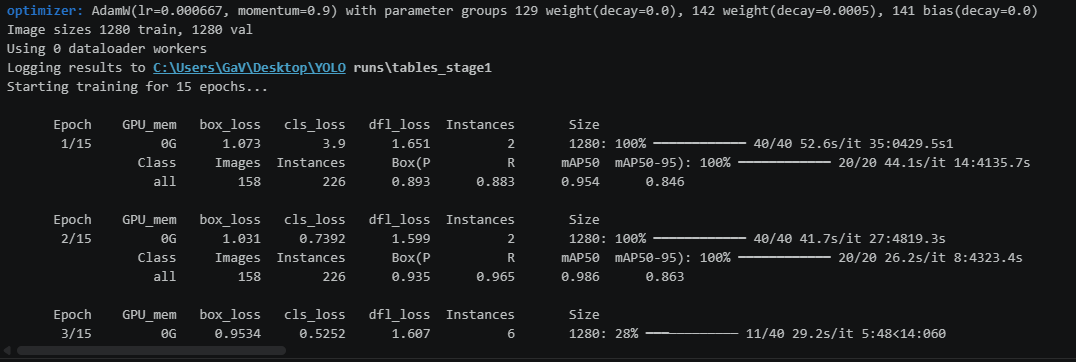

In [ ]:
from pathlib import Path
import yaml
DATA_YAML = r"C:\Users\GaV\Desktop\YOLO dataset\data.yaml"

OLD_CLASS_ID = "0"
NEW_CLASS_ID = "8"


def resolve_path(base_path: Path | None, value: str) -> Path:
    p = Path(value)
    if p.is_absolute():
        return p
    if base_path is not None:
        return base_path / p
    return p


def images_to_labels_path(images_path: Path) -> Path:
    parts = list(images_path.parts)
    try:
        idx = parts.index("images")
        parts[idx] = "labels"
        return Path(*parts)
    except ValueError:
        raise ValueError(f"В пути нет сегмента 'images': {images_path}")


with open(DATA_YAML, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

base_path = Path(cfg["path"]) if "path" in cfg and cfg["path"] else None

image_dirs = []
for split_name in ("train", "val", "test"):
    if split_name in cfg and cfg[split_name]:
        image_dirs.append(resolve_path(base_path, cfg[split_name]))

label_dirs = [images_to_labels_path(p) for p in image_dirs]

changed_files = 0
changed_lines = 0

for labels_dir in label_dirs:
    if not labels_dir.exists():
        print(f"[WARN] Папка не найдена: {labels_dir}")
        continue

    for txt_path in labels_dir.rglob("*.txt"):
        lines_out = []
        file_changed = False

        with open(txt_path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue

                parts = line.split()
                if parts[0] == OLD_CLASS_ID:
                    parts[0] = NEW_CLASS_ID
                    file_changed = True
                    changed_lines += 1

                lines_out.append(" ".join(parts))

        if file_changed:
            with open(txt_path, "w", encoding="utf-8") as f:
                f.write("\n".join(lines_out) + ("\n" if lines_out else ""))
            changed_files += 1

print(f"Готово: изменено файлов = {changed_files}, изменено строк = {changed_lines}")
print("Проверенные папки labels:")
for p in label_dirs:
    print(" -", p)

Готово: изменено файлов = 0, изменено строк = 0
Проверенные папки labels:
 - C:\Users\GaV\Desktop\YOLO dataset\labels
 - C:\Users\GaV\Desktop\YOLO dataset\labels


In [ ]:
from PIL import Image
import json

# =========================
# Настройки
# =========================
data_yaml_path = Path(DATA_YAML)
OUTPUT_DIR = data_yaml_path.parent / "annotations_coco_with_negatives"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


# =========================
# Вспомогательные функции
# =========================
def normalize_names_dict(names_obj):
    if isinstance(names_obj, dict):
        return {int(k): str(v) for k, v in names_obj.items()}
    elif isinstance(names_obj, list):
        return {i: str(v) for i, v in enumerate(names_obj)}
    else:
        raise ValueError(f"Неожиданный формат names: {type(names_obj)}")


def find_table_yolo_id(names_dict):
    for yolo_id, class_name in names_dict.items():
        if str(class_name).strip().lower() == "table":
            return yolo_id
    raise ValueError("Класс 'table' не найден в names из data.yaml")


def find_label_for_image(img_path: Path, labels_dir: Path) -> Path:
    return labels_dir / f"{img_path.stem}.txt"


def yolo_line_to_coco_bbox(line: str, img_w: int, img_h: int):
    parts = line.strip().split()
    if len(parts) < 5:
        return None

    cls_id = int(float(parts[0]))
    xc = float(parts[1])
    yc = float(parts[2])
    bw = float(parts[3])
    bh = float(parts[4])

    x = (xc - bw / 2.0) * img_w
    y = (yc - bh / 2.0) * img_h
    w = bw * img_w
    h = bh * img_h

    x = max(0.0, x)
    y = max(0.0, y)
    w = max(0.0, min(w, img_w - x))
    h = max(0.0, min(h, img_h - y))

    return cls_id, [x, y, w, h]


def list_images(images_dir: Path):
    files = []
    for ext in IMAGE_EXTS:
        files.extend(images_dir.rglob(f"*{ext}"))
        files.extend(images_dir.rglob(f"*{ext.upper()}"))
    return sorted(set(files))


def convert_split_to_coco_table_only_with_negatives(
    split_name,
    images_dir: Path,
    labels_dir: Path,
    table_yolo_id: int
):
    images = []
    annotations = []
    categories = [
        {
            "id": 1,
            "name": "table",
            "supercategory": "table"
        }
    ]

    image_id = 1
    ann_id = 1

    image_files = list_images(images_dir)
    print(f"[{split_name}] images found: {len(image_files)}")

    positive_images = 0
    negative_images = 0
    missing_label_files = 0

    for img_path in image_files:
        with Image.open(img_path) as img:
            img_w, img_h = img.size

        current_image_id = image_id
        images.append({
            "id": current_image_id,
            "file_name": img_path.name,
            "width": img_w,
            "height": img_h
        })
        image_id += 1

        label_path = find_label_for_image(img_path, labels_dir)
        has_table = False

        if label_path.exists():
            with open(label_path, "r", encoding="utf-8") as f:
                for line in f:
                    if not line.strip():
                        continue

                    parsed = yolo_line_to_coco_bbox(line, img_w, img_h)
                    if parsed is None:
                        continue

                    yolo_cls_id, coco_bbox = parsed
                    if yolo_cls_id != table_yolo_id:
                        continue

                    x, y, w, h = coco_bbox
                    annotations.append({
                        "id": ann_id,
                        "image_id": current_image_id,
                        "category_id": 1,
                        "bbox": [round(x, 2), round(y, 2), round(w, 2), round(h, 2)],
                        "area": round(w * h, 2),
                        "iscrowd": 0
                    })
                    ann_id += 1
                    has_table = True
        else:
            missing_label_files += 1

        if has_table:
            positive_images += 1
        else:
            negative_images += 1

    print(f"[{split_name}] positive images with table: {positive_images}")
    print(f"[{split_name}] negative images without table: {negative_images}")
    print(f"[{split_name}] missing label files: {missing_label_files}")

    coco = {
        "images": images,
        "annotations": annotations,
        "categories": categories
    }
    return coco


# =========================
# Чтение data.yaml
# =========================
with open(DATA_YAML, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

base_path = Path(cfg["path"]) if "path" in cfg and cfg["path"] else None
names_dict = normalize_names_dict(cfg["names"])
table_yolo_id = find_table_yolo_id(names_dict)

print("Классы из data.yaml:")
for k, v in sorted(names_dict.items()):
    print(f"  {k}: {v}")

print(f"\nИндекс класса 'table' в YOLO: {table_yolo_id}")

splits = {}
for split_name in ("train", "val"):
    if split_name in cfg and cfg[split_name]:
        images_dir = resolve_path(base_path, cfg[split_name])
        labels_dir = images_to_labels_path(images_dir)
        splits[split_name] = (images_dir, labels_dir)

print("\nНайденные split-пути:")
for split_name, (images_dir, labels_dir) in splits.items():
    print(f"  {split_name}:")
    print(f"    images = {images_dir}")
    print(f"    labels = {labels_dir}")


# =========================
# Конвертация
# =========================
for split_name, (images_dir, labels_dir) in splits.items():
    coco = convert_split_to_coco_table_only_with_negatives(
        split_name=split_name,
        images_dir=images_dir,
        labels_dir=labels_dir,
        table_yolo_id=table_yolo_id,
    )

    out_json = OUTPUT_DIR / f"instance_{split_name}.json"
    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(coco, f, ensure_ascii=False, indent=2)

    print(f"\n[{split_name}] saved: {out_json}")
    print(f"  images: {len(coco['images'])}")
    print(f"  annotations: {len(coco['annotations'])}")
    print(f"  categories: {len(coco['categories'])}")

Классы из data.yaml:
  0: Caption
  1: Footnote
  2: Formula
  3: List-item
  4: Page-footer
  5: Page-header
  6: Picture
  7: Section-header
  8: Table
  9: Text
  10: Title

Индекс класса 'table' в YOLO: 8

Найденные split-пути:
  train:
    images = C:\Users\GaV\Desktop\YOLO dataset\images
    labels = C:\Users\GaV\Desktop\YOLO dataset\labels
  val:
    images = C:\Users\GaV\Desktop\YOLO dataset\images
    labels = C:\Users\GaV\Desktop\YOLO dataset\labels
[train] images found: 158
[train] positive images with table: 158
[train] negative images without table: 0
[train] missing label files: 0

[train] saved: C:\Users\GaV\Desktop\YOLO dataset\annotations_coco_with_negatives\instance_train.json
  images: 158
  annotations: 226
  categories: 1
[val] images found: 158
[val] positive images with table: 158
[val] negative images without table: 0
[val] missing label files: 0

[val] saved: C:\Users\GaV\Desktop\YOLO dataset\annotations_coco_with_negatives\instance_val.json
  images: 158
  ann

In [11]:
from pathlib import Path
from PIL import Image
import xml.etree.ElementTree as ET

# ====== НАСТРОЙКИ ======
images_dir = Path(r"C:\Users\GaV\Desktop\YOLO dataset\images")
labels_dir = Path(r"C:\Users\GaV\Desktop\YOLO dataset\labels")
output_dir = Path(r"C:\Users\GaV\Desktop\YOLO dataset\train")

# Можно руками:
class_names = ["table"]

# Или загрузить из classes.txt:
# class_names = Path(r"C:\Users\GaV\Desktop\dataset\classes.txt").read_text(encoding="utf-8").strip().splitlines()

output_dir.mkdir(parents=True, exist_ok=True)

img_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


def yolo_to_voc_bbox(xc, yc, w, h, img_w, img_h):
    x_center = xc * img_w
    y_center = yc * img_h
    box_w = w * img_w
    box_h = h * img_h

    xmin = int(round(x_center - box_w / 2))
    ymin = int(round(y_center - box_h / 2))
    xmax = int(round(x_center + box_w / 2))
    ymax = int(round(y_center + box_h / 2))

    xmin = max(0, min(xmin, img_w - 1))
    ymin = max(0, min(ymin, img_h - 1))
    xmax = max(0, min(xmax, img_w - 1))
    ymax = max(0, min(ymax, img_h - 1))

    return xmin, ymin, xmax, ymax


def create_voc_xml(image_path, label_path, save_path, class_names):
    with Image.open(image_path) as img:
        img_w, img_h = img.size
        depth = len(img.getbands())

    annotation = ET.Element("annotation")

    ET.SubElement(annotation, "folder").text = image_path.parent.name
    ET.SubElement(annotation, "filename").text = image_path.name
    ET.SubElement(annotation, "path").text = image_path.name

    size = ET.SubElement(annotation, "size")
    ET.SubElement(size, "width").text = str(img_w)
    ET.SubElement(size, "height").text = str(img_h)
    ET.SubElement(size, "depth").text = str(depth)

    if label_path.exists():
        text = label_path.read_text(encoding="utf-8").strip()
        if text:
            lines = text.splitlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) != 5:
                    print(f"Пропуск некорректной строки: {label_path} -> {line}")
                    continue

                class_id, xc, yc, w, h = parts
                class_id = int(class_id)
                xc, yc, w, h = map(float, [xc, yc, w, h])

                if class_id >= len(class_names):
                    print(f"Неизвестный class_id={class_id} в {label_path}")
                    #continue

                xmin, ymin, xmax, ymax = yolo_to_voc_bbox(xc, yc, w, h, img_w, img_h)

                obj = ET.SubElement(annotation, "object")
                ET.SubElement(obj, "name").text = class_names[0]
                ET.SubElement(obj, "pose").text = "Frontal"
                ET.SubElement(obj, "truncated").text = "0"
                ET.SubElement(obj, "difficult").text = "0"

                bndbox = ET.SubElement(obj, "bndbox")
                ET.SubElement(bndbox, "xmin").text = str(xmin)
                ET.SubElement(bndbox, "ymin").text = str(ymin)
                ET.SubElement(bndbox, "xmax").text = str(xmax)
                ET.SubElement(bndbox, "ymax").text = str(ymax)

    tree = ET.ElementTree(annotation)
    ET.indent(tree, space="    ", level=0)
    tree.write(save_path, encoding="utf-8", xml_declaration=False)


for image_path in images_dir.iterdir():
    if image_path.suffix.lower() not in img_exts:
        continue

    label_path = labels_dir / f"{image_path.stem}.txt"
    save_path = output_dir / f"{image_path.stem}.xml"

    create_voc_xml(image_path, label_path, save_path, class_names)

print(f"Готово. XML сохранены в: {output_dir}")

Неизвестный class_id=8 в C:\Users\GaV\Desktop\YOLO dataset\labels\38723_1785012_p003.txt
Неизвестный class_id=8 в C:\Users\GaV\Desktop\YOLO dataset\labels\38723_1785012_p007.txt
Неизвестный class_id=8 в C:\Users\GaV\Desktop\YOLO dataset\labels\38723_1785012_p008.txt
Неизвестный class_id=8 в C:\Users\GaV\Desktop\YOLO dataset\labels\38723_1785012_p009.txt
Неизвестный class_id=8 в C:\Users\GaV\Desktop\YOLO dataset\labels\38723_1785012_p010.txt
Неизвестный class_id=8 в C:\Users\GaV\Desktop\YOLO dataset\labels\38723_1785012_p011.txt
Неизвестный class_id=8 в C:\Users\GaV\Desktop\YOLO dataset\labels\38723_1785012_p012.txt
Неизвестный class_id=8 в C:\Users\GaV\Desktop\YOLO dataset\labels\38723_1785012_p013.txt
Неизвестный class_id=8 в C:\Users\GaV\Desktop\YOLO dataset\labels\38723_1785012_p014.txt
Неизвестный class_id=8 в C:\Users\GaV\Desktop\YOLO dataset\labels\38723_1785012_p015.txt
Неизвестный class_id=8 в C:\Users\GaV\Desktop\YOLO dataset\labels\38723_1785012_p016.txt
Неизвестный class_id=

In [ ]:
import paddlex  # или любая другая библиотека

print(paddlex.__file__)

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


c:\Users\GaV\AppData\Local\Programs\Python\Python312\Lib\site-packages\paddlex\__init__.py


In [ ]:
import paddlex
print(paddlex.__version__)

3.5.2


In [ ]:
from paddlex.repo_manager import repo_manager
repo_manager.initialize()
from paddlex.repo_apis.base.register import get_registered_model_info
info = get_registered_model_info("PP-LCNet_x1_0_textline_ori")
print(info)

ImportError: cannot import name 'repo_manager' from 'paddlex.repo_manager' (C:\Users\GaV\PaddleX\paddlex\repo_manager\__init__.py)

In [ ]:
pip install PaddleClas

     ---------------------------------------- 0.0/10.9 MB ? eta -:--:--
      --------------------------------------- 0.3/10.9 MB ? eta -:--:--
     -- ------------------------------------- 0.8/10.9 MB 4.2 MB/s eta 0:00:03
     --- ------------------------------------ 1.0/10.9 MB 1.9 MB/s eta 0:00:06
     -------- ------------------------------- 2.4/10.9 MB 3.2 MB/s eta 0:00:03
     ------------- -------------------------- 3.7/10.9 MB 3.8 MB/s eta 0:00:02
     ---------------- ----------------------- 4.5/10.9 MB 3.8 MB/s eta 0:00:02
     -------------------- ------------------- 5.5/10.9 MB 4.0 MB/s eta 0:00:02
     ------------------------ --------------- 6.6/10.9 MB 4.2 MB/s eta 0:00:02
     ------------------------ --------------- 6.8/10.9 MB 4.2 MB/s eta 0:00:01
     ----------------------------- ---------- 8.1/10.9 MB 4.0 MB/s eta 0:00:01
     ---------------------------------- ----- 9.4/10.9 MB 4.3 MB/s eta 0:00:01
     ------------------------------------ --- 10.0/10.9 MB 4.1 MB/

  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [33 lines of output]
      Traceback (most recent call last):
        File "c:\Users\GaV\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
        File "c:\Users\GaV\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "c:\Users\GaV\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 137, in get_requires_for_build_wheel
          backend = _build_backend()
                    ^^^^^^^^^^^^^^^^
        File "c:\Users\GaV\AppData\Local\Programs\Python\Python312\Lib\site-packa

In [97]:
pip uninstall -y paddlex

Note: you may need to restart the kernel to use updated packages.


In [87]:
pip install paddlepaddle==3.0.0 -i https://www.paddlepaddle.org.cn/packages/stable/cpu/

Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cpu/
     ---------------------------------------- 0.0/97.1 MB ? eta -:--:--
     ---------------------------------------- 0.0/97.1 MB ? eta -:--:--
     ---------------------------------------- 0.0/97.1 MB ? eta -:--:--
     ---------------------------------------- 0.0/97.1 MB ? eta -:--:--
     ---------------------------------------- 0.0/97.1 MB ? eta -:--:--
     ---------------------------------------- 0.0/97.1 MB ? eta -:--:--
     ---------------------------------------- 0.0/97.1 MB ? eta -:--:--
     ---------------------------------------- 0.0/97.1 MB ? eta -:--:--
     ---------------------------------------- 0.0/97.1 MB ? eta -:--:--
     ---------------------------------------- 0.0/97.1 MB ? eta -:--:--
     ---------------------------------------- 0.0/97.1 MB ? eta -:--:--
     ---------------------------------------- 0.0/97.1 MB ? eta -:--:--
     ---------------------------------------- 0.0/97.1 MB ? eta


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import paddle
print(paddle.__version__)   #

c:\Users\GaV\AppData\Local\Programs\Python\Python312\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


3.0.0


In [2]:
import sys
print(sys.executable)

c:\Users\GaV\AppData\Local\Programs\Python\Python312\python.exe


In [6]:
pip install "paddlex==3.0"


  Using cached paddlex-3.0.0-py3-none-any.whl.metadata (73 kB)
  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached pandas-1.5.3.tar.gz (5.2 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [20 lines of output]
      Traceback (most recent call last):
        File "c:\Users\GaV\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
        File "c:\Users\GaV\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "c:\Users\GaV\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 143, in get_requires_for_build_wheel
          return hook(config_settings)
                 ^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\GaV\AppData\Local\Temp\pip-build-env-wytaz4y0\overlay\

In [1]:
pip install "numpy==1.26.4" "pandas==1.5.3"

  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached pandas-1.5.3.tar.gz (5.2 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [20 lines of output]
      Traceback (most recent call last):
        File "c:\Users\GaV\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
        File "c:\Users\GaV\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "c:\Users\GaV\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 143, in get_requires_for_build_wheel
          return hook(config_settings)
                 ^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\GaV\AppData\Local\Temp\pip-build-env-eyll0h2c\overlay\

In [9]:
pip install "setuptools<82"

  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
Using cached setuptools-81.0.0-py3-none-any.whl (1.1 MB)
  Attempting uninstall: setuptools
    Found existing installation: setuptools 82.0.1
    Uninstalling setuptools-82.0.1:
      Successfully uninstalled setuptools-82.0.1
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
label-studio 1.22.0 requires wheel<=0.40.0,>=0.38.1, but you have wheel 0.47.0 which is incompatible.
seleniumbase 4.33.14 requires h11==0.14.0, but you have h11 0.16.0 which is incompatible.
seleniumbase 4.33.14 requires selenium==4.27.1, but you have selenium 4.33.0 which is incompatible.
seleniumbase 4.33.14 requires trio==0.28.0; python_version >= "3.9", but you have trio 0.30.0 which is incompatible.
seleniumbase 4.33.14 requires trio-websocket==0.11.1, but you have trio-websocket 0.12.2 which is incompatible.
seleniumbase 4.33.14 requires urllib3<2.4.0,>=1.26.20; python_version >= "3.10", but you have urllib3 2.6.3 which is incompatible.
tensorflow-intel 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, but you have ml-dtypes 0.5.3 which is incompatible.
tensorflow-intel 2.18.0 requires numpy<2.1.0,>=1.26.0, but you 

In [2]:
py -3.12 --version
py -3.11 --version

NameError: name 'py' is not defined

In [1]:
import paddlex
print(paddlex.__version__)  # должно быть 3.0.0 или 3.0.x

ModuleNotFoundError: No module named 'paddlex'